In [1]:
import polars as pl
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import os
from collections import defaultdict
import datetime as dt
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
sys.path.insert(1, os.path.abspath(".."))
os.chdir(os.path.abspath('..')) # Change the workdir to the parent folder

# ── Visual defaults ───────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
SIRS_COLORS = {0: "#4CAF50", 1: "#FFC107", 2: "#FF9800", 3: "#F44336", 4: "#9C27B0"}

### Load raw data

In [2]:
from src.configs.dataconfig import input_filenames_v3, input_output_config_3, input_filenames_v2, input_output_config_2
from src.dataloader import DataLoader

In [3]:
# dl2 = DataLoader(input_output_config_2)
dl3 = DataLoader(input_output_config_3)

In [4]:
df_all_3 = dl3.load_data()

In [5]:
# df_enc_2 = dl2._load_encounters()
# df_enc_2 = dl2.cast_cols(df_enc_2)


df_enc_3 = dl3._load_encounters()
df_meds_3 = dl3._load_meds()
df_enc_3 = dl3.cast_cols(df_enc_3)
# df_meds_3 = dl2.cast_cols(df_meds_3)

In [6]:
df_meds_3['Type'].unique().to_list()

['Perioperative Antibiotics',
 'IV Antibiotics - Single',
 'IV Antibiotics - First',
 'IV Antibiotics',
 'Medication Administration',
 'IV Antibiotics - Last']

In [7]:
df_enc_meds_count = df_meds_3.group_by("EncounterEpicCsn").agg(pl.len().alias('count'))

In [8]:
df_enc_3 = (
    df_enc_3
    .with_columns(
        # 1. Source LOS, numeric. Unparseable → null (we measured those in Stage 0).
        pl.col("LengthOfStayInDays")
          .cast(pl.Float64, strict=False)
          .alias("los_source"),

        # 2. Independently derived LOS from the timestamps, in fractional days.
        ((pl.col("DischargeDateValue") - pl.col("AdmissionDateValue"))
            .dt.total_seconds() / 86_400.0)
          .alias("los_derived"),
    )
)

In [9]:
df_enc_3.columns

['PrimaryMrn',
 'PatientAgeAtAdmission',
 'Sex',
 'Ethnicity',
 'FirstRace',
 'MultiRacial',
 'EncounterEpicCsn',
 'AdmissionDateValue',
 'DischargeDateValue',
 'Arrival_Instant',
 'FirstAdmissionOrderInstant',
 'InpatientAdmissionInstant',
 'Admitted_from_ED',
 'PatientClass',
 'InpatientAdmissionPatientClass',
 'HospitalService',
 'LengthOfStayInDays',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 'PrimaryCodedDiagnosis',
 'PrimaryCodedProcedureKey',
 'Death_Flag',
 'Original_POA_Condition',
 'Sepsis_Category',
 'Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'First_Suspected_Infection_Time',
 'Suspected_Infection_Criteria_Met',
 'Cancer_Registry_YN',
 'HIV_Registry_YN',
 'Immunocrompromised_Registry_YN',
 'CKD_Dialysis_Registry_YN',
 'Solid_Organ_Transplant_Registry_YN',
 'Pregn

In [10]:
n_before = df_enc_3.height
df_enc_3_noupoa = df_enc_3.filter(~pl.col("Sepsis_Category").str.starts_with("UPOA-"))
n_excluded = n_before - df_enc_3_noupoa.height
n_excluded

308

### Load Sepsis data

In [11]:
PROJECT_V3 = 'phase3_v3'
# v3 
df_sepsis_3_v3 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V3,'df_sepsis3.parquet'
	)
)

df_sepsis_2_v3 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V3,'df_sepsis2.parquet'
	)
)

df_sepsis_1_v3 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V3,'df_sepsis1.parquet'
	)
)

df_sirs_3 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V3,'df_sirs_postagg.parquet'
	)
)

df_organdysf_3 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V3,'df_organdysfunction.parquet'
	)
)

df_o2vent_3 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V3,'df_o2vent.parquet'
	)
)

df_shock_3 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path), PROJECT_V3, 'df_septicshock.parquet'
	)
)

df_infect_long_3 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V3,'df_infect_long.parquet'
	)
)

In [12]:
PROJECT_V2 = 'raw_data_phase3_v2_old'
# v2 
df_sepsis_3_v2 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V2,'df_sepsis3.parquet'
    )
)
df_sepsis_2_v2 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V2,'df_sepsis2.parquet'
    )
)
df_sepsis_1_v2 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V2,'df_sepsis1.parquet'
    )
)


df_sirs_2 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path), PROJECT_V2,'df_sirs.parquet'
	)
)

df_organdysf_2 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path), PROJECT_V2,'df_organdysfunction.parquet'
	)
)

df_o2vent_2 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V2,'df_agg_vent.parquet'
	)
)

df_shock_2 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path), PROJECT_V2, 'df_septicshock.parquet'
	)
)

df_infect_long_2 = pl.read_parquet(
    os.path.join(
        os.path.dirname(input_output_config_3.output_path),PROJECT_V2,'df_infect_long.parquet'
	)
)


In [13]:
cols1 = df_sepsis_1_v3.columns
cols2 = df_sepsis_1_v3.columns
cols3 = df_sepsis_1_v3.columns
idx = cols2.index('earliest_sepsis1_instance')
cols2[idx] = 'earliest_sepsis2_instance'
cols3[idx] = 'earliest_sepsis3_instance'
cols2.remove('sirs_score')
cols3.remove('sirs_score')
cols1.remove('sirs_score')

df_sepsis_1_v3 = df_sepsis_1_v3.select(
    cols1
).with_columns(
    pl.lit(1).alias('sepsis_score')
).rename({"earliest_sepsis1_instance": "sepsis_instance"})

df_sepsis_2_v3 = df_sepsis_2_v3.select(
    cols2
).with_columns(
    pl.lit(2).alias('sepsis_score')
).rename({"earliest_sepsis2_instance": "sepsis_instance"})

df_sepsis_3_v3 = df_sepsis_3_v3.select(
    cols3
).with_columns(
    pl.lit(3).alias('sepsis_score')
).rename({"earliest_sepsis3_instance": "sepsis_instance"})

df_sepsis_v3 = pl.concat([df_sepsis_1_v3, df_sepsis_2_v3, df_sepsis_3_v3], how='vertical')

df_sepsis_1_v2 = df_sepsis_1_v2.select(
    cols1
).with_columns(
    pl.lit(1).alias('sepsis_score')
).rename({"earliest_sepsis1_instance": "sepsis_instance"})

df_sepsis_2_v2 = df_sepsis_2_v2.select(
    cols2
).with_columns(
    pl.lit(2).alias('sepsis_score')
).rename({"earliest_sepsis2_instance": "sepsis_instance"})

df_sepsis_3_v2 = df_sepsis_3_v2.select(
    cols3
).with_columns(
    pl.lit(3).alias('sepsis_score')
).rename({"earliest_sepsis3_instance": "sepsis_instance"})

df_sepsis_v2 = pl.concat([df_sepsis_1_v2, df_sepsis_2_v2, df_sepsis_3_v2], how='vertical')

In [14]:
df_sepsis_v3.shape, df_sepsis_v2.shape, df_sepsis_v3['EncounterEpicCsn'].n_unique(), df_sepsis_v2['EncounterEpicCsn'].n_unique()

((47652364, 5), (27281, 5), 13878, 14577)

### Temp to analysis specific encounters

#### Third encounter in first group

In [29]:
df_organdysf_2.filter(
	(pl.col("EncounterEpicCsn") ==699944936)&
	(pl.col("organ_dysfunction_total") > 0)
)

EncounterEpicCsn,Event_DateTime,last_temp_8h,last_pulse_8h,last_resp_8h,last_sbp_8h,last_map_8h,last_wbc_12h,last_creatinine_12h,last_egfr_12h,last_bilirubin_12h,last_lactate_6h,last_platelets_24h,last_inr_12h,last_aptt_24h,last_gcs_12h,last_vasopressin_24h,last_phenylephrine_24h,last_norepinephrine_24h,last_epinephrine_24h,vent_status_time,vent_status_flag,Baseline_Creatinine,Baseline_eGFR,Baseline_Bilirubin,Baseline_Platelets,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_WBC,cardiovascular_failure_flag,coagulation_failure_flag,aptt_criteria_flag,platelets100_criteria_flag,platelets50_criteria_flag,inr_criteria_flag,pulmonary_failure_flag,renal_failure_flag,hepatic_failure_flag,neurological_failure_flag,organ_dysfunction_total
i64,datetime[μs],f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs],str,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i64,i32,i32,i64,i64
699944936,2024-03-13 08:12:00,99.3,91.0,18.0,124,null,3.8,0.6,110.0,3.6,null,55.0,null,null,null,null,null,null,null,null,"""Vent off Documentation""",0.725,97.977273,1.546154,221.265306,136.0,17.0,83.0,6.706591,0,1,0,0,1,0,0,0,1,0,2
699944936,2024-03-13 08:12:00,99.3,91.0,18.0,124,null,3.8,0.6,110.0,3.6,null,55.0,null,null,null,null,null,null,null,null,null,0.725,97.977273,1.546154,221.265306,136.0,17.0,83.0,6.706591,0,1,0,0,1,0,0,0,1,0,2
699944936,2024-03-13 09:04:00,97.4,97.0,18.0,109,null,3.8,0.6,110.0,3.6,null,55.0,null,null,null,null,null,null,null,null,null,0.725,97.977273,1.546154,221.265306,136.0,17.0,83.0,6.706591,0,1,0,0,1,0,0,0,1,0,2
699944936,2024-03-13 09:04:00,97.4,97.0,18.0,109,null,3.8,0.6,110.0,3.6,null,55.0,null,null,null,null,null,null,null,null,"""Vent off Documentation""",0.725,97.977273,1.546154,221.265306,136.0,17.0,83.0,6.706591,0,1,0,0,1,0,0,0,1,0,2
699944936,2024-03-13 09:42:00,97.4,97.0,18.0,109,null,3.8,0.6,110.0,3.6,null,55.0,null,null,15.0,null,null,null,null,null,null,0.725,97.977273,1.546154,221.265306,136.0,17.0,83.0,6.706591,0,1,0,0,1,0,0,0,1,0,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
699944936,2024-03-21 02:13:25,98.2,98.0,16.0,74,null,null,null,null,null,null,64.0,null,null,null,null,null,null,null,null,"""Vent off Documentation""",0.725,97.977273,1.546154,221.265306,136.0,17.0,83.0,6.706591,0,1,0,0,1,0,0,0,0,0,1
699944936,2024-03-21 03:02:59.650,98.2,98.0,16.0,74,null,null,null,null,null,null,64.0,null,null,null,null,null,null,null,null,null,0.725,97.977273,1.546154,221.265306,136.0,17.0,83.0,6.706591,0,1,0,0,1,0,0,0,0,0,1
699944936,2024-03-21 03:02:59.650,98.2,98.0,16.0,74,null,null,null,null,null,null,64.0,null,null,null,null,null,null,null,null,"""Vent off Documentation""",0.725,97.977273,1.546154,221.265306,136.0,17.0,83.0,6.706591,0,1,0,0,1,0,0,0,0,0,1


In [26]:
df_all_3.filter(
	(pl.col("EncounterEpicCsn") ==699944936)&
	(pl.col("Event_DateTime") <= dt.datetime(2024,3,20, 5, 28)+dt.timedelta(hours=1))&
	(pl.col("Event_DateTime") >= dt.datetime(2024,3,20, 5, 28)-dt.timedelta(hours=1))
)

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN
i64,datetime[μs],str,str,str,f64,str,str,i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str
699944936,2024-03-20 05:28:14,"""IV Antibiotics - Single""","""Antibiotics""","""PIPERACILLIN-TAZOBACTAM 3.375G…",3.375,"""g""",null,90902632,49.670088,"""Female""","""Non-Hispanic/Latino""","""White""","""0""",699944936,2024-03-12 00:00:00,2024-03-21 00:00:00,2024-03-12 09:43:00,2024-03-12 10:27:00,2024-03-13 10:58:00,"""Yes""","""Inpatient""","""Observation""","""IM - Teaching""",9,"""UH 12G""","""UH 12G""","""Emergency""","""Physician Ofc/OP Clinic""","""ED Admission""","""Cancer related pain""","""Neoplasm related pain (acute) …","""*Unspecified""",0,"""NPOA-3""","""NPOA-3""",136.0,17.0,83.0,0.725,221.265306,1.546154,97.977273,6.706591,null,null,"""1""","""0""","""0""","""0""","""0""","""0"""
699944936,2024-03-20 05:21:00,"""Lab Results""","""Creatinine""","""CREATININE""",1.61,"""1.61""","""1""",90902632,49.670088,"""Female""","""Non-Hispanic/Latino""","""White""","""0""",699944936,2024-03-12 00:00:00,2024-03-21 00:00:00,2024-03-12 09:43:00,2024-03-12 10:27:00,2024-03-13 10:58:00,"""Yes""","""Inpatient""","""Observation""","""IM - Teaching""",9,"""UH 12G""","""UH 12G""","""Emergency""","""Physician Ofc/OP Clinic""","""ED Admission""","""Cancer related pain""","""Neoplasm related pain (acute) …","""*Unspecified""",0,"""NPOA-3""","""NPOA-3""",136.0,17.0,83.0,0.725,221.265306,1.546154,97.977273,6.706591,null,null,"""1""","""0""","""0""","""0""","""0""","""0"""
699944936,2024-03-20 05:21:00,"""Lab Results""","""Platelets""","""PLATELETS""",64.0,"""64""","""1""",90902632,49.670088,"""Female""","""Non-Hispanic/Latino""","""White""","""0""",699944936,2024-03-12 00:00:00,2024-03-21 00:00:00,2024-03-12 09:43:00,2024-03-12 10:27:00,2024-03-13 10:58:00,"""Yes""","""Inpatient""","""Observation""","""IM - Teaching""",9,"""UH 12G""","""UH 12G""","""Emergency""","""Physician Ofc/OP Clinic""","""ED Admission""","""Cancer related pain""","""Neoplasm related pain (acute) …","""*Unspecified""",0,"""NPOA-3""","""NPOA-3""",136.0,17.0,83.0,0.725,221.265306,1.546154,97.977273,6.706591,null,null,"""1""","""0""","""0""","""0""","""0""","""0"""
699944936,2024-03-20 05:21:00,"""Lab Results""","""WBC""","""WBC""",35.81,"""35.81""","""1""",90902632,49.670088,"""Female""","""Non-Hispanic/Latino""","""White""","""0""",699944936,2024-03-12 00:00:00,2024-03-21 00:00:00,2024-03-12 09:43:00,2024-03-12 10:27:00,2024-03-13 10:58:00,"""Yes""","""Inpatient""","""Observation""","""IM - Teaching""",9,"""UH 12G""","""UH 12G""","""Emergency""","""Physician Ofc/OP Clinic""","""ED Admission""","""Cancer related pain""","""Neoplasm related pain (acute) …","""*Unspecified""",0,"""NPOA-3""","""NPOA-3""",136.0,17.0,83.0,0.725,221.265306,1.546154,97.977273,6.706591,null,null,"""1""","""0""","""0""","""0""","""0""","""0"""
699944936,2024-03-20 05:21:00,"""Lab Results""","""eGFR""","""EGFR CKD EPI C

In [23]:
df_all_3.filter(
	pl.col("EncounterEpicCsn") ==699944936
).sort(by='Event_DateTime').filter(pl.col("Type")=='IV Antibiotics')

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN
i64,datetime[μs],str,str,str,f64,str,str,i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str


In [20]:
df_sepsis_v3.filter(
	pl.col("EncounterEpicCsn") == 699944936
)

EncounterEpicCsn,infect_dt,Event_DateTime,sepsis_instance,sepsis_score
i64,datetime[μs],datetime[μs],datetime[μs],i32


In [16]:
print(df_sepsis_3_v2.filter(
    pl.col("EncounterEpicCsn") == 699944936
))
print(df_sepsis_1_v2.filter(
    pl.col("EncounterEpicCsn") == 699944936
))
print(df_sepsis_2_v2.filter(
    pl.col("EncounterEpicCsn") == 699944936
))

shape: (0, 5)
┌──────────────────┬──────────────┬────────────────┬─────────────────┬──────────────┐
│ EncounterEpicCsn ┆ infect_dt    ┆ Event_DateTime ┆ sepsis_instance ┆ sepsis_score │
│ ---              ┆ ---          ┆ ---            ┆ ---             ┆ ---          │
│ i64              ┆ datetime[μs] ┆ datetime[μs]   ┆ datetime[μs]    ┆ i32          │
╞══════════════════╪══════════════╪════════════════╪═════════════════╪══════════════╡
└──────────────────┴──────────────┴────────────────┴─────────────────┴──────────────┘
shape: (0, 5)
┌──────────────────┬──────────────┬────────────────┬─────────────────┬──────────────┐
│ EncounterEpicCsn ┆ infect_dt    ┆ Event_DateTime ┆ sepsis_instance ┆ sepsis_score │
│ ---              ┆ ---          ┆ ---            ┆ ---             ┆ ---          │
│ i64              ┆ datetime[μs] ┆ datetime[μs]   ┆ datetime[μs]    ┆ i32          │
╞══════════════════╪══════════════╪════════════════╪═════════════════╪══════════════╡
└──────────────────┴──────

In [15]:
df_sepsis_v2.filter(
    pl.col("EncounterEpicCsn") == 699944936
)

EncounterEpicCsn,infect_dt,Event_DateTime,sepsis_instance,sepsis_score
i64,datetime[μs],datetime[μs],datetime[μs],i32


#### First encounter in group 1

In [26]:
sorted(df_all_3.filter(
    (pl.col("EncounterEpicCsn")==667468525)
)['Event_Name'].unique().to_list())

['ACETAMINOPHEN 325 MG TAB',
 'ACETAMINOPHEN 500 MG TAB',
 'AZITHROMYCIN 250 MG TAB',
 'Abnormal findings on diagnostic imaging of other specified body structures',
 'Acute and chronic respiratory failure with hypoxia (*)',
 'Acute and chronic respiratory failure, unspecified whether with hypoxia or hypercapnia',
 'Acute on chronic respiratory failure, unspecified whether with hypoxia or hypercapnia',
 'Acute upper respiratory infection, unspecified',
 'Age-related osteoporosis without current pathological fracture',
 'Anxiety disorder, unspecified',
 'BACTERIA UA',
 'BILIRUBIN, TOTAL',
 'BLOOD PRESSURE',
 'BUN',
 'COPD with acute exacerbation (*)',
 'CPM S25 R AS SC BRADEN SCORE',
 'CPM S25 R AS SC SUM SCORE',
 'CPM S25 R INV DEVICE.INV O2 DEVICE',
 'CPM S25 R INV O2 FLOW RATE (L/MIN)',
 'CREATININE',
 'CULTURE',
 'CULTURE BLOOD',
 'Chronic obstructive pulmonary disease with (acute) exacerbation (*)',
 'Contact with and (suspected) exposure to covid-19',
 'Cough, unspecified',
 'Depre

In [24]:
df_o2vent_3.filter(pl.col("EncounterEpicCsn") == 667468525).filter(pl.col("pulmonary_dysfunction_flag")==0)

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,pf_ratio,PF_Ratio_Flag,vent_onoff_flag,vent_doc_flag,o2_vent_flag,vent_end_flag,pulmonary_dysfunction_flag
i64,datetime[μs],str,str,str,f64,str,str,i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,i32,i32,i32,i32,i32,i32
667468525,2022-08-29 12:00:00,"""Flowsheet""","""O2 Delivery Nasal Cannula""","""CPM S25 R INV DEVICE.INV O2 DE…",null,"""nasal cannula""",null,97014747,63.479808,"""Female""","""Hispanic or Latino""","""White""","""0""",667468525,2022-08-29 00:00:00,2022-09-06 00:00:00,2022-08-29 09:56:00,2022-08-29 16:44:00,2022-08-30 15:02:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""","""8""","""UH 10G""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""COPD with acute exacerbation (…","""Other specified sepsis""","""*Unspecified""",0,"""POA-2""","""POA-2""",122.0,null,null,0.5,null,0.3,null,19.2,null,null,"""0""","""0""","""0""","""0""","""0""","""0""",null,null,null,null,null,0,0
667468525,2022-09-05 19:09:00,"""Flowsheet""","""O2 Delivery Room Air""","""CPM S25 R INV DEVICE.INV O2 DE…",null,"""room air""",null,97014747,63.479808,"""Female""","""Hispanic or Latino""","""White""","""0""",667468525,2022-08-29 00:00:00,2022-09-06 00:00:00,2022-08-29 09:56:00,2022-08-29 16:44:00,2022-08-30 15:02:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""","""8""","""UH 10G""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""COPD with acute exacerbation (…","""Other specified sepsis""","""*Unspecified""",0,"""POA-2""","""POA-2""",122.0,null,null,0.5,null,0.3,null,19.2,null,null,"""0""","""0""","""0""","""0""","""0""","""0""",null,null,null,null,null,0,0
667468525,2022-08-30 03:34:00,"""Flowsheet""","""O2 Delivery Nasal Cannula""","""CPM S25 R INV DEVICE.INV O2 DE…",null,"""nasal cannula""",null,97014747,63.479808,"""Female""","""Hispanic or Latino""","""White""","""0""",667468525,2022-08-29 00:00:00,2022-09-06 00:00:00,2022-08-29 09:56:00,2022-08-29 16:44:00,2022-08-30 15:02:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""","""8""","""UH 10G""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""COPD with acute exacerbation (…","""Other specified sepsis""","""*Unspecified""",0,"""POA-2""","""POA-2""",122.0,null,null,0.5,null,0.3,null,19.2,null,null,"""0""","""0""","""0""","""0""","""0""","""0""",null,null,null,null,null,0,0
667468525,2022-08-29 10:15:00,"""Flowsheet""","""O2 Delivery Nasal Cannula""","""CPM S25 R INV DEVICE.INV O2 DE…",null,"""nasal cannula""",null,97014747,63.479808,"""Female""","""Hispanic or Latino""","""White""","""0""",667468525,2022-08-29 00:00:00,2022-09-06 00:00:00,2022-08-29 09:56:00,2022-08-29 16:44:00,2022-08-30 15:02:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""","""8""","""UH 10G""","""UH 10G""","""Emergency""","""Home & Outside Location"

In [20]:
sorted(df_all_3['Event_Grouper'].unique().to_list())

['Analgesic Non-Narcotics',
 'Anti-Rheumatics',
 'Antibiotics',
 'Antiemetics',
 'Arterial Blood Pressure Mean',
 'BMI',
 'Bacteria in Urine',
 'Bacteria in Urine - Confirmed Infection',
 'Bilirubin',
 'Billing Diagnosis',
 'Billing Diagnosis - Confirmed Infection',
 'Blood Culture',
 'Blood Culture - Confirmed Infection',
 'Blood Culture Order',
 'Blood Pressure',
 'Blood Urea Nitrogen',
 'Braden Scale',
 'Code Sepsis Page',
 'Creatinine',
 'Dobutamine',
 'Dopamine',
 'Encounter Diagnosis',
 'Encounter Diagnosis - Confirmed Infection',
 'Epinephrine',
 'FIO2',
 'Glasgow Coma Score',
 'Hospital Problem',
 'Hospital Problem - Confirmed Infection',
 'INR',
 'Labor Complication',
 'Lactate',
 'Norepinephrine',
 'O2 Delivery High-Flow',
 'O2 Delivery Mechanical Ventilation',
 'O2 Delivery Nasal Cannula',
 'O2 Delivery Non-Rebreather Mask',
 'O2 Delivery Room Air',
 'O2 Delivery Simple Face Mask',
 'O2 Flow Rate',
 'Oxygen Delivery',
 'PAO2',
 'Phenylephrine',
 'Platelets',
 'Problem List',

In [18]:
# Sepsis_Category=POA-2
df_all_3.filter(pl.col("EncounterEpicCsn")==667468525)['Type'].unique().to_list()


['Lab Results',
 'Diagnosis Event',
 'Procedure Order',
 'Flowsheet',
 'Blood Culture Results',
 'Medication Administration']

In [19]:
df_all_3.filter(
    (pl.col("EncounterEpicCsn")==667468525)&
	(pl.col("Event_Grouper").str.to_lowercase().str.contains("antibiotic"))
)

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN
i64,datetime[μs],str,str,str,f64,str,str,i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str
667468525,2022-08-31 08:13:00,"""Medication Administration""","""Antibiotics""","""AZITHROMYCIN 250 MG TAB""",500.0,"""mg""",null,97014747,63.479808,"""Female""","""Hispanic or Latino""","""White""","""0""",667468525,2022-08-29 00:00:00,2022-09-06 00:00:00,2022-08-29 09:56:00,2022-08-29 16:44:00,2022-08-30 15:02:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""",8,"""UH 10G""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""COPD with acute exacerbation (…","""Other specified sepsis""","""*Unspecified""",0,"""POA-2""","""POA-2""",122.0,null,null,0.5,null,0.3,null,19.2,null,null,"""0""","""0""","""0""","""0""","""0""","""0"""
667468525,2022-08-29 19:25:00,"""Medication Administration""","""Antibiotics""","""AZITHROMYCIN 250 MG TAB""",500.0,"""mg""",null,97014747,63.479808,"""Female""","""Hispanic or Latino""","""White""","""0""",667468525,2022-08-29 00:00:00,2022-09-06 00:00:00,2022-08-29 09:56:00,2022-08-29 16:44:00,2022-08-30 15:02:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""",8,"""UH 10G""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""COPD with acute exacerbation (…","""Other specified sepsis""","""*Unspecified""",0,"""POA-2""","""POA-2""",122.0,null,null,0.5,null,0.3,null,19.2,null,null,"""0""","""0""","""0""","""0""","""0""","""0"""
667468525,2022-08-30 08:25:00,"""Medication Administration""","""Antibiotics""","""AZITHROMYCIN 250 MG TAB""",500.0,"""mg""",null,97014747,63.479808,"""Female""","""Hispanic or Latino""","""White""","""0""",667468525,2022-08-29 00:00:00,2022-09-06 00:00:00,2022-08-29 09:56:00,2022-08-29 16:44:00,2022-08-30 15:02:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""",8,"""UH 10G""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""COPD with acute exacerbation (…","""Other specified sepsis""","""*Unspecified""",0,"""POA-2""","""POA-2""",122.0,null,null,0.5,null,0.3,null,19.2,null,null,"""0""","""0""","""0""","""0""","""0""","""0"""


In [28]:
df_all_3.filter(pl.col('Type')=='Flowsheet')

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN
i64,datetime[μs],str,str,str,f64,str,str,i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str
729590932,2025-07-06 04:15:00,"""Flowsheet""","""Respirations""","""RESPIRATIONS""",15.0,"""15""",null,95229452,73.281314,"""Male""","""Non-Hispanic/Latino""","""Black or African American""","""0""",729590932,2025-06-18 00:00:00,2025-07-10 00:00:00,2025-06-18 03:29:00,2025-06-18 03:44:00,2025-06-18 03:29:00,"""No""","""Inpatient""","""Inpatient""","""Neurocritical Care""",22,"""UH 03O NEURO ICU""","""UH 03O NEURO ICU""","""Urgent""","""Short Term General Hospital""","""Transfer Center Admission""","""Glioblastoma multiforme of bra…","""Malignant neoplasm of cerebrum…","""Bypass Trachea to Cutaneous wi…",0,"""NPOA-3""","""NPOA-3""",146.0,17.0,72.0,0.915833,149.785714,0.425,59.866667,5.985714,"""2025-06-19 20:15:03.0000000""","""IV Antibiotics + Blood Culture…","""1""","""0""","""0""","""0""","""0""","""0"""
725230655,2025-05-06 01:35:00,"""Flowsheet""","""Respirations""","""RESPIRATIONS""",10.0,"""10""",null,70374048,42.956878,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",725230655,2025-04-13 00:00:00,2025-05-12 00:00:00,2025-04-13 10:12:00,2025-04-13 12:28:00,2025-04-13 15:25:00,"""Yes""","""Inpatient""","""Inpatient""","""Neurosurgery Vascular""",29,"""UH 03O NEURO ICU""","""UH 09O""","""Emergency""","""Short Term General Hospital""","""ED Admission""","""Hydrocephalus managed with VP …","""Infection and inflammatory rea…","""Drainage of Cerebral Ventricle…",0,"""POA-2""","""POA-2""",122.0,18.0,70.0,0.616667,276.555556,0.45,122.777778,8.802222,"""2025-04-13 10:28:00.0000000""","""IV Antibiotics + Blood Culture…","""0""","""0""","""0""","""0""","""0""","""0"""
699476058,2025-05-07 06:55:00,"""Flowsheet""","""Respirations""","""RESPIRATIONS""",28.0,"""28""",null,98082844,59.644079,"""Female""","""Unknown""","""White""","""0""",699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 05:59:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""",549,"""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",120.0,15.0,97.0,1.413333,298.5,0.7,49.0,8.765,"""2024-05-02 15:15:31.0000000""","""IV Antibiotics + Blood Culture…","""0""","""0""","""0""","""0""","""0""","""0"""
667126171,2022-10-06 12:00:00,"""Flowsheet""","""Glasgow Coma Score""","""CPM S25 R AS SC SUM SCORE""",15.0,"""15""",null,94711525,67.983572,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",667126171,2022-08-22 00:00:00,2022-10-10 00:00:00,2022-08-22 16:34:00,2022-08-22 17:18:00,2022-08-22 16:34:00,"""No""","""Inpatient""","""Inpatient""","""Oncology - TCT""",49,"""UH 11G ONC""","""UH 11B TCT""","""Elective""","""Physician Ofc/OP Clinic""","

In [55]:
df_all_3.filter(
    pl.col("Event_DateTime").is_in(df_organdysf_2.filter(pl.col("EncounterEpicCsn")==667468525).filter(pl.col("vent_status_flag")=="Vent off Documentation")['Event_DateTime'].unique().to_list())
)['Event_Name'].unique().to_list()

['Other amnesia',
 'Other specified interstitial pulmonary diseases',
 'Acquired absence of spleen',
 'Liver cell carcinoma (*)',
 'Shortness of breath',
 'Aortic calcification (*)',
 'Pressure ulcer of sacral region, stage 2 (*)',
 'Periapical abscess without sinus',
 'Residual hemorrhoidal skin tags',
 'S/P orthotopic heart transplant (*)',
 'Other hammer toe(s) (acquired), right foot',
 'Chronic myeloid leukemia, BCR/ABL-positive, not having achieved remission (*)',
 'Coagulation defect, unspecified',
 'Secondary malignant neoplasm of unspecified lung (*)',
 'Sepsis due to methicillin susceptible Staphylococcus aureus',
 'Unspecified convulsions (*)',
 'Other acute osteomyelitis, other site',
 'Lung transplant rejection (*)',
 'Pressure ulcer of sacral region, unstageable (*)',
 'Gangrene of gallbladder in cholecystitis',
 'Pressure injury of sacral region, stage 4 (*)',
 'Cellulitis of lower limb',
 'Atherosclerosis of native arteries of extremities with intermittent claudication, 

In [25]:
df_infect_long_3.filter(
    pl.col("EncounterEpicCsn") == 667468525
)

EncounterEpicCsn,criterion,infect_dt,suspicion_infection_type
i64,str,datetime[μs],str


### END temp

In [30]:
# For V3 sepsis onset
# First sepsis onset v12
df_sepsis_v3_firstonset = df_sepsis_v3.join(
    df_sepsis_v3.group_by("EncounterEpicCsn").agg(
    pl.col("sepsis_instance").min().alias('first_sepsis_instant')
    ),
	on='EncounterEpicCsn',
	how='inner'
).filter(
    pl.col("sepsis_instance")==pl.col("first_sepsis_instant")
).group_by(
    "EncounterEpicCsn", "first_sepsis_instant"
).agg(
    pl.col("sepsis_score").max(),
    pl.col("infect_dt").min().alias('min_infect_dt'),
    pl.col("infect_dt").max().alias('max_infect_dt'),
    pl.col("Event_DateTime").min().alias('min_Event_DateTime'),
    pl.col("Event_DateTime").max().alias('max_Event_DateTime'),
).sort(by=["EncounterEpicCsn", 'first_sepsis_instant'])
# df_sepsis_v2_firstonset

# Maximum sepsis onset v2
df_sepsis_v3_maxonset = df_sepsis_v3.join(
    df_sepsis_v2.group_by("EncounterEpicCsn").agg(
    pl.col("sepsis_score").max().alias('max_sepsis_score')
    ),
	on='EncounterEpicCsn',
	how='inner'
).filter(
    pl.col("sepsis_score")==pl.col("max_sepsis_score")
).group_by(
    "EncounterEpicCsn", "max_sepsis_score"
).agg(
    pl.col("sepsis_instance").min().alias('sepsis_instant'),
    pl.col("infect_dt").min().alias('min_infect_dt'),
    pl.col("Event_DateTime").min().alias('min_Event_DateTime'),
).sort(by=["EncounterEpicCsn", 'sepsis_instant'])
df_sepsis_v3_maxonset


EncounterEpicCsn,max_sepsis_score,sepsis_instant,min_infect_dt,min_Event_DateTime
i64,i32,datetime[μs],datetime[μs],datetime[μs]
659308243,3,2022-06-14 22:10:00,2022-06-14 22:10:00,2022-06-15 01:22:03
660956097,3,2022-06-28 03:59:07,2022-06-28 06:10:00,2022-06-28 03:59:07
661424247,3,2022-08-28 05:30:00,2022-08-28 05:30:00,2022-08-28 12:04:34
661471289,2,2022-06-07 12:00:00,2022-06-07 19:47:00,2022-06-07 12:00:00
662152913,2,2022-08-15 16:45:00,2022-08-15 16:45:00,2022-08-15 16:45:00
…,…,…,…,…
753558469,2,2026-05-24 18:39:00,2026-05-24 18:39:00,2026-05-24 18:49:00
753563196,2,2026-05-25 04:49:00,2026-05-25 04:49:00,2026-05-25 05:22:00
753573877,1,2026-05-25 20:45:00,2026-05-25 21:53:00,2026-05-25 20:45:00


In [31]:
# First sepsis onset v12
df_sepsis_v2_firstonset = df_sepsis_v2.join(
    df_sepsis_v2.group_by("EncounterEpicCsn").agg(
    pl.col("sepsis_instance").min().alias('first_sepsis_instant')
    ),
	on='EncounterEpicCsn',
	how='inner'
).filter(
    pl.col("sepsis_instance")==pl.col("first_sepsis_instant")
).group_by(
    "EncounterEpicCsn", "first_sepsis_instant"
).agg(
    pl.col("sepsis_score").max(),
    pl.col("infect_dt").min().alias('min_infect_dt'),
    pl.col("infect_dt").max().alias('max_infect_dt'),
    pl.col("Event_DateTime").min().alias('min_Event_DateTime'),
    pl.col("Event_DateTime").max().alias('max_Event_DateTime'),
).sort(by=["EncounterEpicCsn", 'first_sepsis_instant'])
df_sepsis_v2_firstonset

# Maximum sepsis onset v2
df_sepsis_v2_maxonset = df_sepsis_v2.join(
    df_sepsis_v2.group_by("EncounterEpicCsn").agg(
    pl.col("sepsis_score").max().alias('max_sepsis_score')
    ),
	on='EncounterEpicCsn',
	how='inner'
).filter(
    pl.col("sepsis_score")==pl.col("max_sepsis_score")
).group_by(
    "EncounterEpicCsn", "max_sepsis_score"
).agg(
    pl.col("sepsis_instance").min().alias('sepsis_instant'),
    pl.col("infect_dt").min().alias('min_infect_dt'),
    pl.col("Event_DateTime").min().alias('min_Event_DateTime'),
).sort(by=["EncounterEpicCsn", 'sepsis_instant'])
df_sepsis_v2_maxonset

EncounterEpicCsn,max_sepsis_score,sepsis_instant,min_infect_dt,min_Event_DateTime
i64,i32,datetime[μs],datetime[μs],datetime[μs]
659308243,3,2022-06-14 17:52:00,2022-06-14 22:10:00,2022-06-14 17:52:00
660956097,3,2022-06-28 01:09:00,2022-06-28 06:10:00,2022-06-28 01:09:00
661424247,3,2022-08-28 02:18:00,2022-08-28 05:30:00,2022-08-28 02:18:00
661471289,2,2022-06-07 12:07:00,2022-06-07 19:47:00,2022-06-07 12:07:00
662152913,2,2022-08-15 16:45:00,2022-08-15 16:45:00,2022-08-15 17:00:00
…,…,…,…,…
753558469,2,2026-05-24 18:39:00,2026-05-24 18:39:00,2026-05-24 18:54:00
753563196,2,2026-05-25 04:49:00,2026-05-25 04:49:00,2026-05-25 05:24:00
753573877,1,2026-05-25 16:27:00,2026-05-25 21:53:00,2026-05-25 16:27:00


In [32]:
df_sepsis_v2_max_first = df_sepsis_v2_maxonset.select("EncounterEpicCsn", "max_sepsis_score").join(
	df_sepsis_v2_firstonset.select("EncounterEpicCsn", "sepsis_score", "first_sepsis_instant"), on="EncounterEpicCsn", how="left"
)

# V3
df_sepsis_v3_max_first = df_sepsis_v3_maxonset.select("EncounterEpicCsn", "max_sepsis_score").join(
	df_sepsis_v3_firstonset.select("EncounterEpicCsn", "sepsis_score", "first_sepsis_instant"), on="EncounterEpicCsn", how="left"
)

In [33]:
df_sepsis_v3_max_first = df_sepsis_v3_max_first.join(
    df_enc_3.select("EncounterEpicCsn", "Arrival_Instant"), on="EncounterEpicCsn", how="left"
).with_columns(
    pl.when(pl.col("first_sepsis_instant")>(pl.col("Arrival_Instant")+pl.duration(hours=48))).then(pl.lit("NPOA-")).otherwise(pl.lit("POA-")).alias("Computed_Sepsis_Category")
).with_columns(
    (pl.col("Computed_Sepsis_Category")+pl.col("max_sepsis_score").cast(str)).alias("Computed_Sepsis_Category")
)
df_sepsis_v3_max_first

EncounterEpicCsn,max_sepsis_score,sepsis_score,first_sepsis_instant,Arrival_Instant,Computed_Sepsis_Category
i64,i32,i32,datetime[μs],datetime[μs],str
659308243,3,2,2022-06-14 16:40:00,2022-06-14 10:20:00,"""POA-3"""
660956097,3,2,2022-06-27 23:58:00,2022-06-27 10:37:00,"""POA-3"""
661424247,3,1,2022-08-28 04:56:00,2022-08-25 07:35:00,"""NPOA-3"""
661471289,2,2,2022-06-07 12:00:00,2022-06-07 09:38:00,"""POA-2"""
662152913,2,1,2022-08-15 14:10:00,2022-08-15 08:50:00,"""POA-2"""
…,…,…,…,…,…
753558469,2,2,2026-05-24 18:39:00,2026-05-24 18:31:00,"""POA-2"""
753563196,2,2,2026-05-25 04:49:00,2026-05-25 04:40:00,"""POA-2"""
753573877,1,1,2026-05-25 20:45:00,2026-05-25 16:23:00,"""POA-1"""


In [34]:
df_sepsis_v2_max_first = df_sepsis_v2_max_first.join(
    df_enc_3.select("EncounterEpicCsn", "Arrival_Instant"), on="EncounterEpicCsn", how="left"
).with_columns(
    pl.when(pl.col("first_sepsis_instant")>(pl.col("Arrival_Instant")+pl.duration(hours=48))).then(pl.lit("NPOA-")).otherwise(pl.lit("POA-")).alias("Computed_Sepsis_Category")
).with_columns(
    (pl.col("Computed_Sepsis_Category")+pl.col("max_sepsis_score").cast(str)).alias("Computed_Sepsis_Category")
)
df_sepsis_v2_max_first

EncounterEpicCsn,max_sepsis_score,sepsis_score,first_sepsis_instant,Arrival_Instant,Computed_Sepsis_Category
i64,i32,i32,datetime[μs],datetime[μs],str
659308243,3,3,2022-06-14 17:52:00,2022-06-14 10:20:00,"""POA-3"""
660956097,3,1,2022-06-27 18:28:00,2022-06-27 10:37:00,"""POA-3"""
661424247,3,3,2022-08-28 02:18:00,2022-08-25 07:35:00,"""NPOA-3"""
661471289,2,2,2022-06-07 12:07:00,2022-06-07 09:38:00,"""POA-2"""
662152913,2,1,2022-08-15 14:10:00,2022-08-15 08:50:00,"""POA-2"""
…,…,…,…,…,…
753558469,2,2,2026-05-24 18:39:00,2026-05-24 18:31:00,"""POA-2"""
753563196,2,1,2026-05-25 04:42:00,2026-05-25 04:40:00,"""POA-2"""
753573877,1,1,2026-05-25 16:27:00,2026-05-25 16:23:00,"""POA-1"""


In [35]:
df_enc_3_noupoa

PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,los_source,los_derived
i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,f64
93085941,61.954825,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",687038913,2023-08-15 00:00:00,2023-09-06 00:00:00,2023-08-15 08:19:00,2023-08-15 13:35:00,2023-08-15 13:35:00,"""No""","""Inpatient""","""Outpatient""","""Hospital Medicine""",22,"""ZL 3RD FL (ICU)""","""UH 08G""","""Urgent""","""Short Term General Hospital""","""Transfer Center Admission""","""Acute renal failure superimpos…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",161.0,16.0,57.0,3.962807,153.625,1.990476,21.961538,12.084923,"""2023-08-15 09:03:00.0000000""","""Code Sepsis Order""","""0""","""0""","""0""","""0""","""0""","""0""",22.0,22.0
94630920,69.284052,"""Male""","""Unknown""","""Unavailable/Unknown""","""0""",697150447,2024-01-26 00:00:00,2024-01-31 00:00:00,2024-01-26 13:38:00,2024-01-26 12:13:00,2024-01-26 13:38:00,"""No""","""Inpatient""","""Inpatient""","""Physical Medicine & Rehabilita…",5,"""ZL 8TH FL""","""ZL 8TH FL""","""Elective""","""Short Term General Hospital""","""Transfer Center Admission""","""Status post total replacement …","""Aftercare following joint repl…","""*Unspecified""",0,"""NPOA-1""","""NPOA-1""",123.0,null,null,null,null,null,null,null,"""2024-01-30 23:32:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""0""","""0""","""0""","""0""",5.0,5.0
90121567,74.787132,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",662909282,2022-06-01 00:00:00,2022-06-11 00:00:00,2022-06-01 01:15:00,2022-06-01 03:59:00,2022-06-01 03:59:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""",10,"""UH 07B ICU""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis, due to unspecified org…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",115.0,16.0,61.0,0.617778,291.703704,0.7,99.0,12.17,"""2022-06-01 01:20:00.0000000""","""Suspected Infection Flowsheet""","""1""","""0""","""0""","""0""","""0""","""0""",10.0,10.0
92133040,68.958247,"""Female""","""Non-Hispanic/Latino""","""Southeast Asian (Thailand, Vie…","""0""",683097675,2023-06-02 00:00:00,2023-06-04 00:00:00,2023-06-02 02:10:00,2023-06-02 03:56:00,2023-06-02 02:10:00,"""No""","""Inpatient""","""Inpatient""","""Hospital Medicine-ONC""",2,"""UH 11G ONC""","""UH 11G ONC""","""Emergency""","""Short Term General Hospital""","""Transfer Center Admission""","""Community acquired pneumonia o…","""Sepsis, unspecified organism""","""*Unspecified""",0,"""POA-2""","""POA-2""",99.0,16.0,85.0,0.7,143.666667,0.483333,90.75,4.266667,null,null,"""1""","""0""","""0""","""0""","""0""","""0""",2.0,2.0
97140404,79.479808,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",683211004,2023-06-05 00:00:00,2023-06-08 00:00:00,2023-06-05 10:38:00,2023-06-05 15:11:00,2023-06-05 15:11:00,"""Yes""","""Inpatient""","""Inpatient""","""Geriatrics""",3,"""UH 12B""",""

In [36]:

df_sepsis_v3_max_first =df_enc_3_noupoa.join(
	df_sepsis_v3_max_first.select("EncounterEpicCsn", "Computed_Sepsis_Category"),
	on="EncounterEpicCsn",
	how="left"
)
df_sepsis_v3_max_first

PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,los_source,los_derived,Computed_Sepsis_Category
i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,f64,str
93085941,61.954825,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",687038913,2023-08-15 00:00:00,2023-09-06 00:00:00,2023-08-15 08:19:00,2023-08-15 13:35:00,2023-08-15 13:35:00,"""No""","""Inpatient""","""Outpatient""","""Hospital Medicine""",22,"""ZL 3RD FL (ICU)""","""UH 08G""","""Urgent""","""Short Term General Hospital""","""Transfer Center Admission""","""Acute renal failure superimpos…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",161.0,16.0,57.0,3.962807,153.625,1.990476,21.961538,12.084923,"""2023-08-15 09:03:00.0000000""","""Code Sepsis Order""","""0""","""0""","""0""","""0""","""0""","""0""",22.0,22.0,"""POA-2"""
94630920,69.284052,"""Male""","""Unknown""","""Unavailable/Unknown""","""0""",697150447,2024-01-26 00:00:00,2024-01-31 00:00:00,2024-01-26 13:38:00,2024-01-26 12:13:00,2024-01-26 13:38:00,"""No""","""Inpatient""","""Inpatient""","""Physical Medicine & Rehabilita…",5,"""ZL 8TH FL""","""ZL 8TH FL""","""Elective""","""Short Term General Hospital""","""Transfer Center Admission""","""Status post total replacement …","""Aftercare following joint repl…","""*Unspecified""",0,"""NPOA-1""","""NPOA-1""",123.0,null,null,null,null,null,null,null,"""2024-01-30 23:32:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""0""","""0""","""0""","""0""",5.0,5.0,"""NPOA-1"""
90121567,74.787132,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",662909282,2022-06-01 00:00:00,2022-06-11 00:00:00,2022-06-01 01:15:00,2022-06-01 03:59:00,2022-06-01 03:59:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""",10,"""UH 07B ICU""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis, due to unspecified org…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",115.0,16.0,61.0,0.617778,291.703704,0.7,99.0,12.17,"""2022-06-01 01:20:00.0000000""","""Suspected Infection Flowsheet""","""1""","""0""","""0""","""0""","""0""","""0""",10.0,10.0,"""POA-3"""
92133040,68.958247,"""Female""","""Non-Hispanic/Latino""","""Southeast Asian (Thailand, Vie…","""0""",683097675,2023-06-02 00:00:00,2023-06-04 00:00:00,2023-06-02 02:10:00,2023-06-02 03:56:00,2023-06-02 02:10:00,"""No""","""Inpatient""","""Inpatient""","""Hospital Medicine-ONC""",2,"""UH 11G ONC""","""UH 11G ONC""","""Emergency""","""Short Term General Hospital""","""Transfer Center Admission""","""Community acquired pneumonia o…","""Sepsis, unspecified organism""","""*Unspecified""",0,"""POA-2""","""POA-2""",99.0,16.0,85.0,0.7,143.666667,0.483333,90.75,4.266667,null,null,"""1""","""0""","""0""","""0""","""0""","""0""",2.0,2.0,null
97140404,79.479808,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",683211004,2023-06-05 00:00:00,2023-06-08 00:00:00,2023-06-05 10:38:00,2023-06-05 15:11:00,2023-06-05 15:11:00,"""Ye

In [37]:
df_sepsis_v2_max_first =df_enc_3_noupoa.join(
	df_sepsis_v2_max_first.select("EncounterEpicCsn", "Computed_Sepsis_Category"),
	on="EncounterEpicCsn",
	how="left"
)
df_sepsis_v2_max_first

PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,los_source,los_derived,Computed_Sepsis_Category
i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,f64,str
93085941,61.954825,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",687038913,2023-08-15 00:00:00,2023-09-06 00:00:00,2023-08-15 08:19:00,2023-08-15 13:35:00,2023-08-15 13:35:00,"""No""","""Inpatient""","""Outpatient""","""Hospital Medicine""",22,"""ZL 3RD FL (ICU)""","""UH 08G""","""Urgent""","""Short Term General Hospital""","""Transfer Center Admission""","""Acute renal failure superimpos…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",161.0,16.0,57.0,3.962807,153.625,1.990476,21.961538,12.084923,"""2023-08-15 09:03:00.0000000""","""Code Sepsis Order""","""0""","""0""","""0""","""0""","""0""","""0""",22.0,22.0,"""POA-2"""
94630920,69.284052,"""Male""","""Unknown""","""Unavailable/Unknown""","""0""",697150447,2024-01-26 00:00:00,2024-01-31 00:00:00,2024-01-26 13:38:00,2024-01-26 12:13:00,2024-01-26 13:38:00,"""No""","""Inpatient""","""Inpatient""","""Physical Medicine & Rehabilita…",5,"""ZL 8TH FL""","""ZL 8TH FL""","""Elective""","""Short Term General Hospital""","""Transfer Center Admission""","""Status post total replacement …","""Aftercare following joint repl…","""*Unspecified""",0,"""NPOA-1""","""NPOA-1""",123.0,null,null,null,null,null,null,null,"""2024-01-30 23:32:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""0""","""0""","""0""","""0""",5.0,5.0,"""NPOA-1"""
90121567,74.787132,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",662909282,2022-06-01 00:00:00,2022-06-11 00:00:00,2022-06-01 01:15:00,2022-06-01 03:59:00,2022-06-01 03:59:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""",10,"""UH 07B ICU""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis, due to unspecified org…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",115.0,16.0,61.0,0.617778,291.703704,0.7,99.0,12.17,"""2022-06-01 01:20:00.0000000""","""Suspected Infection Flowsheet""","""1""","""0""","""0""","""0""","""0""","""0""",10.0,10.0,"""POA-3"""
92133040,68.958247,"""Female""","""Non-Hispanic/Latino""","""Southeast Asian (Thailand, Vie…","""0""",683097675,2023-06-02 00:00:00,2023-06-04 00:00:00,2023-06-02 02:10:00,2023-06-02 03:56:00,2023-06-02 02:10:00,"""No""","""Inpatient""","""Inpatient""","""Hospital Medicine-ONC""",2,"""UH 11G ONC""","""UH 11G ONC""","""Emergency""","""Short Term General Hospital""","""Transfer Center Admission""","""Community acquired pneumonia o…","""Sepsis, unspecified organism""","""*Unspecified""",0,"""POA-2""","""POA-2""",99.0,16.0,85.0,0.7,143.666667,0.483333,90.75,4.266667,null,null,"""1""","""0""","""0""","""0""","""0""","""0""",2.0,2.0,null
97140404,79.479808,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",683211004,2023-06-05 00:00:00,2023-06-08 00:00:00,2023-06-05 10:38:00,2023-06-05 15:11:00,2023-06-05 15:11:00,"""Ye

In [23]:
# df_sepsis_v2_max_first=df_sepsis_v2_max_first.join(df_enc_meds_count.rename({"count": "meds_count"}), on="EncounterEpicCsn", how="left")

In [24]:
df_sepsis_v3_max_first

PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,los_source,los_derived,Computed_Sepsis_Category
i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,f64,str
93085941,61.954825,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",687038913,2023-08-15 00:00:00,2023-09-06 00:00:00,2023-08-15 08:19:00,2023-08-15 13:35:00,2023-08-15 13:35:00,"""No""","""Inpatient""","""Outpatient""","""Hospital Medicine""",22,"""ZL 3RD FL (ICU)""","""UH 08G""","""Urgent""","""Short Term General Hospital""","""Transfer Center Admission""","""Acute renal failure superimpos…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",161.0,16.0,57.0,3.962807,153.625,1.990476,21.961538,12.084923,"""2023-08-15 09:03:00.0000000""","""Code Sepsis Order""","""0""","""0""","""0""","""0""","""0""","""0""",22.0,22.0,"""POA-2"""
94630920,69.284052,"""Male""","""Unknown""","""Unavailable/Unknown""","""0""",697150447,2024-01-26 00:00:00,2024-01-31 00:00:00,2024-01-26 13:38:00,2024-01-26 12:13:00,2024-01-26 13:38:00,"""No""","""Inpatient""","""Inpatient""","""Physical Medicine & Rehabilita…",5,"""ZL 8TH FL""","""ZL 8TH FL""","""Elective""","""Short Term General Hospital""","""Transfer Center Admission""","""Status post total replacement …","""Aftercare following joint repl…","""*Unspecified""",0,"""NPOA-1""","""NPOA-1""",123.0,null,null,null,null,null,null,null,"""2024-01-30 23:32:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""0""","""0""","""0""","""0""",5.0,5.0,"""NPOA-1"""
90121567,74.787132,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",662909282,2022-06-01 00:00:00,2022-06-11 00:00:00,2022-06-01 01:15:00,2022-06-01 03:59:00,2022-06-01 03:59:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""",10,"""UH 07B ICU""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis, due to unspecified org…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",115.0,16.0,61.0,0.617778,291.703704,0.7,99.0,12.17,"""2022-06-01 01:20:00.0000000""","""Suspected Infection Flowsheet""","""1""","""0""","""0""","""0""","""0""","""0""",10.0,10.0,"""POA-3"""
92133040,68.958247,"""Female""","""Non-Hispanic/Latino""","""Southeast Asian (Thailand, Vie…","""0""",683097675,2023-06-02 00:00:00,2023-06-04 00:00:00,2023-06-02 02:10:00,2023-06-02 03:56:00,2023-06-02 02:10:00,"""No""","""Inpatient""","""Inpatient""","""Hospital Medicine-ONC""",2,"""UH 11G ONC""","""UH 11G ONC""","""Emergency""","""Short Term General Hospital""","""Transfer Center Admission""","""Community acquired pneumonia o…","""Sepsis, unspecified organism""","""*Unspecified""",0,"""POA-2""","""POA-2""",99.0,16.0,85.0,0.7,143.666667,0.483333,90.75,4.266667,null,null,"""1""","""0""","""0""","""0""","""0""","""0""",2.0,2.0,null
97140404,79.479808,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",683211004,2023-06-05 00:00:00,2023-06-08 00:00:00,2023-06-05 10:38:00,2023-06-05 15:11:00,2023-06-05 15:11:00,"""Ye

In [25]:
df_sepsis_v2_max_first

PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,los_source,los_derived,Computed_Sepsis_Category
i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,f64,str
93085941,61.954825,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",687038913,2023-08-15 00:00:00,2023-09-06 00:00:00,2023-08-15 08:19:00,2023-08-15 13:35:00,2023-08-15 13:35:00,"""No""","""Inpatient""","""Outpatient""","""Hospital Medicine""",22,"""ZL 3RD FL (ICU)""","""UH 08G""","""Urgent""","""Short Term General Hospital""","""Transfer Center Admission""","""Acute renal failure superimpos…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",161.0,16.0,57.0,3.962807,153.625,1.990476,21.961538,12.084923,"""2023-08-15 09:03:00.0000000""","""Code Sepsis Order""","""0""","""0""","""0""","""0""","""0""","""0""",22.0,22.0,"""POA-2"""
94630920,69.284052,"""Male""","""Unknown""","""Unavailable/Unknown""","""0""",697150447,2024-01-26 00:00:00,2024-01-31 00:00:00,2024-01-26 13:38:00,2024-01-26 12:13:00,2024-01-26 13:38:00,"""No""","""Inpatient""","""Inpatient""","""Physical Medicine & Rehabilita…",5,"""ZL 8TH FL""","""ZL 8TH FL""","""Elective""","""Short Term General Hospital""","""Transfer Center Admission""","""Status post total replacement …","""Aftercare following joint repl…","""*Unspecified""",0,"""NPOA-1""","""NPOA-1""",123.0,null,null,null,null,null,null,null,"""2024-01-30 23:32:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""0""","""0""","""0""","""0""",5.0,5.0,"""NPOA-1"""
90121567,74.787132,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",662909282,2022-06-01 00:00:00,2022-06-11 00:00:00,2022-06-01 01:15:00,2022-06-01 03:59:00,2022-06-01 03:59:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""",10,"""UH 07B ICU""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis, due to unspecified org…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",115.0,16.0,61.0,0.617778,291.703704,0.7,99.0,12.17,"""2022-06-01 01:20:00.0000000""","""Suspected Infection Flowsheet""","""1""","""0""","""0""","""0""","""0""","""0""",10.0,10.0,"""POA-3"""
92133040,68.958247,"""Female""","""Non-Hispanic/Latino""","""Southeast Asian (Thailand, Vie…","""0""",683097675,2023-06-02 00:00:00,2023-06-04 00:00:00,2023-06-02 02:10:00,2023-06-02 03:56:00,2023-06-02 02:10:00,"""No""","""Inpatient""","""Inpatient""","""Hospital Medicine-ONC""",2,"""UH 11G ONC""","""UH 11G ONC""","""Emergency""","""Short Term General Hospital""","""Transfer Center Admission""","""Community acquired pneumonia o…","""Sepsis, unspecified organism""","""*Unspecified""",0,"""POA-2""","""POA-2""",99.0,16.0,85.0,0.7,143.666667,0.483333,90.75,4.266667,null,null,"""1""","""0""","""0""","""0""","""0""","""0""",2.0,2.0,null
97140404,79.479808,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",683211004,2023-06-05 00:00:00,2023-06-08 00:00:00,2023-06-05 10:38:00,2023-06-05 15:11:00,2023-06-05 15:11:00,"""Ye

### Defining Criteria for Interesting Encounters List
1. Sepsis-3 Billing, Sepsis < 3 Model
2. No Suspected infection detected
3. POA billing - NPOA model
4. V3 Sepsis <3  and V2 Sepsis =3 (Encounters are matching perfectly on sepsis severity score)

In [38]:
df_sepsis_v2_billing = df_sepsis_v2_max_first.select(
    ["EncounterEpicCsn",
	"Sepsis_Category",
	"Computed_Sepsis_Category",
    "los_source", "Death_Flag", "InpatientAdmissionInstant", "Arrival_Instant"]+
    ["Immunocrompromised_Registry_YN",	"CKD_Dialysis_Registry_YN",	"Solid_Organ_Transplant_Registry_YN", "Pregnancy_Registry_YN"]
).with_columns(
    (pl.col("InpatientAdmissionInstant")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True).alias("Arrival_to_Admission_hrs")
)#.filter(pl.col("Computed_Sepsis_Category").is_null())['CKD_Dialysis_Registry_YN'].value_counts(sort=True)

In [39]:
# 16 encounters
enc_missed_by_v2_los = df_sepsis_v2_billing.filter(
    pl.col("Sepsis_Category").is_in(["POA-1", "NPOA-3", "POA-2", "POA-3", "NPOA-1"])&
	(pl.col("Arrival_to_Admission_hrs")>25)&
	(pl.col("los_source")>5)&
	pl.col("Computed_Sepsis_Category").is_null()
)['EncounterEpicCsn']

In [40]:
enc_missed_by_v2_los.to_list()

[667468525,
 688865053,
 699944936,
 674317076,
 683165294,
 693033631,
 734639679,
 739122687,
 673345486,
 697952307,
 711448659,
 719251183,
 698558371,
 682407868,
 742493261,
 724277117]

In [45]:
df_organdysf_2

EncounterEpicCsn,Event_DateTime,last_temp_8h,last_pulse_8h,last_resp_8h,last_sbp_8h,last_map_8h,last_wbc_12h,last_creatinine_12h,last_egfr_12h,last_bilirubin_12h,last_lactate_6h,last_platelets_24h,last_inr_12h,last_aptt_24h,last_gcs_12h,last_vasopressin_24h,last_phenylephrine_24h,last_norepinephrine_24h,last_epinephrine_24h,vent_status_time,vent_status_flag,Baseline_Creatinine,Baseline_eGFR,Baseline_Bilirubin,Baseline_Platelets,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_WBC,cardiovascular_failure_flag,coagulation_failure_flag,aptt_criteria_flag,platelets100_criteria_flag,platelets50_criteria_flag,inr_criteria_flag,pulmonary_failure_flag,renal_failure_flag,hepatic_failure_flag,neurological_failure_flag,organ_dysfunction_total
i64,datetime[μs],f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs],str,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i64,i32,i32,i64,i64
659308243,2022-06-14 10:50:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.24,60.333333,0.96,137.8,134.0,16.0,63.0,5.842,0,0,0,0,0,0,0,0,0,0,0
659308243,2022-06-14 11:22:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.24,60.333333,0.96,137.8,134.0,16.0,63.0,5.842,0,0,0,0,0,0,0,0,0,0,0
659308243,2022-06-14 11:23:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.24,60.333333,0.96,137.8,134.0,16.0,63.0,5.842,0,0,0,0,0,0,0,0,0,0,0
659308243,2022-06-14 11:52:00,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.24,60.333333,0.96,137.8,134.0,16.0,63.0,5.842,0,0,0,0,0,0,0,0,0,0,0
659308243,2022-06-14 13:21:00,98.2,76.0,18.0,138,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.24,60.333333,0.96,137.8,134.0,16.0,63.0,5.842,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
753774459,2026-05-28 22:28:00,null,null,null,149,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Vent off Documentation""",null,null,null,null,null,null,null,null,0,0,0,0,0,0,0,0,0,0,0
753774459,2026-05-29 07:53:23,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Vent off Documentation""",null,null,null,null,null,null,null,null,0,0,0,0,0,0,0,0,0,0,0
753774459,2026-05-29 07:53:23,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0,0,0,0,0,0,0,0,0,0,0


In [47]:
df_sepsis_v2.filter(
    pl.col("EncounterEpicCsn").is_in(pat_enc)
)

/tmp/ipykernel_1455564/1518604651.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_sepsis_v2.filter(


EncounterEpicCsn,infect_dt,Event_DateTime,sepsis_instance,sepsis_score
i64,datetime[μs],datetime[μs],datetime[μs],i32


In [65]:
pat_enc

EncounterEpicCsn
i64
673345486
682407868
683165294
688865053
693033631
697952307
711448659


In [63]:
pat_enc = df_infect_long_2.filter(
    pl.col("EncounterEpicCsn").is_in(enc_missed_by_v2_los)
)['EncounterEpicCsn'].unique()

# for pid in pat_enc:
df_s2 = df_infect_long_2.filter(
	pl.col("EncounterEpicCsn").is_in(pat_enc)
).sort(by=['EncounterEpicCsn','infect_dt']).join_asof(
	# df_organdysf_2.filter(
	# 	pl.col("EncounterEpicCsn").is_in(pat_enc)&
	# 	(pl.col("organ_dysfunction_total")>0)
	# ).sort(by=['EncounterEpicCsn','Event_DateTime']),
	df_sirs_2.filter(
		pl.col("EncounterEpicCsn").is_in(pat_enc)&
		(pl.col("sirs_score")>=2)
	).sort(by=["EncounterEpicCsn", 'Event_DateTime']),
	left_on="infect_dt",
	right_on="Event_DateTime",
	by='EncounterEpicCsn',
	tolerance="48h"
).filter(pl.col("Event_DateTime").is_not_null() & pl.col("infect_dt").is_not_null())

print(df_s2.select("EncounterEpicCsn", "infect_dt", "Event_DateTime", "sirs_score" if "sirs_score" in df_s2.schema else "organ_dysfunction_total"))

shape: (0, 4)
┌──────────────────┬──────────────┬────────────────┬────────────┐
│ EncounterEpicCsn ┆ infect_dt    ┆ Event_DateTime ┆ sirs_score │
│ ---              ┆ ---          ┆ ---            ┆ ---        │
│ i64              ┆ datetime[μs] ┆ datetime[μs]   ┆ i32        │
╞══════════════════╪══════════════╪════════════════╪════════════╡
└──────────────────┴──────────────┴────────────────┴────────────┘


/tmp/ipykernel_1455564/1652496645.py:1: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  pat_enc = df_infect_long_2.filter(
/tmp/ipykernel_1455564/1652496645.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_s2 = df_infect_long_2.filter(
/tmp/ipykernel_1455564/1652496645.py:13: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df_sirs_2.filter(
/tmp/ipykernel_1455564/1652496645.py:6: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided

<Axes: xlabel='Sepsis_Category', ylabel='Arrival_to_Admission_hrs'>

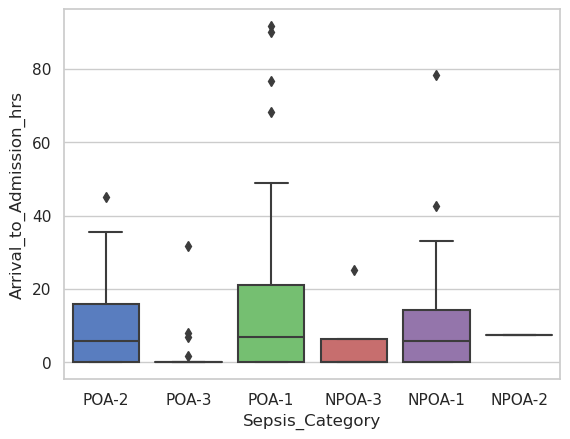

In [66]:
sns.boxplot(
    data=df_sepsis_v2_billing.filter(
    pl.col("Computed_Sepsis_Category").is_null()
	).to_pandas(),
    x = "Sepsis_Category",
	y = "Arrival_to_Admission_hrs"
)

In [72]:
df_sepsis_v2_billing.with_columns(
	pl.col("Computed_Sepsis_Category").str.extract(r"(\d$)").cast(pl.Int64).alias("score")
)

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,los_source,Death_Flag,InpatientAdmissionInstant,Arrival_Instant,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,Arrival_to_Admission_hrs,score
i64,str,str,f64,i64,datetime[μs],datetime[μs],str,str,str,str,f64,i64
687038913,"""POA-3""","""POA-2""",22.0,0,2023-08-15 13:35:00,2023-08-15 08:19:00,"""0""","""0""","""0""","""0""",5.266667,2
697150447,"""NPOA-1""","""NPOA-1""",5.0,0,2024-01-26 13:38:00,2024-01-26 13:38:00,"""0""","""0""","""0""","""0""",0.0,1
662909282,"""POA-3""","""POA-3""",10.0,0,2022-06-01 03:59:00,2022-06-01 01:15:00,"""0""","""0""","""0""","""0""",2.733333,3
683097675,"""POA-2""",null,2.0,0,2023-06-02 02:10:00,2023-06-02 02:10:00,"""0""","""0""","""0""","""0""",0.0,null
683211004,"""POA-1""","""POA-1""",3.0,0,2023-06-05 15:11:00,2023-06-05 10:38:00,"""1""","""0""","""1""","""0""",4.55,1
…,…,…,…,…,…,…,…,…,…,…,…,…
719857191,"""POA-1""","""POA-2""",4.0,0,2025-01-23 13:28:00,2025-01-22 08:29:00,"""0""","""0""","""0""","""0""",28.983333,2
671012562,"""POA-3""","""NPOA-1""",12.0,0,2022-10-23 17:00:00,2022-10-19 11:43:00,"""0""","""0""","""0""","""0""",101.283333,1
691543274,"""POA-1""","""POA-2""",4.0,0,2023-10-20 18:29:00,2023-10-20 08:07:00,"""1""","""0""","""0""","""0""",10.366667,2


In [77]:
df_sepsis_v2_billing.filter(
    pl.col("Sepsis_Category").is_in(["NPOA-2", "POA-2", "POA-3", "NPOA-3"])&
	(pl.col("Computed_Sepsis_Category").str.extract(r"(\d$)").cast(pl.Int64) == 1)
).sort(by="Arrival_Instant", descending=True)

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,los_source,Death_Flag,InpatientAdmissionInstant,Arrival_Instant,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,Arrival_to_Admission_hrs
i64,str,str,f64,i64,datetime[μs],datetime[μs],str,str,str,str,f64
753540165,"""POA-3""","""POA-1""",5.0,0,2026-05-23 03:40:00,2026-05-23 03:40:00,"""1""","""0""","""1""","""0""",0.0
753263585,"""POA-3""","""POA-1""",7.0,0,2026-05-19 22:59:00,2026-05-19 16:25:00,"""0""","""0""","""0""","""0""",6.566667
753124914,"""POA-2""","""POA-1""",3.0,0,2026-05-19 15:24:00,2026-05-18 12:05:00,"""1""","""0""","""0""","""0""",27.316667
752952630,"""POA-3""","""POA-1""",4.0,0,2026-05-15 16:17:00,2026-05-14 15:50:00,"""0""","""0""","""0""","""0""",24.45
752771169,"""POA-2""","""POA-1""",6.0,0,2026-05-13 04:00:00,2026-05-12 21:11:00,"""1""","""0""","""0""","""0""",6.816667
…,…,…,…,…,…,…,…,…,…,…,…
663476501,"""POA-3""","""POA-1""",7.0,0,2022-06-12 06:09:00,2022-06-11 20:38:00,"""1""","""0""","""0""","""0""",9.516667
663314640,"""POA-2""","""POA-1""",5.0,0,2022-06-08 22:05:00,2022-06-08 13:27:00,"""0""","""0""","""0""","""0""",8.633333
663197628,"""POA-2""","""POA-1""",6.0,0,2022-06-07 04:33:00,2022-06-06 20:10:00,"""0""","""0""","""0""","""0""",8.383333


In [ ]:
# 4 encounters
df_sepsis_v2_billing.filter(
    pl.col("Sepsis_Category").is_in(["NPOA-2", "POA-2", "POA-3", "NPOA-3"])&
	(pl.col("Computed_Sepsis_Category").str.extract(r"(\d$)").cast(pl.Int64) == 1)
).sort(by="Arrival_Instant", descending=True).group_by(
    ["Sepsis_Category"]
).agg(
    pl.col("EncounterEpicCsn").first()
)

Sepsis_Category,EncounterEpicCsn
str,i64
"""POA-3""",753540165
"""POA-2""",753124914
"""NPOA-3""",749580276
"""NPOA-2""",744161990


In [32]:
# 31 encounters
df_sepsis_v2_billing.filter(
    pl.col("Sepsis_Category").str.starts_with("P")&
	(pl.col("Computed_Sepsis_Category").str.extract(r"^(\w)") == 'N')&
	((pl.col("Computed_Sepsis_Category").str.extract(r"(\d$)").cast(pl.Int64))<(pl.col("Sepsis_Category").str.extract(r"(\d$)").cast(pl.Int64)))
).sort(by="Arrival_Instant", descending=True)

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,los_source,Death_Flag,InpatientAdmissionInstant,Arrival_Instant,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,Arrival_to_Admission_hrs
i64,str,str,f64,i64,datetime[μs],datetime[μs],str,str,str,str,f64
751556494,"""POA-3""","""NPOA-2""",5.0,1,2026-04-26 07:12:00,2026-04-26 00:54:00,"""1""","""0""","""0""","""0""",6.3
750145277,"""POA-3""","""NPOA-1""",12.0,0,2026-04-07 20:14:00,2026-04-07 11:33:00,"""1""","""0""","""0""","""0""",8.683333
742495783,"""POA-2""","""NPOA-1""",22.0,0,2025-12-14 16:29:00,2025-12-14 09:24:00,"""1""","""0""","""0""","""0""",7.083333
738629405,"""POA-3""","""NPOA-2""",32.0,0,2025-10-19 03:04:00,2025-10-16 20:45:00,"""0""","""0""","""0""","""0""",54.316667
732613427,"""POA-3""","""NPOA-2""",80.0,0,2025-08-04 14:36:00,2025-08-03 19:36:00,"""0""","""0""","""0""","""0""",19.0
…,…,…,…,…,…,…,…,…,…,…,…
688159760,"""POA-2""","""NPOA-1""",7.0,0,2023-09-06 11:07:00,2023-09-04 09:13:00,"""0""","""0""","""0""","""0""",49.9
680127098,"""POA-3""","""NPOA-2""",42.0,0,2023-04-10 23:21:00,2023-04-10 12:08:00,"""1""","""0""","""0""","""0""",11.216667
672712622,"""POA-3""","""NPOA-2""",6.0,1,2022-11-19 17:05:00,2022-11-17 11:08:00,"""0""","""0""","""0""","""0""",53.95


In [38]:
# 31 encounters
enc_31 = df_sepsis_v2_billing.filter(
    pl.col("Sepsis_Category").str.starts_with("P")&
	(pl.col("Computed_Sepsis_Category").str.extract(r"^(\w)") == 'N')&
	((pl.col("Computed_Sepsis_Category").str.extract(r"(\d$)").cast(pl.Int64))<(pl.col("Sepsis_Category").str.extract(r"(\d$)").cast(pl.Int64)))
).sort(by="Arrival_Instant", descending=True)['EncounterEpicCsn'].unique().to_list()
#.group_by(
#     ["Sepsis_Category"]
# ).agg(
#     pl.col("EncounterEpicCsn").first()
# )

In [51]:
df_all_3_diagnosis = df_all_3.filter(
    (pl.col("Type") == "Diagnosis Event")&
	(pl.col("EncounterEpicCsn").is_in(enc_31))&
	(pl.col("Event_Name").str.contains("Sepsis"))&
	(pl.col("Event_Grouper")!="Billing Diagnosis")
).sort(by="Event_DateTime").select(
    "EncounterEpicCsn", "Type", "Event_Name", "Event_Grouper", "Event_DateTime"
)

In [54]:
df_sepsis_v2_billing.filter(
    pl.col("Sepsis_Category").str.starts_with("P")&
	(pl.col("Computed_Sepsis_Category").str.extract(r"^(\w)") == 'N')&
	((pl.col("Computed_Sepsis_Category").str.extract(r"(\d$)").cast(pl.Int64))<(pl.col("Sepsis_Category").str.extract(r"(\d$)").cast(pl.Int64)))
).sort(by="Arrival_Instant", descending=True).join(
    df_all_3_diagnosis, on="EncounterEpicCsn", how="left"
).filter(pl.col("Arrival_to_Admission_hrs")<10)

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,los_source,Death_Flag,InpatientAdmissionInstant,Arrival_Instant,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,Arrival_to_Admission_hrs,Type,Event_Name,Event_Grouper,Event_DateTime
i64,str,str,f64,i64,datetime[μs],datetime[μs],str,str,str,str,f64,str,str,str,datetime[μs]
751556494,"""POA-3""","""NPOA-2""",5.0,1,2026-04-26 07:12:00,2026-04-26 00:54:00,"""1""","""0""","""0""","""0""",6.3,null,null,null,null
750145277,"""POA-3""","""NPOA-1""",12.0,0,2026-04-07 20:14:00,2026-04-07 11:33:00,"""1""","""0""","""0""","""0""",8.683333,null,null,null,null
742495783,"""POA-2""","""NPOA-1""",22.0,0,2025-12-14 16:29:00,2025-12-14 09:24:00,"""1""","""0""","""0""","""0""",7.083333,null,null,null,null
729561331,"""POA-3""","""NPOA-2""",28.0,0,2025-06-16 14:53:00,2025-06-16 14:53:00,"""0""","""0""","""0""","""0""",0.0,"""Diagnosis Event""","""Sepsis without acute organ dys…","""Encounter Diagnosis""",2025-06-22 01:48:50.523
724001608,"""POA-3""","""NPOA-2""",16.0,1,2025-03-26 00:36:00,2025-03-25 16:57:00,"""0""","""0""","""0""","""0""",7.65,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
695447466,"""POA-2""","""NPOA-1""",21.0,0,2023-12-28 03:12:00,2023-12-27 20:19:00,"""0""","""0""","""0""","""0""",6.883333,"""Diagnosis Event""","""Sepsis with encephalopathy wit…","""Encounter Diagnosis""",2024-01-10 02:56:29.243
695447466,"""POA-2""","""NPOA-1""",21.0,0,2023-12-28 03:12:00,2023-12-27 20:19:00,"""0""","""0""","""0""","""0""",6.883333,"""Diagnosis Event""","""Sepsis with encephalopathy wit…","""Encounter Diagnosis""",2024-01-10 02:56:29.243
694281721,"""POA-3""","""NPOA-2""",54.0,1,2023-12-07 04:48:00,2023-12-06 22:51:00,"""0""","""0""","""0""","""0""",5.95,"""Diagnosis Event""","""Sepsis""","""Hospital Problem""",2023-12-17 02:26:23.717


In [47]:
df_v2_v3_joined = df_sepsis_v3_max_first.select(
	"EncounterEpicCsn",
	pl.col("Computed_Sepsis_Category").alias("Computed_Sepsis_Category_v3")
).join(
	df_sepsis_v2_max_first.select(
	"EncounterEpicCsn",
	"Computed_Sepsis_Category",
	"Sepsis_Category"
	),
	on="EncounterEpicCsn",
	how="inner"
)
df_v2_v3_joined

EncounterEpicCsn,Computed_Sepsis_Category_v3,Computed_Sepsis_Category,Sepsis_Category
i64,str,str,str
687038913,"""POA-2""","""POA-2""","""POA-3"""
697150447,"""NPOA-1""","""NPOA-1""","""NPOA-1"""
662909282,"""POA-3""","""POA-3""","""POA-3"""
683097675,null,null,"""POA-2"""
683211004,null,"""POA-1""","""POA-1"""
…,…,…,…
719857191,"""POA-2""","""POA-2""","""POA-1"""
671012562,null,"""NPOA-1""","""POA-3"""
691543274,"""POA-2""","""POA-2""","""POA-1"""


In [60]:
df_v2_v3_joined.filter(
    pl.col("Computed_Sepsis_Category_v3").str.extract(r"(\d)$") != pl.col("Computed_Sepsis_Category").str.extract(r"(\d)$")
)

EncounterEpicCsn,Computed_Sepsis_Category_v3,Computed_Sepsis_Category,Sepsis_Category
i64,str,str,str


In [62]:
df_sepsis_v3_firstonset

EncounterEpicCsn,first_sepsis_instant,sepsis_score,min_infect_dt,max_infect_dt,min_Event_DateTime,max_Event_DateTime
i64,datetime[μs],i32,datetime[μs],datetime[μs],datetime[μs],datetime[μs]
659308243,2022-06-14 16:40:00,2,2022-06-14 22:10:00,2022-06-15 23:40:38,2022-06-14 16:40:00,2022-06-14 16:40:00
660956097,2022-06-27 23:58:00,2,2022-06-28 06:10:00,2022-06-28 10:39:00,2022-06-27 23:58:00,2022-06-27 23:58:00
661424247,2022-08-28 04:56:00,1,2022-08-28 05:30:00,2022-08-28 10:56:00,2022-08-28 04:56:00,2022-08-28 04:56:00
661471289,2022-06-07 12:00:00,2,2022-06-07 19:47:00,2022-06-08 21:58:00,2022-06-07 12:00:00,2022-06-07 12:00:00
662152913,2022-08-15 14:10:00,1,2022-08-15 16:45:00,2022-08-16 01:55:00,2022-08-15 14:10:00,2022-08-15 14:10:00
…,…,…,…,…,…,…
753558469,2026-05-24 18:39:00,2,2026-05-24 18:39:00,2026-05-24 18:39:00,2026-05-24 18:40:00,2026-05-25 16:00:00
753563196,2026-05-25 04:49:00,2,2026-05-25 04:49:00,2026-05-25 04:49:00,2026-05-25 05:17:00,2026-05-25 08:00:00
753573877,2026-05-25 20:45:00,1,2026-05-25 21:53:00,2026-05-26 13:06:06,2026-05-25 20:45:00,2026-05-25 20:45:00


In [63]:
df_sepsis_v2_firstonset

EncounterEpicCsn,first_sepsis_instant,sepsis_score,min_infect_dt,max_infect_dt,min_Event_DateTime,max_Event_DateTime
i64,datetime[μs],i32,datetime[μs],datetime[μs],datetime[μs],datetime[μs]
659308243,2022-06-14 17:52:00,3,2022-06-14 22:10:00,2022-06-14 22:10:00,2022-06-14 17:52:00,2022-06-14 17:52:00
660956097,2022-06-27 18:28:00,1,2022-06-28 06:10:00,2022-06-28 06:10:00,2022-06-27 18:28:00,2022-06-27 18:28:00
661424247,2022-08-28 02:18:00,3,2022-08-28 05:30:00,2022-08-28 05:30:00,2022-08-28 02:18:00,2022-08-28 02:18:00
661471289,2022-06-07 12:07:00,2,2022-06-07 19:47:00,2022-06-07 19:47:00,2022-06-07 12:07:00,2022-06-07 12:07:00
662152913,2022-08-15 14:10:00,1,2022-08-15 16:45:00,2022-08-15 16:45:00,2022-08-15 14:10:00,2022-08-15 14:10:00
…,…,…,…,…,…,…
753558469,2026-05-24 18:39:00,2,2026-05-24 18:39:00,2026-05-24 18:39:00,2026-05-24 18:49:00,2026-05-24 18:54:00
753563196,2026-05-25 04:42:00,1,2026-05-25 04:49:00,2026-05-25 04:49:00,2026-05-25 04:42:00,2026-05-25 04:42:00
753573877,2026-05-25 16:27:00,1,2026-05-25 21:53:00,2026-05-25 21:53:00,2026-05-25 16:27:00,2026-05-25 16:27:00


In [68]:
df_sepsis_firstonset_joined = df_sepsis_v3_firstonset.select(
    "EncounterEpicCsn",
	pl.col("sepsis_score").alias("Sepsis_score_v3"),
    pl.col("first_sepsis_instant").alias("first_sepsis_instant_v3")
).join(
    df_sepsis_v2_firstonset.select(
		"EncounterEpicCsn",
		pl.col("sepsis_score").alias("Sepsis_score_v2"),
		pl.col("first_sepsis_instant").alias("first_sepsis_instant_v2")
	),
	on="EncounterEpicCsn",
    how="inner"
).with_columns(
    (pl.col("first_sepsis_instant_v3")-pl.col("first_sepsis_instant_v2")).dt.total_hours(fractional=True).alias("first_sepsis_instant_diff_hrs")
)
# filter(
#     pl.col("Sepsis_score_v3") < pl.col("Sepsis_score_v2")
# )

In [69]:
df_sepsis_firstonset_joined.group_by(
    ["Sepsis_score_v3", "Sepsis_score_v2"]
).agg(
    pl.col("first_sepsis_instant_diff_hrs").mean().alias("mean_first_sepsis_instant_diff_hrs"),
    pl.col("first_sepsis_instant_diff_hrs").median().alias("median_first_sepsis_instant_diff_hrs"),
    pl.col("first_sepsis_instant_diff_hrs").quantile(0.25).alias("q1_first_sepsis_instant_diff_hrs"),
    pl.col("first_sepsis_instant_diff_hrs").quantile(0.75).alias("q3_first_sepsis_instant_diff_hrs"),
)

Sepsis_score_v3,Sepsis_score_v2,mean_first_sepsis_instant_diff_hrs,median_first_sepsis_instant_diff_hrs,q1_first_sepsis_instant_diff_hrs,q3_first_sepsis_instant_diff_hrs
i32,i32,f64,f64,f64,f64
2,2,13.319684,0.0,-0.016667,0.0
3,1,9.752063,0.3,0.083333,1.35
2,3,20.018762,-0.033333,-0.133333,0.0
1,3,12.073541,-0.083333,-0.233333,-0.033333
1,2,18.003515,-0.066667,-0.2,-0.016667
2,1,18.385147,0.316667,0.05,1.483333
3,2,5.757866,0.0,0.0,0.0
1,1,7.619172,0.0,0.0,0.766667
3,3,1.443175,0.0,0.0,0.0


In [ ]:

df_sepsis_firstonset_joined.filter(
    (pl.col("Sepsis_score_v2")==3)&(pl.col("Sepsis_score_v3")<3)&(pl.col("first_sepsis_instant_diff_hrs")<0)
).sort(by="first_sepsis_instant_diff_hrs", descending=False).head(10)

EncounterEpicCsn,Sepsis_score_v3,first_sepsis_instant_v3,Sepsis_score_v2,first_sepsis_instant_v2,first_sepsis_instant_diff_hrs
i64,i32,datetime[μs],i32,datetime[μs],f64
716915128,2,2024-12-03 04:48:00,3,2024-12-04 06:49:00,-26.016667
688143138,2,2023-09-01 02:46:00,3,2023-09-02 02:57:00,-24.183333
728125584,2,2025-05-24 01:13:00,3,2025-05-24 18:44:00,-17.516667
700671960,2,2024-05-03 00:10:00,3,2024-05-03 12:19:00,-12.15
688096687,2,2023-09-09 23:00:00,3,2023-09-10 10:00:00,-11.0
667278895,1,2022-08-27 00:37:00,3,2022-08-27 07:20:00,-6.716667
689671335,2,2023-09-21 14:51:00,3,2023-09-21 20:38:00,-5.783333
705386461,2,2024-06-10 02:46:00,3,2024-06-10 06:09:00,-3.383333
728904161,2,2025-06-05 23:03:00,3,2025-06-06 01:56:18.113,-2.888365


In [77]:
df_sepsis_v3.filter(
    (pl.col("EncounterEpicCsn") == 667278895)
).sort(by='sepsis_instance', descending=False).filter(pl.col("sepsis_score")==3)

EncounterEpicCsn,infect_dt,Event_DateTime,sepsis_instance,sepsis_score
i64,datetime[μs],datetime[μs],datetime[μs],i32
667278895,2022-08-27 12:34:00,2022-08-27 20:46:00,2022-08-27 12:34:00,3
667278895,2022-08-27 12:34:00,2022-08-27 16:05:55,2022-08-27 12:34:00,3
667278895,2022-08-27 12:34:00,2022-08-28 07:30:00,2022-08-27 12:34:00,3
667278895,2022-08-27 12:34:00,2022-08-28 07:15:00,2022-08-27 12:34:00,3
667278895,2022-08-27 12:34:00,2022-08-27 16:06:00,2022-08-27 12:34:00,3
…,…,…,…,…
667278895,2022-08-28 04:13:00,2022-08-28 04:45:00,2022-08-28 04:13:00,3
667278895,2022-08-28 04:13:00,2022-08-28 07:15:00,2022-08-28 04:13:00,3
667278895,2022-08-28 04:13:00,2022-08-28 04:13:00,2022-08-28 04:13:00,3


In [ ]:
# Encounters with timestamps
{
    "667278895":["2022-08-27 00:37:00", "2022-08-27 07:20:00"] # V3 detected sepsis 1 6 hours earlier than V2, and detected septic shock at "2022-08-27 12:34:00" Which is 5 hours after V2
}

### First time a POA-3, NPOA-3 billing and computed receive pressors

In [47]:
# Out of those who only have POA-3/NPOA-3 billing codes
# poa3_npoa3_billing_comp_encs = df_sepsis_v2_max_first.filter(
#     pl.col("Computed_Sepsis_Category").is_in(["NPOA-3", 'POA-3'])|
#     pl.col("Sepsis_Category").is_in(["NPOA-3", 'POA-3'])
# )['EncounterEpicCsn'].unique()
# len(poa3_npoa3_billing_comp_encs)

In [48]:
septic_shock_pressors = [
    "Norepinephrine",
    "Vasopressin",
    "Epinephrine",
    "Dopamine",
    "Phenylephrine",
]

In [ ]:
df_meds_3.filter(
	# pl.col("EncounterEpicCsn").is_in(poa3_npoa3_billing_comp_encs)& # This condition to limit to those with POA-3/NPOA-3 billing codes, or computed
	pl.col("Event_Grouper").is_in(septic_shock_pressors)
).group_by("EncounterEpicCsn").agg(pl.col("Event_DateTime").first()).sort(by=["EncounterEpicCsn", "Event_DateTime"])

EncounterEpicCsn,Event_DateTime
i64,datetime[μs]
659308243,2022-06-15 01:22:03
660956097,2022-06-28 03:59:07
661424247,2022-08-29 11:36:24
662358356,2022-06-13 10:00:00
662608744,2022-07-14 14:28:00
…,…
753425965,2026-05-28 02:02:51
753466755,2026-05-22 09:51:41
753498904,2026-05-22 15:51:16


In [32]:
# Meds
df_pressors_first = df_meds_3.join(
	df_meds_3.filter(
		# pl.col("EncounterEpicCsn").is_in(poa3_npoa3_billing_comp_encs)& # This condition to limit to those with POA-3/NPOA-3 billing codes, or computed
		pl.col("Event_Grouper").is_in(septic_shock_pressors)
	).group_by("EncounterEpicCsn").agg(pl.col("Event_DateTime").min()),
    on=["EncounterEpicCsn", "Event_DateTime"],
	how='inner',
	suffix='_firstpressortime'
).filter(pl.col("Event_Grouper").is_in(septic_shock_pressors)).sort(by=["EncounterEpicCsn", "Event_DateTime"])


df_pressors_first = df_all_3.join(
	df_all_3.filter(
		# pl.col("EncounterEpicCsn").is_in(poa3_npoa3_billing_comp_encs)&
		pl.col("Event_Grouper").is_in(septic_shock_pressors)
	).group_by("EncounterEpicCsn").agg(pl.col("Event_DateTime").min()),
    on=["EncounterEpicCsn", "Event_DateTime"],
	how='inner',
	suffix='_firstpressortime'
).filter(pl.col("Event_Grouper").is_in(septic_shock_pressors)).sort(by=["EncounterEpicCsn", "Event_DateTime"])

In [33]:
df_pressors_first

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN
i64,datetime[μs],str,str,str,f64,str,str,i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str
659308243,2022-06-15 01:22:03,"""Medication Administration""","""Norepinephrine""","""NOREPINEPHRINE BITARTRATE 8 MG…",0.01,"""mcg/kg/min""",null,95196619,70.03696,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",659308243,2022-06-14 00:00:00,2022-07-26 00:00:00,2022-06-14 10:20:00,2022-06-14 08:29:00,2022-06-14 10:20:00,"""No""","""Inpatient""","""Inpatient""","""Urology""",42,"""UH 02O SICU""","""UH 06G""","""Elective""","""Home & Outside Location""","""OR Admission""","""Urothelial cancer (*)""","""Carcinoma in situ of bladder""","""Resection of Bladder, Percutan…",0,"""NPOA-3""","""NPOA-3""",134.0,16.0,63.0,1.24,137.8,0.96,60.333333,5.842,"""2022-06-14 22:10:00.0000000""","""Lactate + Two Blood Culture Or…","""1""","""0""","""0""","""0""","""0""","""0"""
660956097,2022-06-28 03:59:07,"""Medication Administration""","""Epinephrine""","""EPINEPHRINE HCL 4 MG/250 ML (1…",0.05,"""mcg/kg/min""",null,96831022,73.278576,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",660956097,2022-06-27 00:00:00,2022-07-01 00:00:00,2022-06-27 10:37:00,2022-06-27 18:17:00,2022-06-28 02:40:00,"""No""","""Inpatient""","""Observation""","""Neurocritical Care""",4,"""UH 06G""","""UH 03O NEURO ICU""","""Urgent""","""Home & Outside Location""","""OR Admission""","""Cerebrovascular accident (CVA)…","""Cerebral infarction due to emb…","""Extirpate matter fr Intracran …",1,"""POA-3""","""POA-3""",138.0,null,71.0,0.98,230.0,1.5,81.0,8.16,"""2022-06-28 06:10:00.0000000""","""Lactate + Two Blood Culture Or…","""1""","""0""","""0""","""0""","""0""","""0"""
661424247,2022-08-28 12:04:34,"""Medication Administration""","""Norepinephrine""","""NOREPINEPHRINE BITARTRATE 8 MG…",0.01,"""mcg/kg/min""",null,96831470,62.119096,"""Female""","""Non-Hispanic/Latino""","""White""","""0""",661424247,2022-08-25 00:00:00,2022-09-21 00:00:00,2022-08-25 07:35:00,2022-08-25 16:50:00,2022-08-26 09:23:00,"""No""","""Inpatient""","""Observation""","""Endocrine Surgery""",27,"""UH 07O""","""UH 07O""","""Elective""","""Home & Outside Location""","""OR Admission""","""Left adrenal mass (*)""","""Benign neoplasm of left adrena…","""Resection of Left Adrenal Glan…",0,"""NPOA-3""","""NPOA-3""",136.0,16.0,66.0,0.473333,228.0,null,109.0,5.64,"""2022-08-28 05:30:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""0""","""0""","""0""","""0"""
662358356,2022-06-13 05:21:00,"""Medication Administration""","""Norepinephrine""","""NOREPINEPHRINE BITARTRATE 8 MG…",0.01,"""mcg/kg/min""",null,94786789,72.429842,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",662358356,2022-06-02 00:00:00,2022-06-13 00:00:00,2022-06-02 05:05:00,2022-06-02 21:20:00,2022-06-02 05:05:00,"""No""","""Inpatient""","""Inpatient""","""ENT""",11,"""UH 02O SICU""","""UH 02O SICU""","""Elective""","""Home & Ou

### Get the cohort which had the first vasopressors within 48 hours of arrival and 24 hours of admission
In the previous few cells, I disabled the condition that the encounters had to be POA-3/NPOA-3 either in billing cateogry or computed category

In [34]:
df_pressors_first.describe()

statistic,EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN
str,f64,str,str,str,str,f64,str,str,f64,f64,str,str,str,str,f64,str,str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str
"""count""",4611.0,"""4611""","""4611""","""4611""","""4611""",4604.0,"""4611""","""0""",4611.0,4611.0,"""4611""","""4611""","""4611""","""4611""",4611.0,"""4611""","""4611""","""4611""","""4611""","""4611""","""4611""","""4611""","""4611""","""4611""",4611.0,"""4611""","""4611""","""4611""","""4611""","""4611""","""4611""","""4611""","""4611""",4611.0,"""4611""","""4611""",4317.0,2693.0,3167.0,3940.0,4067.0,3735.0,3695.0,3940.0,"""4541""","""4541""","""4611""","""4611""","""4611""","""4611""","""4611""","""4611"""
"""null_count""",0.0,"""0""","""0""","""0""","""0""",7.0,"""0""","""4611""",0.0,0.0,"""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,"""0""","""0""",294.0,1918.0,1444.0,671.0,544.0,876.0,916.0,671.0,"""70""","""70""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",7.0740e8,"""2024-06-27 22:39:04.671654""",null,null,null,5.922952,null,null,8.6932e7,62.11444,null,null,null,null,7.0740e8,"""2024-06-22 03:13:18.698763""","""2024-07-14 21:51:57.501626""","""2024-06-22 16:10:17.657774""","""2024-06-22 20:45:48.327911""","""2024-06-22 23:48:48.458035""",null,null,null,null,22.780959,null,null,null,null,null,null,null,null,0.314249,null,null,122.025249,16.811363,82.923587,1.788756,220.274738,1.316948,69.169866,9.068313,null,null,null,null,null,null,null,null
"""std""",2.6142e7,null,null,null,null,58.594693,null,null,1.4186e7,16.183369,null,null,null,null,2.6142e7,null,null,null,null,null,null,null,null,null,28.424939,null,null,null,null,null,null,null,null,0.464266,null,null,16.045076,1.600308,14.141795,2.249675,110.153649,2.929385,36.021443,7.734741,null,null,null,null,null,null,null,null
"""min""",6.59308243e8,"""2022-06-01 04:12:00""","""Medication Administration""","""Dopamine""","""BUPIVACAINE-EPINEPHRINE (PF) 0…",0.004,"""*Unspecified""",null,5.013267e6,18.346338,"""Female""","""American Indian or Alaska Nati…","""American Indian or Alaska Nati…","""0""",6.59308243e8,"""2022-06-01 00:00:00""","""2022-06-04 00:00:00""","""2022-06-01 00:49:00""","""2022-06-01 03:59:00""","""2022-06-01 03:59:00""","""No""","""Inpatient""","""*Unspecified""","""Acute Care Emergency Surgery""",1.0,"""*Unspecified""","""UH 01 ED""","""Elective""","""Home & Outside Location""","""Direct Admission""","""(HFpEF) heart failure with pre…","""Abdominal aortic aneurysm, rup…","""*Unspecified""",0.0,"""NPOA-1""","""NPOA-1""",40.0,1.0,40.0,0.16,11.055422,0.054167,1.166667,0.301304,"""2022-06-01 00:56:00.0000000""","""Code Sepsis Order""","""0""","""0""","""0""","""0""","""0""","""0"""
"""25%""",6.84640549e8,"""2023-07-07 16:19:00""",null,null,null,0.01,null,null,7.2954553e7,51.969883,null,null,null,null,6.84640549e8,"""2023-07-01 00:00:00""","""2023-07-27 00:00:00""","""2023-

In [35]:
df_pressors_first['EncounterEpicCsn'].n_unique(), len(df_pressors_first)

(4590, 4611)

In [47]:
df_pressors_first = df_pressors_first.unique(subset=['EncounterEpicCsn', "Event_DateTime"])
df_pressors_first['EncounterEpicCsn'].n_unique(), len(df_pressors_first)

(4590, 4590)

In [61]:
df_pressors_first = df_pressors_first.filter(
    ~pl.col("Sepsis_Category").str.starts_with("U")
)
df_pressors_first.shape

(4569, 52)

In [60]:
df_pressors_sepsis_first = df_pressors_first.join(
    df_sepsis_v2_max_first,
    on="EncounterEpicCsn",
	how="inner"
)
df_pressors_sepsis_first.shape

(4569, 99)

In [63]:
df_pressors_before_48hrs_arrival = df_pressors_sepsis_first.filter(
    (pl.col("Event_DateTime")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True)<48
)

df_pressors_before_24hrs_admission = df_pressors_sepsis_first.filter(
    (pl.col("Event_DateTime")-pl.col("InpatientAdmissionInstant")).dt.total_hours(fractional=True)<24
)

In [57]:
df_pressors_before_48hrs_arrival["Sepsis_Category"].value_counts(sort=True)

Sepsis_Category,count
str,u64
"""POA-3""",1928
"""NPOA-3""",235
"""POA-1""",216
"""POA-2""",82
"""NPOA-1""",74
"""NPOA-2""",20


In [64]:
df_pressors_before_48hrs_arrival["Computed_Sepsis_Category"].value_counts(sort=True)

Computed_Sepsis_Category,count
str,u64
"""POA-3""",1449
"""POA-2""",898
"""POA-1""",157
"""NPOA-3""",22
null,15
"""NPOA-2""",12
"""NPOA-1""",2


In [66]:
df_pressors_before_24hrs_admission['Sepsis_Category'].value_counts(sort=True)

Sepsis_Category,count
str,u64
"""POA-3""",1815
"""POA-1""",191
"""NPOA-3""",160
"""POA-2""",69
"""NPOA-1""",60
"""NPOA-2""",11


In [67]:
df_pressors_before_24hrs_admission['Computed_Sepsis_Category'].value_counts(sort=True)

Computed_Sepsis_Category,count
str,u64
"""POA-3""",1298
"""POA-2""",814
"""POA-1""",150
"""NPOA-3""",20
null,13
"""NPOA-2""",10
"""NPOA-1""",1


In [ ]:
"""
Sepsis category visualization utilities.

Two main functions:
  1. build_sepsis_crosstab  — produces the crosstab DataFrame that
     plot_sepsis_heatmap_with_row_and_col_totals expects.
  2. plot_distribution_comparison — grouped bar chart (billing vs computed).

Usage is shown at the bottom of this file.
"""

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# Canonical ordering: POA severity 1-3, then NPOA severity 1-3
SEPSIS_CATEGORY_ORDER = [
    "POA-1", "POA-2", "POA-3",
    "NPOA-1", "NPOA-2", "NPOA-3",
]


# ---------------------------------------------------------------------------
# 1. Crosstab builder
# ---------------------------------------------------------------------------
def build_sepsis_crosstab(
    df: pl.DataFrame,
    row_col: str = "Computed_Sepsis_Category",
    col_col: str = "Sepsis_Category",
    categories: list[str] | None = None,
    index_col_name: str = "max_sepsis_score",
    sum_label: str = "sum",
) -> pl.DataFrame:
    """
    Build a contingency table from two categorical columns.

    Returns a Polars DataFrame in the exact shape that
    ``plot_sepsis_heatmap_with_row_and_col_totals`` expects:

        index_col | cat-1 | cat-2 | ... | cat-N | sum
        --------- | ----- | ----- | ... | ----- | ---
        cat-1     |   5   |   2   | ... |   0   |  7
        ...       |  ...  |  ...  | ... |  ...  | ...
        sum       |  10   |   8   | ... |   3   | 50

    Parameters
    ----------
    df : pl.DataFrame
        Must contain *row_col* and *col_col*.
    row_col : str
        Column whose values become the rows (default: Computed).
    col_col : str
        Column whose values become the columns (default: Billing).
    categories : list[str] | None
        Ordered category labels.  Defaults to SEPSIS_CATEGORY_ORDER.
    index_col_name : str
        Name of the row-label column in the output (must match the
        ``index_col`` arg you pass to the heatmap plotter).
    sum_label : str
        Label used for the marginal row / column.
    """
    if categories is None:
        categories = SEPSIS_CATEGORY_ORDER

    # --- Step 1: count every (row_val, col_val) pair ---
    counts = df.group_by([row_col, col_col]).len()
    # Result has columns: [row_col, col_col, "len"]

    # --- Step 2: pivot to wide format ---
    pivot = counts.pivot(
        values="len",
        index=row_col,
        on=col_col,
    ).fill_null(0)

    # --- Step 3: guarantee every category exists as a column ---
    for cat in categories:
        if cat not in pivot.columns:
            pivot = pivot.with_columns(pl.lit(0).alias(cat))

    # --- Step 4: guarantee every category exists as a row ---
    existing_rows = set(pivot[row_col].to_list())
    missing = [c for c in categories if c not in existing_rows]
    if missing:
        filler = pl.DataFrame(
            [{row_col: c, **{cat: 0 for cat in categories}} for c in missing]
        )
        pivot = pl.concat([pivot, filler], how="vertical_relaxed")

    # --- Step 5: rename index column and enforce column order ---
    pivot = pivot.rename({row_col: index_col_name})
    pivot = pivot.select([index_col_name] + categories)

    # --- Step 6: sort rows by the canonical category order ---
    order_df = pl.DataFrame({
        index_col_name: categories,
        "_order": list(range(len(categories))),
    })
    pivot = (
        pivot
        .join(order_df, on=index_col_name, how="left")
        .sort("_order")
        .drop("_order")
    )

    # --- Step 7: add row totals (rightmost column) ---
    pivot = pivot.with_columns(
        pl.sum_horizontal(categories).alias(sum_label)
    )

    # --- Step 8: add column totals (bottom row) ---
    sum_row_data = {index_col_name: sum_label}
    for cat in categories:
        sum_row_data[cat] = pivot[cat].sum()
    sum_row_data[sum_label] = pivot[sum_label].sum()

    sum_row = pl.DataFrame([sum_row_data])
    crosstab = pl.concat([pivot, sum_row], how="vertical_relaxed")

    return crosstab


# ---------------------------------------------------------------------------
# 2. Grouped bar chart
# ---------------------------------------------------------------------------
def plot_distribution_comparison(
    df: pl.DataFrame,
    billing_col: str = "Sepsis_Category",
    computed_col: str = "Computed_Sepsis_Category",
    categories: list[str] | None = None,
    figsize: tuple = (12, 6),
    title: str = "Billing vs Computed Sepsis Category",
    subtitle: str = "",
    filename: str = "sepsis_distribution.png",
    output_path: Path = Path("."),
    dpi: int = 200,
):
    """
    Side-by-side bar chart comparing billing and computed distributions.

    Each bar is annotated with its percentage *and* raw count so the
    audience gets both the relative shape and the absolute numbers.

    Parameters
    ----------
    df : pl.DataFrame
        Must contain *billing_col* and *computed_col*.
    subtitle : str
        Second line of the title (e.g. the time-window label).
    filename : str
        Output file name (saved inside *output_path*).
    output_path : Path
        Directory to save the figure into.
    dpi : int
        Resolution — 200 is good for slides projected at 1080p.
    """
    if categories is None:
        categories = SEPSIS_CATEGORY_ORDER

    total = len(df)

    # --- count per category for each source ---
    billing_counts = np.array([
        df.filter(pl.col(billing_col) == cat).height
        for cat in categories
    ])
    computed_counts = np.array([
        df.filter(pl.col(computed_col) == cat).height
        for cat in categories
    ])

    billing_pct = billing_counts / total * 100
    computed_pct = computed_counts / total * 100

    # --- bar positions ---
    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=figsize)

    bars_b = ax.bar(
        x - width / 2, billing_pct, width,
        label="Billing",
        color="#4C72B0",       # muted blue
        edgecolor="white",
        linewidth=0.5,
    )
    bars_c = ax.bar(
        x + width / 2, computed_pct, width,
        label="Computed",
        color="#DD8452",       # muted orange
        edgecolor="white",
        linewidth=0.5,
    )

    # --- annotate each bar: "pct%\n(count)" ---
    for bars, counts in [(bars_b, billing_counts), (bars_c, computed_counts)]:
        for bar, count in zip(bars, counts):
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.5,
                f"{h:.1f}%\n({count:,d})",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )

    # --- axes, labels, legend ---
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylabel("Percentage (%)", fontsize=12)
    ax.set_xlabel("Sepsis Category", fontsize=12)

    full_title = f"{title}\n{subtitle}" if subtitle else title
    ax.set_title(full_title, fontsize=14, fontweight="bold", pad=15)

    ax.legend(fontsize=11, loc="upper right")

    # clean up spines for a presentation-friendly look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # headroom so annotations don't clip
    ymax = max(billing_pct.max(), computed_pct.max())
    ax.set_ylim(0, ymax * 1.35)

    fig.tight_layout()
    fig.savefig(output_path / filename, dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    return fig


# ---------------------------------------------------------------------------
# Usage example
# ---------------------------------------------------------------------------
# Bar chart
plot_distribution_comparison(
	df_pressors_before_48hrs_arrival,
	subtitle="Pressors Within 48 hrs of Arrival",
	filename="dist_48hrs_arrival.png",
	# output_path=self.output_path,
)

# Crosstab → heatmap
ct_48 = build_sepsis_crosstab(
	df_pressors_before_48hrs_arrival,
	row_col="Computed_Sepsis_Category",
	col_col="Sepsis_Category",
)
plot_sepsis_heatmap_with_row_and_col_totals(
	ct_48,
	normalize="row",
	title_suffix_label="Pressors Within 48 hrs of Arrival",
	filename="heatmap_48hrs_arrival.png",
)

# ── 24 hrs from admission ────────────────────────────────────────────

# Bar chart
plot_distribution_comparison(
	df_pressors_before_24hrs_admission,
	subtitle="Pressors Within 24 hrs of Admission",
	filename="dist_24hrs_admission.png",
	# output_path=self.output_path,
)

# Crosstab → heatmap
ct_24 = build_sepsis_crosstab(
	df_pressors_before_24hrs_admission,
	row_col="Computed_Sepsis_Category",
	col_col="Sepsis_Category",
)
self.plot_sepsis_heatmap_with_row_and_col_totals(
	ct_24,
	normalize="row",
	title_suffix_label="Pressors Within 24 hrs of Admission",
	filename="heatmap_24hrs_admission.png",
)

In [ ]:
df_pressors_first.group_by("EncounterEpicCsn").agg(pl.len()).sort(by='len', descending=True)

EncounterEpicCsn,len
i64,u64
667090299,2
677085552,2
683413776,2
690518387,2
691746620,2
…,…
753425965,1
753466755,1
753498904,1


In [29]:
df_infect_long_3.filter(
    pl.col("EncounterEpicCsn")==663105640
)

EncounterEpicCsn,criterion,infect_dt,suspicion_infection_type
i64,str,datetime[μs],str


### Continue from here
- You want to visualize the time from arrival to first pressors to NPOA-3 POA-3 for both billing and computed
- One observation is that some of the billing NPOA-3, POA-3 are POA-2 and NPOA-2 computed which means that one of the pressors are not included in my algorithm (Dopamine is missing)
- This encounter 663105640 is POA-3 and I could not detect them because they had no suspected infection
- Out of those come up with a bunch of encounters that could be interesting

In [30]:
septic_shock_not_detected_enc = df_sepsis_v2_max_first.join(
	df_pressors_first,
	on="EncounterEpicCsn",
	how="inner"
).with_columns(
    (pl.col("Event_DateTime")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True).alias("arrival to first pressor hrs"),
    (pl.col("Event_DateTime")-pl.col("InpatientAdmissionInstant")).dt.total_hours(fractional=True).alias("admit to first pressor hrs")
).select("EncounterEpicCsn", "Sepsis_Category", "Computed_Sepsis_Category", "arrival to first pressor hrs", "admit to first pressor hrs").filter(pl.col('Computed_Sepsis_Category').is_null())

In [31]:
len(septic_shock_not_detected_enc)

11

In [32]:
df_po3_npoa3_pressors_first_time = df_sepsis_v2_max_first.join(
	df_pressors_first,
	on="EncounterEpicCsn",
	how="inner"
).with_columns(
    (pl.col("Event_DateTime")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True).alias("arrival to first pressor hrs"),
    (pl.col("Event_DateTime")-pl.col("InpatientAdmissionInstant")).dt.total_hours(fractional=True).alias("admit to first pressor hrs")
).select("EncounterEpicCsn", "Sepsis_Category", "Computed_Sepsis_Category", "arrival to first pressor hrs", "admit to first pressor hrs")#.filter(pl.col('Computed_Sepsis_Category').is_null())

In [45]:
os.path.abspath(os.curdir)

'/endosome/work/InternalMedicine/s223850/Sepsis'

In [33]:
df_pressor_analysis = pl.read_csv("./notebooks/df_pressors_analysis.csv")

In [34]:
df_pressor_analysis.sort(by=['EncounterEpicCsn'])

EncounterEpicCsn,Sepsis_Category,POA_Arrival+48hrs,arrival to first pressor hrs,admit to first pressor hrs
i64,str,str,f64,f64
659308243,"""NPOA-3""","""POA-3""",15.034167,15.034167
660956097,"""POA-3""","""POA-3""",17.368611,1.318611
661424247,"""NPOA-3""","""NPOA-3""",76.492778,50.692778
662358356,"""NPOA-3""","""POA-3""",264.266667,264.266667
662715699,"""NPOA-3""","""POA-3""",9.016667,9.016667
…,…,…,…,…
753425965,"""NPOA-3""","""NPOA-3""",83.681111,76.014444
753466755,"""POA-3""","""POA-2""",2.311389,0.644722
753498904,"""POA-3""","""POA-3""",4.071111,1.537778


In [35]:
df_pressor_analysis.select('EncounterEpicCsn', pl.col("arrival to first pressor hrs").alias("afph")).join(
	df_po3_npoa3_pressors_first_time,
    on="EncounterEpicCsn",
	how='inner'
).filter(
    (pl.col("afph")!=pl.col("arrival to first pressor hrs"))
)

EncounterEpicCsn,afph,Sepsis_Category,Computed_Sepsis_Category,arrival to first pressor hrs,admit to first pressor hrs
i64,f64,str,str,f64,f64


In [36]:
df_po3_npoa3_pressors_first_time.sort(by='EncounterEpicCsn')

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,arrival to first pressor hrs,admit to first pressor hrs
i64,str,str,f64,f64
659308243,"""NPOA-3""","""POA-3""",15.034167,15.034167
660956097,"""POA-3""","""POA-3""",17.368611,1.318611
661424247,"""NPOA-3""","""NPOA-3""",76.492778,50.692778
662358356,"""NPOA-3""","""POA-3""",264.266667,264.266667
662715699,"""NPOA-3""","""POA-3""",9.016667,9.016667
…,…,…,…,…
753425965,"""NPOA-3""","""NPOA-3""",83.681111,76.014444
753466755,"""POA-3""","""POA-2""",2.311389,0.644722
753498904,"""POA-3""","""POA-3""",4.071111,1.537778


In [37]:
df_all_3.filter(
    (pl.col("EncounterEpicCsn") == 659308243)&
	(pl.col("Event_Grouper").is_in(septic_shock_pressors))
).sort(by="Event_DateTime").select("EncounterEpicCsn", "Event_DateTime", "Event_Grouper", "Arrival_Instant", "InpatientAdmissionInstant")\
.with_columns(
    (pl.col("Event_DateTime")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True).alias("arrival to first pressor hrs"),
)

EncounterEpicCsn,Event_DateTime,Event_Grouper,Arrival_Instant,InpatientAdmissionInstant,arrival to first pressor hrs
i64,datetime[μs],str,datetime[μs],datetime[μs],f64
659308243,2022-06-15 01:22:03,"""Norepinephrine""",2022-06-14 10:20:00,2022-06-14 10:20:00,15.034167
659308243,2022-06-15 02:20:44,"""Vasopressin""",2022-06-14 10:20:00,2022-06-14 10:20:00,16.012222
659308243,2022-06-15 08:10:09,"""Norepinephrine""",2022-06-14 10:20:00,2022-06-14 10:20:00,21.835833
659308243,2022-06-15 12:52:53,"""Norepinephrine""",2022-06-14 10:20:00,2022-06-14 10:20:00,26.548056
659308243,2022-06-15 14:54:20,"""Vasopressin""",2022-06-14 10:20:00,2022-06-14 10:20:00,28.572222
…,…,…,…,…,…
659308243,2022-06-23 22:31:55,"""Vasopressin""",2022-06-14 10:20:00,2022-06-14 10:20:00,228.198611
659308243,2022-06-23 23:10:43,"""Norepinephrine""",2022-06-14 10:20:00,2022-06-14 10:20:00,228.845278
659308243,2022-06-24 05:52:10,"""Norepinephrine""",2022-06-14 10:20:00,2022-06-14 10:20:00,235.536111


In [38]:
df_po3_npoa3_pressors_first_time.sort(by=['EncounterEpicCsn'])

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,arrival to first pressor hrs,admit to first pressor hrs
i64,str,str,f64,f64
659308243,"""NPOA-3""","""POA-3""",15.034167,15.034167
660956097,"""POA-3""","""POA-3""",17.368611,1.318611
661424247,"""NPOA-3""","""NPOA-3""",76.492778,50.692778
662358356,"""NPOA-3""","""POA-3""",264.266667,264.266667
662715699,"""NPOA-3""","""POA-3""",9.016667,9.016667
…,…,…,…,…
753425965,"""NPOA-3""","""NPOA-3""",83.681111,76.014444
753466755,"""POA-3""","""POA-2""",2.311389,0.644722
753498904,"""POA-3""","""POA-3""",4.071111,1.537778


#### Billing NPOA-3 and Computed POA-3 that are surprisingly wrong

In [39]:
df_sepsis_v2_max_first.filter(
    pl.col("PrimaryCodedDiagnosis").str.to_lowercase().str.contains("septic|sepsis") & pl.col("Sepsis_Category").is_in(["POA-3", "NPOA-3"]) & (pl.col("LengthOfStayInDays")<=25)
).select(
     "EncounterEpicCsn",
     "PatientAgeAtAdmission",
	 "AdmissionDateValue",
	 "DischargeDateValue",
     "Arrival_Instant",
     "FirstAdmissionOrderInstant",
     "InpatientAdmissionInstant",
	 "LengthOfStayInDays",
     "AdmittingDepartment",
     "PrimaryCodedDiagnosis",
     "Death_Flag",
	 "Sepsis_Category",
	 "Computed_Sepsis_Category",
 ).with_columns(
     (pl.col("InpatientAdmissionInstant")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True).alias("arrival to admission")
 ).filter(
     pl.col("Sepsis_Category") == "NPOA-3"
 ).sort(by='arrival to admission')

EncounterEpicCsn,PatientAgeAtAdmission,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,LengthOfStayInDays,AdmittingDepartment,PrimaryCodedDiagnosis,Death_Flag,Sepsis_Category,Computed_Sepsis_Category,arrival to admission
i64,f64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],i64,str,str,i64,str,str,f64
693099318,71.381245,2023-11-15 00:00:00,2023-11-18 00:00:00,2023-11-15 20:02:00,2023-11-15 20:17:00,2023-11-15 20:02:00,3,"""UH 06O""","""Sepsis following a procedure, …",1,"""NPOA-3""","""POA-3""",0.0
748664727,65.848049,2026-03-17 00:00:00,2026-04-03 00:00:00,2026-03-17 08:52:00,2026-03-17 14:40:00,2026-03-17 13:07:00,17,"""UH 11G ONC""","""Sepsis, unspecified organism""",0,"""NPOA-3""","""POA-3""",4.25
699846462,57.201916,2024-03-10 00:00:00,2024-03-23 00:00:00,2024-03-10 17:31:00,2024-03-11 00:39:00,2024-03-11 00:45:00,13,"""UH 11G ONC""","""Sepsis, unspecified organism""",1,"""NPOA-3""","""POA-3""",7.233333


In [40]:
df_sepsis_3_v2.filter(pl.col("EncounterEpicCsn").is_in([693099318, 748664727, 699846462]))

EncounterEpicCsn,infect_dt,Event_DateTime,sepsis_instance,sepsis_score
i64,datetime[μs],datetime[μs],datetime[μs],i32
693099318,2023-11-16 14:30:00,2023-11-16 10:45:00,2023-11-16 10:45:00,3
699846462,2024-03-12 07:25:00,2024-03-13 05:25:00,2024-03-12 07:25:00,3
748664727,2026-03-17 09:12:00,2026-03-18 07:51:19,2026-03-17 09:12:00,3


In [41]:
df_po3_npoa3_pressors_first_time.filter(pl.col("EncounterEpicCsn").is_in([693099318, 748664727, 699846462]))

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,arrival to first pressor hrs,admit to first pressor hrs
i64,str,str,f64,f64
693099318,"""NPOA-3""","""POA-3""",37.384444,37.384444
748664727,"""NPOA-3""","""POA-3""",38.633333,34.383333
699846462,"""NPOA-3""","""POA-3""",75.999167,68.765833


In [42]:
df_sepsis_v2_max_first.filter(

    pl.col("EncounterEpicCsn") == 699846462
)

PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,los_source,los_derived,Computed_Sepsis_Category,meds_count
i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,f64,str,u64
97808835,57.201916,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",699846462,2024-03-10 00:00:00,2024-03-23 00:00:00,2024-03-10 17:31:00,2024-03-11 00:39:00,2024-03-11 00:45:00,"""Yes""","""Inpatient""","""Inpatient""","""MICU""",13,"""UH 11G ONC""","""UH 08B MICU""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Severe sepsis with septic shoc…","""Sepsis, unspecified organism""","""Insertion of Endotracheal Airw…",1,"""NPOA-3""","""NPOA-3""",126.0,17.0,71.0,0.956364,186.5,0.433333,92.454545,6.5875,"""2024-03-12 07:25:00.0000000""","""IV Antibiotics + Blood Culture…","""1""","""0""","""0""","""0""","""0""","""0""",13.0,13.0,"""POA-3""",105


In [43]:
(dt.datetime(2024,3, 12, 7,25)-dt.datetime(2024,3, 11, 00,45)).total_seconds()/60/60

30.666666666666668

In [44]:
df_sepsis_2_v2.filter(

    pl.col("EncounterEpicCsn") ==699846462 
)

EncounterEpicCsn,infect_dt,Event_DateTime,sepsis_instance,sepsis_score
i64,datetime[μs],datetime[μs],datetime[μs],i32
699846462,2024-03-12 07:25:00,2024-03-13 05:25:00,2024-03-12 07:25:00,2


In [45]:
df_sepsis_1_v2.filter(
    pl.col("EncounterEpicCsn") == 699846462
)

EncounterEpicCsn,infect_dt,Event_DateTime,sepsis_instance,sepsis_score
i64,datetime[μs],datetime[μs],datetime[μs],i32
699846462,2024-03-12 07:25:00,2024-03-11 08:04:00,2024-03-11 08:04:00,1


In [46]:
df_sepsis_3_v2.filter(

    pl.col("EncounterEpicCsn") == 699846462
)

EncounterEpicCsn,infect_dt,Event_DateTime,sepsis_instance,sepsis_score
i64,datetime[μs],datetime[μs],datetime[μs],i32
699846462,2024-03-12 07:25:00,2024-03-13 05:25:00,2024-03-12 07:25:00,3


In [47]:
df_shock_2.filter(
	(pl.col("EncounterEpicCsn") == 748664727)&
	(pl.col("Event_DateTime") >= (dt.datetime(2026, 3, 18, 7, 51, 19)) - dt.timedelta(hours=6))&
	(pl.col("Event_DateTime") <= (dt.datetime(2026, 3, 18, 7, 51, 19)) + dt.timedelta(hours=24))
).filter(pl.col("septic_shock_flag")==1).sort(by='Event_DateTime')

EncounterEpicCsn,Event_DateTime,last_temp_8h,last_pulse_8h,last_resp_8h,last_sbp_8h,last_map_8h,last_wbc_12h,last_creatinine_12h,last_egfr_12h,last_bilirubin_12h,last_lactate_6h,last_platelets_24h,last_inr_12h,last_aptt_24h,last_gcs_12h,last_vasopressin_24h,last_phenylephrine_24h,last_norepinephrine_24h,last_epinephrine_24h,vent_status_time,vent_status_flag,Baseline_Creatinine,Baseline_eGFR,Baseline_Bilirubin,Baseline_Platelets,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_WBC,sbp90_flag,sbpdelta40_flag,map65_flag,lactate4_flag,vasopressor_flag,septic_shock_flag
i64,datetime[μs],f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs],str,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64
748664727,2026-03-19 07:00:00,99.7,84.0,21.0,91,63.0,30.26,2.92,17.0,0.3,4.1,97.0,1.2,null,15.0,null,null,0.01,0.3,null,"""Vent off Documentation""",1.003333,64.0,0.28,158.0,124.0,16.0,68.0,181.443333,0,0,1,1,1,1
748664727,2026-03-19 07:15:00,99.7,85.0,23.0,89,71.0,30.26,2.92,17.0,0.3,4.1,97.0,1.2,null,15.0,null,null,0.01,0.3,null,"""Vent off Documentation""",1.003333,64.0,0.28,158.0,124.0,16.0,68.0,181.443333,0,0,0,1,1,1
748664727,2026-03-19 07:30:00,99.7,85.0,18.0,89,63.0,30.26,2.92,17.0,0.3,4.1,97.0,1.2,null,15.0,null,null,0.01,0.3,null,"""Vent off Documentation""",1.003333,64.0,0.28,158.0,124.0,16.0,68.0,181.443333,0,0,1,1,1,1
748664727,2026-03-19 07:45:00,99.7,83.0,26.0,89,58.0,30.26,2.92,17.0,0.3,4.1,97.0,1.2,null,15.0,null,null,0.01,0.3,null,"""Vent off Documentation""",1.003333,64.0,0.28,158.0,124.0,16.0,68.0,181.443333,0,0,1,1,1,1


In [48]:
df_po3_npoa3_pressors_first_time=df_po3_npoa3_pressors_first_time.with_columns(
    pl.when(
        (pl.col("Computed_Sepsis_Category") == "POA-3")&(pl.col("Sepsis_Category") == "POA-3")
	).then(pl.lit("both")).when(pl.col("Computed_Sepsis_Category")=="POA-3").then(pl.lit("computed")).otherwise(pl.lit("billing")).alias("POA-concordance")
)

<Axes: xlabel='arrival to first pressor hrs', ylabel='POA-concordance'>

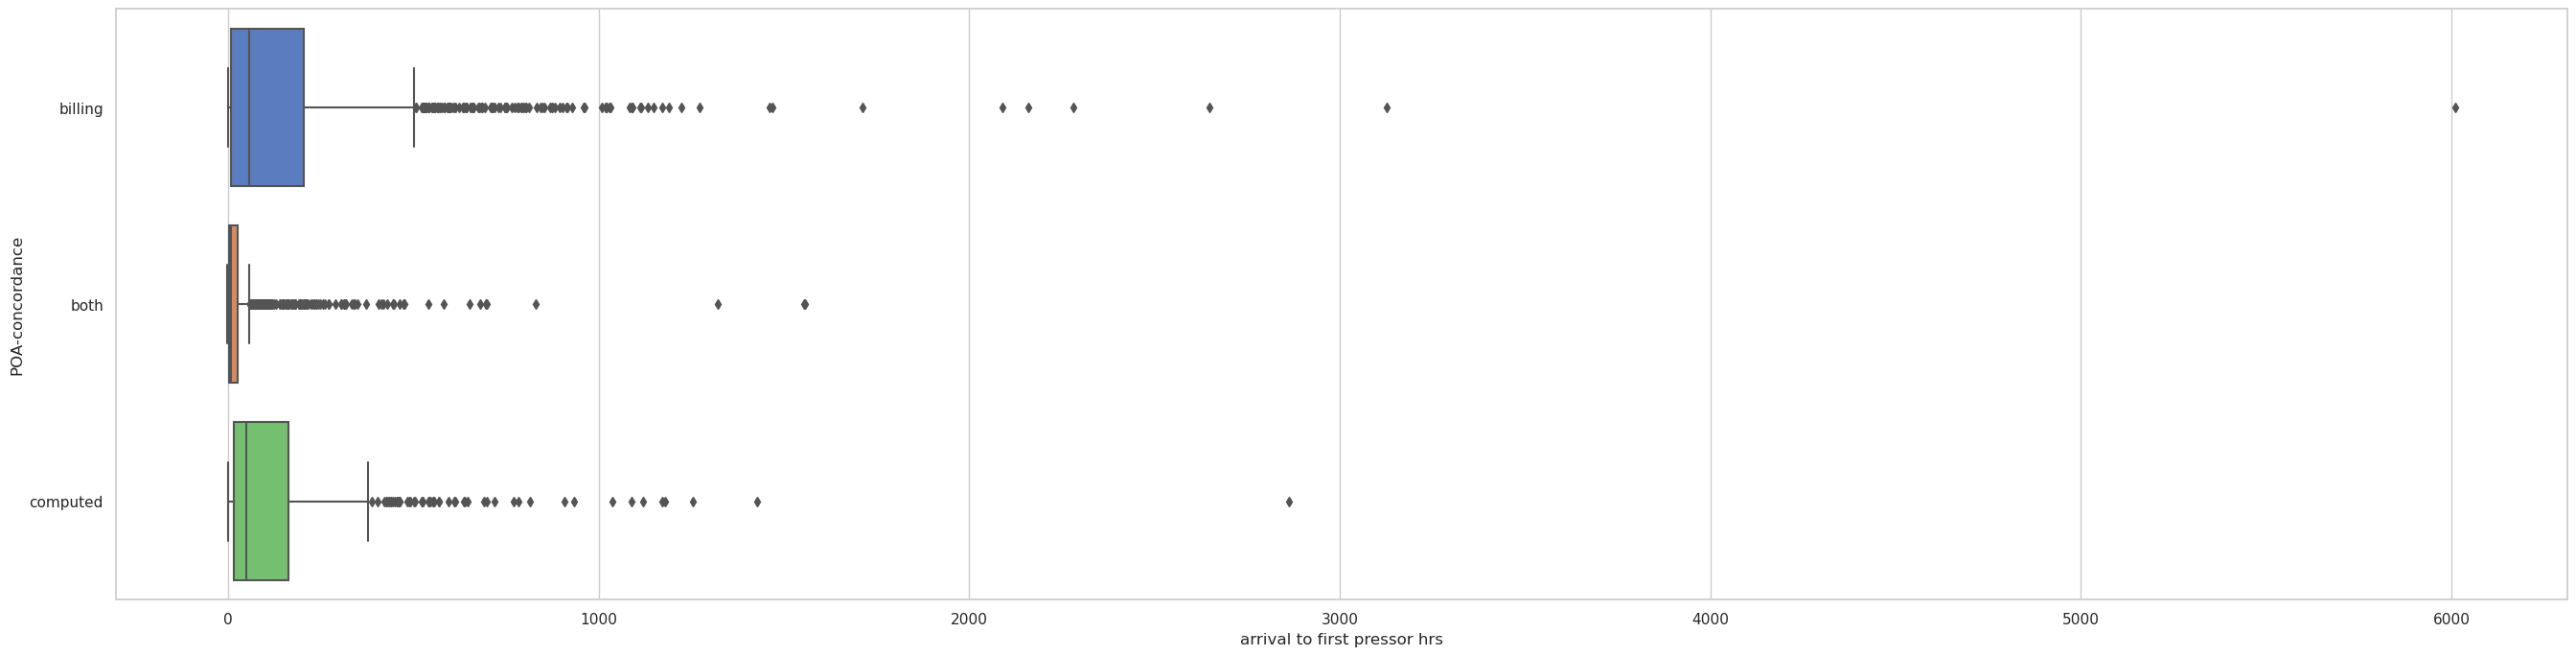

In [49]:
fig, ax = plt.subplots(figsize=(33,8))
sns.boxplot(data=df_po3_npoa3_pressors_first_time.to_pandas(), y="POA-concordance", x="arrival to first pressor hrs")

Text(1700, 2, '689.00')

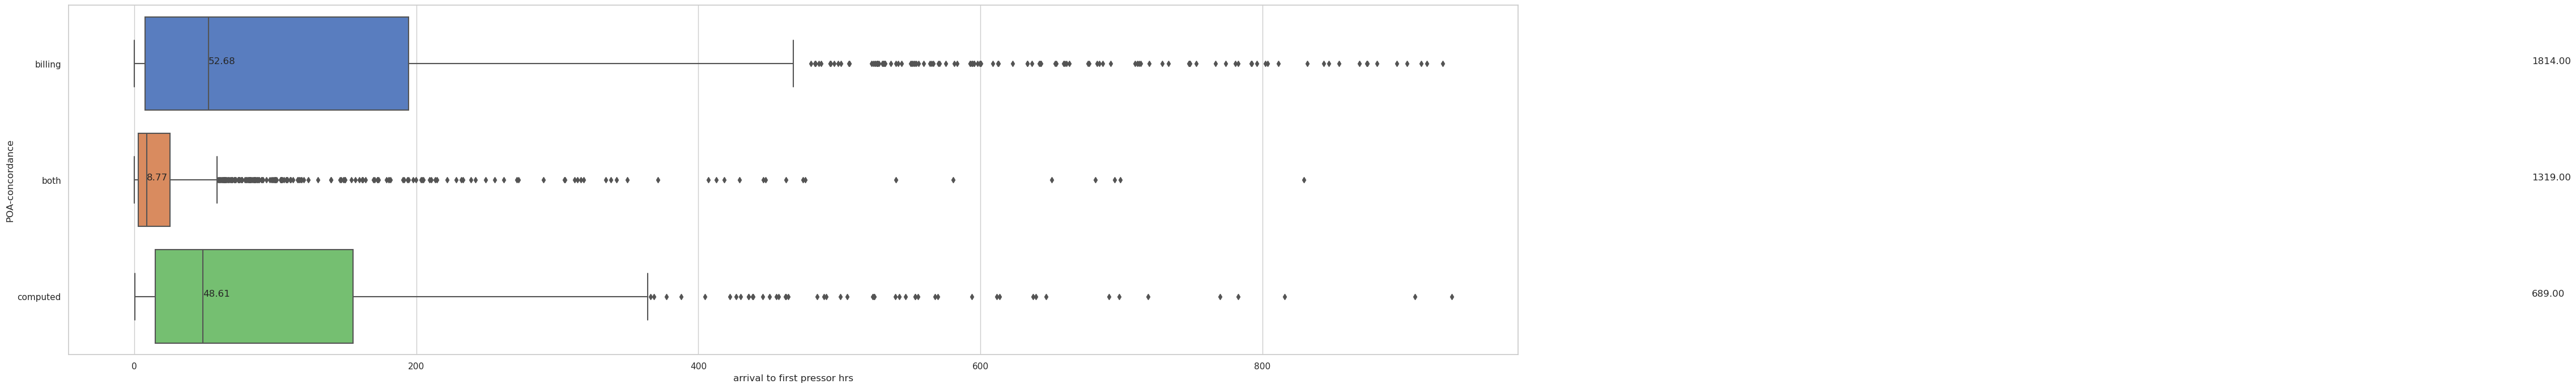

In [50]:
arrival2firstpressor = "arrival to first pressor hrs"

df_po3_npoa3_pressors_first_time_nooutlier = df_po3_npoa3_pressors_first_time.filter(
    (pl.col(arrival2firstpressor)<pl.col(arrival2firstpressor).quantile(0.99))&
    (pl.col(arrival2firstpressor)>pl.col(arrival2firstpressor).quantile(0.01))
)
d = df_po3_npoa3_pressors_first_time_nooutlier.group_by("POA-concordance").agg(
	pl.col(arrival2firstpressor).median().alias("median hours to first pressor"),
	pl.col(arrival2firstpressor).quantile(0.25).alias("0.25 hours to first pressor"),
	pl.col(arrival2firstpressor).quantile(0.75).alias("0.75 hours to first pressor"),
)
N_computed = len(df_po3_npoa3_pressors_first_time.filter(pl.col("POA-concordance")=='computed'))
N_billing = len(df_po3_npoa3_pressors_first_time.filter(pl.col("POA-concordance")=='billing'))
N_both = len(df_po3_npoa3_pressors_first_time.filter(pl.col("POA-concordance")=='both'))

median_billing = d.filter(pl.col("POA-concordance")=="billing")["median hours to first pressor"][0]
median_computed = d.filter(pl.col("POA-concordance")=="computed")["median hours to first pressor"][0]
median_both = d.filter(pl.col("POA-concordance")=="both")["median hours to first pressor"][0]

fig, ax = plt.subplots(figsize=(33,8))
sns.boxplot(data=df_po3_npoa3_pressors_first_time_nooutlier.to_pandas(), y="POA-concordance", x=arrival2firstpressor, ax=ax)

ax.text(median_billing, 0, f'{median_billing:.2f}')
ax.text(median_both, 1, f'{median_both:.2f}')
ax.text(median_computed, 2, f'{median_computed:.2f}')

ax.text(1700, 0, f'{N_billing:.2f}')
ax.text(1700, 1, f'{N_both:.2f}')
ax.text(1700, 2, f'{N_computed:.2f}')

In [51]:
df_po3_npoa3_pressors_first_time.filter(

)

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,arrival to first pressor hrs,admit to first pressor hrs,POA-concordance
i64,str,str,f64,f64,str
687038913,"""POA-3""","""POA-2""",1.640556,-3.626111,"""billing"""
662909282,"""POA-3""","""POA-3""",2.95,0.216667,"""both"""
683949086,"""POA-3""","""POA-2""",235.866667,221.383333,"""billing"""
663105640,"""POA-3""",null,18.724722,18.724722,"""billing"""
683564400,"""POA-3""","""POA-3""",28.053056,8.486389,"""both"""
…,…,…,…,…,…
716802228,"""NPOA-3""","""NPOA-3""",564.333333,551.533333,"""billing"""
717856271,"""NPOA-3""","""POA-3""",108.089722,108.089722,"""computed"""
718657170,"""POA-3""","""POA-2""",3.083611,-0.999722,"""billing"""


In [52]:
df_po3_npoa3_pressors_first_time.filter(
    (pl.col("Sepsis_Category")=="POA-3")&(pl.col("Computed_Sepsis_Category")=="NPOA-3")
).sort(by='hours to first pressor')

ColumnNotFoundError: unable to find column "hours to first pressor"; valid columns: ["EncounterEpicCsn", "Sepsis_Category", "Computed_Sepsis_Category", "arrival to first pressor hrs", "admit to first pressor hrs", "POA-concordance"]

In [ ]:
df_po3_npoa3_pressors_first_time.filter(
    pl.col("POA-concordance")=="billing"
)['Computed_Sepsis_Category'].value_counts(normalize=True, sort=True),df_po3_npoa3_pressors_first_time.filter(
    pl.col("POA-concordance")=="billing"
)['Computed_Sepsis_Category'].value_counts(sort=True)

(shape: (6, 2)
 ┌──────────────────────────┬────────────┐
 │ Computed_Sepsis_Category ┆ proportion │
 │ ---                      ┆ ---        │
 │ str                      ┆ f64        │
 ╞══════════════════════════╪════════════╡
 │ POA-2                    ┆ 0.712631   │
 │ NPOA-3                   ┆ 0.134032   │
 │ POA-1                    ┆ 0.07722    │
 │ NPOA-2                   ┆ 0.062328   │
 │ NPOA-1                   ┆ 0.007722   │
 │ null                     ┆ 0.006067   │
 └──────────────────────────┴────────────┘,
 shape: (6, 2)
 ┌──────────────────────────┬───────┐
 │ Computed_Sepsis_Category ┆ count │
 │ ---                      ┆ ---   │
 │ str                      ┆ u64   │
 ╞══════════════════════════╪═══════╡
 │ POA-2                    ┆ 1292  │
 │ NPOA-3                   ┆ 243   │
 │ POA-1                    ┆ 140   │
 │ NPOA-2                   ┆ 113   │
 │ NPOA-1                   ┆ 14    │
 │ null                     ┆ 11    │
 └──────────────────────────┴──────

In [77]:
df_po3_npoa3_pressors_first_time=df_po3_npoa3_pressors_first_time.with_columns(
    pl.when(
        (pl.col("Computed_Sepsis_Category") == "NPOA-3")&(pl.col("Sepsis_Category") == "NPOA-3")
	).then(pl.lit("both")).when(pl.col("Sepsis_Category")=="NPOA-3").then(pl.lit("billing")).otherwise(pl.lit("computed")).alias("NPOA-concordance")
)

ValueError: Could not interpret input 'hours to first pressor'

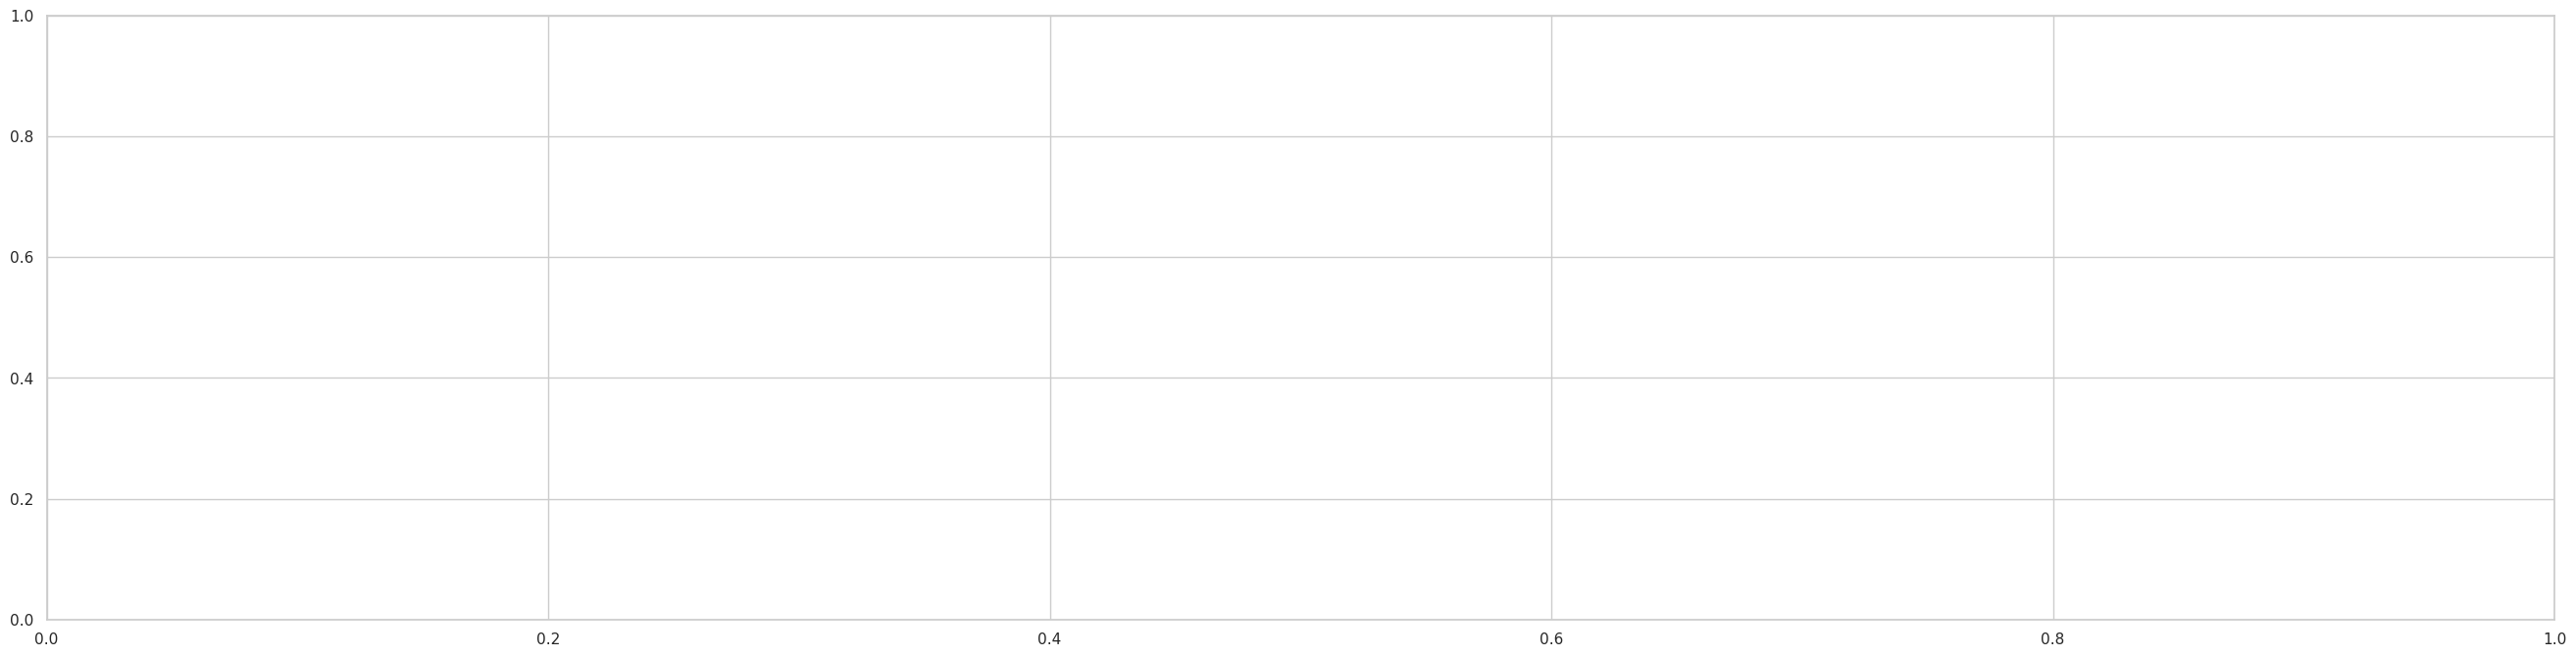

In [56]:
fig, ax = plt.subplots(figsize=(33,8))
sns.boxplot(data=df_po3_npoa3_pressors_first_time.to_pandas(), y="NPOA-concordance", x="hours to first pressor")

In [78]:
df_po3_npoa3_pressors_first_time

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,arrival to first pressor hrs,admit to first pressor hrs,POA-concordance,NPOA-concordance
i64,str,str,f64,f64,str,str
687038913,"""POA-3""","""POA-2""",1.640556,-3.626111,"""billing""","""computed"""
662909282,"""POA-3""","""POA-3""",2.95,0.216667,"""both""","""computed"""
683949086,"""POA-3""","""POA-2""",235.866667,221.383333,"""billing""","""computed"""
663105640,"""POA-3""",null,18.724722,18.724722,"""billing""","""computed"""
683564400,"""POA-3""","""POA-3""",28.053056,8.486389,"""both""","""computed"""
…,…,…,…,…,…,…
716802228,"""NPOA-3""","""NPOA-3""",564.333333,551.533333,"""billing""","""both"""
717856271,"""NPOA-3""","""POA-3""",108.089722,108.089722,"""computed""","""billing"""
718657170,"""POA-3""","""POA-2""",3.083611,-0.999722,"""billing""","""computed"""


Text(1700, 2, '2800.00')

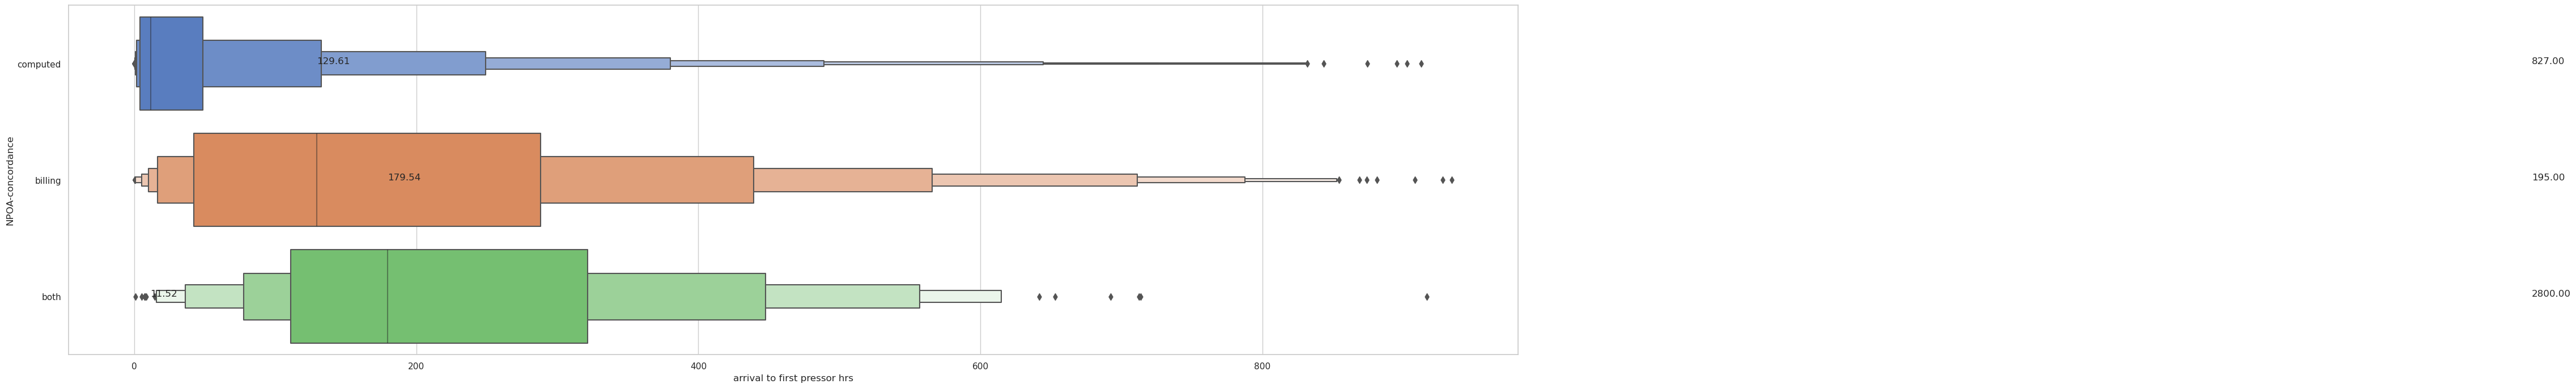

In [79]:
arrival2firstpressor = "arrival to first pressor hrs"

df_po3_npoa3_pressors_first_time_nooutlier = df_po3_npoa3_pressors_first_time.filter(
    (pl.col(arrival2firstpressor)<pl.col(arrival2firstpressor).quantile(0.99))&
    (pl.col(arrival2firstpressor)>pl.col(arrival2firstpressor).quantile(0.01))
)
d = df_po3_npoa3_pressors_first_time_nooutlier.group_by("NPOA-concordance").agg(
	pl.col(arrival2firstpressor).median().alias("median hours to first pressor"),
	pl.col(arrival2firstpressor).quantile(0.25).alias("0.25 hours to first pressor"),
	pl.col(arrival2firstpressor).quantile(0.75).alias("0.75 hours to first pressor"),
)

N_computed = len(df_po3_npoa3_pressors_first_time.filter(pl.col("NPOA-concordance")=='computed'))
N_billing = len(df_po3_npoa3_pressors_first_time.filter(pl.col("NPOA-concordance")=='billing'))
N_both = len(df_po3_npoa3_pressors_first_time.filter(pl.col("NPOA-concordance")=='both'))

median_billing = d.filter(pl.col("NPOA-concordance")=="billing")["median hours to first pressor"][0]
median_computed = d.filter(pl.col("NPOA-concordance")=="computed")["median hours to first pressor"][0]
median_both = d.filter(pl.col("NPOA-concordance")=="both")["median hours to first pressor"][0]

fig, ax = plt.subplots(figsize=(33,8))
sns.boxenplot(data=df_po3_npoa3_pressors_first_time_nooutlier.to_pandas(), y="NPOA-concordance", x=arrival2firstpressor, ax=ax)
ax.text(median_billing, 0, f'{median_billing:.2f}')
ax.text(median_both, 1, f'{median_both:.2f}')
ax.text(median_computed, 2, f'{median_computed:.2f}')

ax.text(1700, 0, f'{N_billing:.2f}')
ax.text(1700, 1, f'{N_both:.2f}')
ax.text(1700, 2, f'{N_computed:.2f}')

In [ ]:
df_po3_npoa3_pressors_first_time_nooutlier.filter(pl.col("NPOA-concordance") == "billing")

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,arrival to first pressor hrs,admit to first pressor hrs,POA-concordance,NPOA-concordance
i64,str,str,f64,f64,str,str
687038913,"""POA-3""","""POA-2""",1.640556,-3.626111,"""billing""","""billing"""
662909282,"""POA-3""","""POA-3""",2.95,0.216667,"""both""","""billing"""
683949086,"""POA-3""","""POA-2""",235.866667,221.383333,"""billing""","""billing"""
663105640,"""POA-3""",null,18.724722,18.724722,"""billing""","""billing"""
683564400,"""POA-3""","""POA-3""",28.053056,8.486389,"""both""","""billing"""
…,…,…,…,…,…,…
741989382,"""NPOA-3""","""POA-2""",212.440833,192.6575,"""billing""","""billing"""
717856271,"""NPOA-3""","""POA-3""",108.089722,108.089722,"""computed""","""billing"""
718657170,"""POA-3""","""POA-2""",3.083611,-0.999722,"""billing""","""billing"""


In [86]:
df_npoa3_encounters_with_pressors_before_48hrs_of_arrival = df_po3_npoa3_pressors_first_time.filter(
    (pl.col("Sepsis_Category") == "NPOA-3")&
	(pl.col("arrival to first pressor hrs")<48)
).with_columns(
    pl.col("Sepsis_Category").str.extract(r"^(.)", 1).alias("billing_POAvNPOA"),
    pl.col("Computed_Sepsis_Category").str.extract(r"^(.)", 1).alias("computed_POAvNPOA"),
)

In [93]:
df_npoa3_encounters_with_pressors_before_24hrs_of_admission = df_po3_npoa3_pressors_first_time.filter(
    (pl.col("Sepsis_Category") == "NPOA-3")&
	(pl.col("admit to first pressor hrs")<24)
).with_columns(
    pl.col("Sepsis_Category").str.extract(r"^(.)", 1).alias("billing_POAvNPOA"),
    pl.col("Computed_Sepsis_Category").str.extract(r"^(.)", 1).alias("computed_POAvNPOA"),
)
df_npoa3_encounters_with_pressors_before_24hrs_of_admission

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,arrival to first pressor hrs,admit to first pressor hrs,POA-concordance,NPOA-concordance,billing_POAvNPOA,computed_POAvNPOA
i64,str,str,f64,f64,str,str,str,str
740396440,"""NPOA-3""","""POA-3""",15.514444,5.331111,"""computed""","""billing""","""N""","""P"""
720173512,"""NPOA-3""","""POA-3""",21.024722,21.024722,"""computed""","""billing""","""N""","""P"""
674118653,"""NPOA-3""","""POA-3""",11.95,11.95,"""computed""","""billing""","""N""","""P"""
675257964,"""NPOA-3""","""NPOA-3""",7.086667,7.086667,"""billing""","""both""","""N""","""N"""
740264865,"""NPOA-3""","""POA-3""",17.25,17.25,"""computed""","""billing""","""N""","""P"""
…,…,…,…,…,…,…,…,…
727441497,"""NPOA-3""","""POA-3""",23.158056,23.158056,"""computed""","""billing""","""N""","""P"""
700636627,"""NPOA-3""","""POA-3""",19.621111,19.354444,"""computed""","""billing""","""N""","""P"""
694058277,"""NPOA-3""","""POA-3""",9.154444,8.904444,"""computed""","""billing""","""N""","""P"""


In [94]:
df_npoa3_encounters_with_pressors_before_24hrs_of_admission['billing_POAvNPOA'].value_counts()

billing_POAvNPOA,count
str,u64
"""N""",163


In [95]:
df_npoa3_encounters_with_pressors_before_24hrs_of_admission['computed_POAvNPOA'].value_counts()

computed_POAvNPOA,count
str,u64
"""N""",15
"""P""",147
null,1


In [89]:
df_npoa3_encounters_with_pressors_before_48hrs_of_arrival['billing_POAvNPOA'].value_counts()

billing_POAvNPOA,count
str,u64
"""N""",238


In [90]:
df_npoa3_encounters_with_pressors_before_48hrs_of_arrival['computed_POAvNPOA'].value_counts()

computed_POAvNPOA,count
str,u64
"""N""",22
null,1
"""P""",215


<Axes: xlabel='arrival to first pressor hrs'>

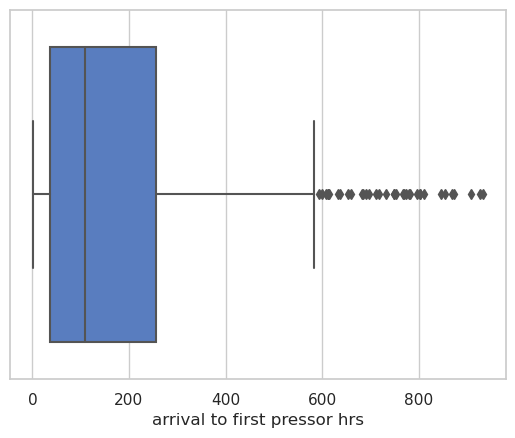

In [73]:
sns.boxplot(data=df_po3_npoa3_pressors_first_time_nooutlier.filter(
    (pl.col("Sepsis_Category") == 'NPOA-3')&(~pl.col("Computed_Sepsis_Category").str.starts_with('N'))
).to_pandas(), x='arrival to first pressor hrs')

In [60]:
df_po3_npoa3_pressors_first_time_nooutlier.group_by("NPOA-concordance").agg(
	pl.col(arrival2firstpressor).median().alias("median hours to first pressor"),
	pl.col(arrival2firstpressor).quantile(0.25).alias("0.25 hours to first pressor"),
	pl.col(arrival2firstpressor).quantile(0.75).alias("0.75 hours to first pressor"),
	pl.len().alias("N")
)

NPOA-concordance,median hours to first pressor,0.25 hours to first pressor,0.75 hours to first pressor,N
str,f64,f64,f64,u64
"""both""",179.542222,110.9,321.765556,191
"""computed""",140.049583,93.859444,259.666667,48
"""billing""",18.118333,5.3775,97.116667,3505


### Descriptive analysis

In [39]:
def summarize_continuous(df: pl.DataFrame, var: str, group: str = "Sepsis_Category") -> pl.DataFrame:
    return (
        df.group_by(group)
          .agg(
              pl.col(var).count().alias("n"),           # non-null count
              pl.col(var).null_count().alias("missing"),# nulls, reported explicitly
              pl.col(var).median().alias("median"),
              pl.col(var).quantile(0.25, interpolation="linear").alias("q1"),
              pl.col(var).quantile(0.75, interpolation="linear").alias("q3"),
          )
          .with_columns(
              pl.format(
                  "{} [{}, {}]",
                  pl.col("median").round(1),
                  pl.col("q1").round(1),
                  pl.col("q3").round(1),
              ).alias("cell")     # the formatted "median [Q1, Q3]" string for the table
          )
          .sort(group)
    )

def summarize_categorical(df, var, group, norm="column"):
    missing = df.group_by(group).agg(pl.col(var).null_count().alias("missing"))
    partition = group if norm == "column" else var          # ← the only change
    counts = (
        df.drop_nulls(subset=[var])
          .group_by([group, var])
          .agg(pl.len().alias("count"))
          .with_columns(pl.col("count").sum().over(partition).alias("denom"))
          .with_columns((pl.col("count")/pl.col("denom")*100).alias("pct"))
          .with_columns(pl.format("{} ({}%)", pl.col("count"), pl.col("pct").round(1)).alias("cell"))
          .sort([group, var])
    )
    return counts, missing


GROUP = "Sepsis_Category"
def rows_continuous(summary: pl.DataFrame, label: str, group:str) -> pl.DataFrame:
    # summary has one row per stratum already; just relabel and keep the cell.
    return summary.select(
        pl.lit(label).alias("label"),
        pl.col(group).alias("stratum"),
        pl.col("cell"),
    )

def rows_categorical(counts, var, label_prefix, group, only_level=None):
    out = counts
    if only_level is not None:
        out = out.filter(pl.col(var) == only_level).with_columns(pl.lit(label_prefix).alias("label"))
    else:
        out = out.with_columns(pl.format("{}: {}", pl.lit(label_prefix), pl.col(var)).alias("label"))
    return out.select("label", pl.col(group).alias("stratum"), "cell")

def positive_level(df, var):
    vals = df.get_column(var).drop_nulls().unique().to_list()
    for cand in [1, "1", "Y", "Yes", "YES", "True", "TRUE", True]:
        if cand in vals:
            print(f"{var}: positive level = {cand!r}  (levels seen: {vals})")
            return cand
    raise ValueError(f"No affirmative token found in {var}: {vals}")

def collapse_top_n(df: pl.DataFrame, var: str, n: int = 10,
                   other_label: str = "Other") -> pl.DataFrame:
    top = (
        df.drop_nulls(subset=[var])                       # nulls aren't a "top" category
          .group_by(var).agg(pl.len().alias("c"))
          .sort("c", descending=True)
          .head(n)
          .get_column(var).to_list()
    )
    return df.with_columns(
        pl.when(pl.col(var).is_null()).then(pl.lit(None, dtype=pl.Utf8))  # keep nulls null
          .when(pl.col(var).is_in(top)).then(pl.col(var))                 # keep top-N as-is
          .otherwise(pl.lit(other_label))                                 # everything else → Other
          .alias(var)
    )

def build_long(df, group, norm="column"):
    age = summarize_continuous(df, "PatientAgeAtAdmission", group)
    los = summarize_continuous(df, "los_source", group)

    df_hs  = collapse_top_n(df, "HospitalService", 10)
    df_src = collapse_top_n(df, "AdmissionSource", 10)
    df_dep = collapse_top_n(df, "AdmittingDepartment", 10)

    sex,_  = summarize_categorical(df, "Sex", group, norm)
    race,_ = summarize_categorical(df, "FirstRace", group, norm)
    hs,_   = summarize_categorical(df_hs,  "HospitalService", group, norm)
    asrc,_ = summarize_categorical(df_src, "AdmissionSource", group, norm)
    dep,_  = summarize_categorical(df_dep, "AdmittingDepartment", group, norm)

    flags = [("Death_Flag","In-hospital mortality"), ("Cancer_Registry_YN","Cancer"),
             ("HIV_Registry_YN","HIV"), ("Immunocrompromised_Registry_YN","Immunocompromised"),
             ("CKD_Dialysis_Registry_YN","CKD / dialysis"),
             ("Solid_Organ_Transplant_Registry_YN","Solid organ transplant"),
             ("Pregnancy_Registry_YN","Pregnancy")]
    flag_rows = []
    for col, lbl in flags:
        cnt,_ = summarize_categorical(df, col, group, norm)
        flag_rows.append(rows_categorical(cnt, col, lbl, group, only_level=positive_level(df, col)))

    parts = [
        rows_continuous(age, "Age, years — median [IQR]", group),
        rows_categorical(sex, "Sex", "Sex", group),
        rows_continuous(los, "Length of stay, days — median [IQR]", group),
        rows_categorical(race, "FirstRace", "Race", group),
        rows_categorical(hs,  "HospitalService", "Hospital service", group),
        rows_categorical(asrc,"AdmissionSource", "Admission source", group),
        rows_categorical(dep, "AdmittingDepartment", "Admitting dept", group),
        *flag_rows,
    ]
    long = pl.concat(parts)
    order = long.select("label").unique(maintain_order=True).with_row_index("ord")
    return long.join(order, on="label")

def overlay_wide(wide_new, wide_old, strata):
    new_idx = wide_new.with_row_index("_o")               # preserve row order across the join
    j = new_idx.join(wide_old, on="label", suffix="_old")
    return (j.sort("_o").drop("_o")
             .select("label",
                     *[pl.format("{} (was {})", pl.col(s), pl.col(f"{s}_old")).alias(s)
                       for s in strata]))

def n_header(df, group, strata):
    return (df.group_by(group).agg(pl.len().alias("c"))
              .with_columns(pl.lit("N (encounters)").alias("label"),
                            pl.col("c").cast(pl.Utf8).alias("cell"))
              .pivot(values="cell", index="label", on=group)
              .select(["label", *strata]))

def to_wide(long, df, group, strata):
    body = (long.pivot(values="cell", index=["ord","label"], on="stratum")
                .sort("ord").drop("ord")
                .select(["label", *strata])
                .with_columns(pl.col(strata).fill_null("0 (0.0%)")))
    return pl.concat([n_header(df, group, strata), body])

# age_summary = summarize_continuous(df_enc_3_noupoa, "PatientAgeAtAdmission")
# los_summary = summarize_continuous(df_enc_3_noupoa, "los_source")
# sex_counts, sex_missing = summarize_categorical(df_enc_3_noupoa, "Sex")
# deathflag_counts, deathflag_missing = summarize_categorical(df_enc_3_noupoa, "Death_Flag")
# firstrace_counts, firstrace_missing = summarize_categorical(df_enc_3_noupoa, "FirstRace")
# hospitalservice_count, hospitalservice_missing = summarize_categorical(df_enc_3_noupoa, "HospitalService")
# admitsource_count, admitsource_missing = summarize_categorical(df_enc_3_noupoa, "AdmissionSource")
# admitdep_count, admitdep_missing = summarize_categorical(df_enc_3_noupoa, "AdmittingDepartment")
# principleprob_count, principleprob_missing = summarize_categorical(df_enc_3_noupoa, "PrincipalProblem")
# PrimaryCodedDiagnosis_count, PrimaryCodedDiagnosis_missing = summarize_categorical(df_enc_3_noupoa, "PrimaryCodedDiagnosis")


In [70]:
STRATA = ["NPOA-1","NPOA-2","NPOA-3","POA-1","POA-2","POA-3",]

df = df_enc_3_noupoa
# → SLIDE 1 (Introduction): cohort described under the SOURCE label.
#   "Here is the current state of the data / existing Sepsis_Category."
long_src    = build_long(df_enc_3_noupoa, "Sepsis_Category", norm="column")
table_intro = to_wide(long_src, df_enc_3_noupoa, "Sepsis_Category", STRATA)

# → SLIDE N (end): same panel under YOUR algorithm, with source shown as "(was …)".
#   "Here is how demographics, LOS, and mortality shifted within each stratum
#    once detection switched to the algorithm."
long_cmp       = build_long(df_sepsis_v2_max_first, "Computed_Sepsis_Category", norm="column")
table_computed = to_wide(long_cmp, df_sepsis_v2_max_first, "Computed_Sepsis_Category", STRATA)
table_before_after = overlay_wide(table_computed, table_intro, STRATA)

# → BACKUP slide (optional): row-normalized before→after, for the susceptibility
#   questions ("are females / a subgroup more likely to land in POA-3 under one scheme").
#   Continuous rows are unchanged here; only categorical cells flip to row-%.
ba_row = overlay_wide(
    to_wide(build_long(df_sepsis_v2_max_first,"Computed_Sepsis_Category",norm="row"), df_sepsis_v2_max_first,"Computed_Sepsis_Category",STRATA),
    to_wide(build_long(df_sepsis_v2_max_first,"Sepsis_Category",norm="row"),          df_sepsis_v2_max_first,"Sepsis_Category",STRATA),
    STRATA)

NameError: name 'build_long' is not defined

In [101]:
table_intro.to_pandas()

,label,POA-1,POA-2,POA-3,NPOA-1,NPOA-2,NPOA-3
0,N (encounters),6863,2593,2971,875,204,1100
1,"Age, years — median [IQR]","61.0 [44.5, 72.0]","66.3 [52.1, 75.0]","66.1 [54.0, 74.8]","64.4 [50.1, 73.4]","66.3 [53.9, 74.1]","66.4 [54.7, 74.2]"
2,Sex: Female,3334 (48.6%),1178 (45.4%),1333 (44.9%),408 (46.6%),97 (47.5%),479 (43.5%)
3,Sex: Male,3529 (51.4%),1415 (54.6%),1638 (55.1%),467 (53.4%),107 (52.5%),621 (56.5%)
4,"Length of stay, days — median [IQR]","6.0 [4.0, 10.0]","7.0 [4.0, 12.0]","11.0 [6.0, 20.0]","18.0 [11.0, 31.0]","18.0 [11.0, 30.0]","25.0 [14.0, 40.0]"
5,Race: American Indian or Alaska Native,29 (0.4%),5 (0.2%),17 (0.6%),5 (0.6%),1 (0.5%),5 (0.5%)
6,Race: Asian,155 (2.3%),54 (2.1%),92 (3.1%),24 (2.7%),5 (2.5%),38 (3.5%)
7,Race: Black or African American,1626 (23.7%),626 (24.1%),605 (20.4%),217 (24.8%),62 (30.4%),237 (21.5%)
8,Race: Declined,21 (0.3%),15 (0.6%),12 (0.4%),3 (0.3%),1 (0.5%),4 (0.4%)
9,"Race: East Asian (China, North/South Korea, Ja...",55 (0.8%),20 (0.8%),11 (0.4%),8 (0.9%),2 (1.0%),6 (0.5%)


In [103]:
table_computed.to_pandas()

,label,POA-1,POA-2,POA-3,NPOA-1,NPOA-2,NPOA-3
0,N (encounters),3740,7678,1998,149,494,243
1,"Age, years — median [IQR]","58.6 [42.1, 70.3]","65.3 [50.7, 74.7]","65.1 [53.5, 73.6]","62.7 [48.2, 69.7]","67.2 [53.4, 74.6]","67.3 [55.4, 76.1]"
2,Sex: Female,1903 (50.9%),3475 (45.3%),886 (44.3%),74 (49.7%),235 (47.6%),80 (32.9%)
3,Sex: Male,1837 (49.1%),4203 (54.7%),1112 (55.7%),75 (50.3%),259 (52.4%),163 (67.1%)
4,"Length of stay, days — median [IQR]","5.0 [3.0, 9.0]","8.0 [5.0, 15.0]","15.0 [8.0, 28.0]","20.0 [11.0, 28.0]","20.5 [13.0, 32.0]","28.0 [18.0, 45.0]"
5,Race: American Indian or Alaska Native,20 (0.5%),25 (0.3%),13 (0.7%),0 (0.0%),1 (0.2%),1 (0.4%)
6,Race: Asian,81 (2.2%),208 (2.7%),59 (3.0%),3 (2.0%),8 (1.6%),6 (2.5%)
7,Race: Black or African American,885 (23.7%),1754 (22.8%),435 (21.8%),35 (23.5%),137 (27.7%),50 (20.6%)
8,Race: Declined,14 (0.4%),29 (0.4%),8 (0.4%),0 (0.0%),1 (0.2%),2 (0.8%)
9,"Race: East Asian (China, North/South Korea, Ja...",38 (1.0%),50 (0.7%),9 (0.5%),1 (0.7%),3 (0.6%),0 (0.0%)


In [104]:
table_before_after.to_pandas()

,label,POA-1,POA-2,POA-3,NPOA-1,NPOA-2,NPOA-3
0,N (encounters),3740 (was 6863),7678 (was 2593),1998 (was 2971),149 (was 875),494 (was 204),243 (was 1100)
1,"Age, years — median [IQR]","58.6 [42.1, 70.3] (was 61.0 [44.5, 72.0])","65.3 [50.7, 74.7] (was 66.3 [52.1, 75.0])","65.1 [53.5, 73.6] (was 66.1 [54.0, 74.8])","62.7 [48.2, 69.7] (was 64.4 [50.1, 73.4])","67.2 [53.4, 74.6] (was 66.3 [53.9, 74.1])","67.3 [55.4, 76.1] (was 66.4 [54.7, 74.2])"
2,Sex: Female,1903 (50.9%) (was 3334 (48.6%)),3475 (45.3%) (was 1178 (45.4%)),886 (44.3%) (was 1333 (44.9%)),74 (49.7%) (was 408 (46.6%)),235 (47.6%) (was 97 (47.5%)),80 (32.9%) (was 479 (43.5%))
3,Sex: Male,1837 (49.1%) (was 3529 (51.4%)),4203 (54.7%) (was 1415 (54.6%)),1112 (55.7%) (was 1638 (55.1%)),75 (50.3%) (was 467 (53.4%)),259 (52.4%) (was 107 (52.5%)),163 (67.1%) (was 621 (56.5%))
4,"Length of stay, days — median [IQR]","5.0 [3.0, 9.0] (was 6.0 [4.0, 10.0])","8.0 [5.0, 15.0] (was 7.0 [4.0, 12.0])","15.0 [8.0, 28.0] (was 11.0 [6.0, 20.0])","20.0 [11.0, 28.0] (was 18.0 [11.0, 31.0])","20.5 [13.0, 32.0] (was 18.0 [11.0, 30.0])","28.0 [18.0, 45.0] (was 25.0 [14.0, 40.0])"
5,Race: American Indian or Alaska Native,20 (0.5%) (was 29 (0.4%)),25 (0.3%) (was 5 (0.2%)),13 (0.7%) (was 17 (0.6%)),0 (0.0%) (was 5 (0.6%)),1 (0.2%) (was 1 (0.5%)),1 (0.4%) (was 5 (0.5%))
6,Race: Asian,81 (2.2%) (was 155 (2.3%)),208 (2.7%) (was 54 (2.1%)),59 (3.0%) (was 92 (3.1%)),3 (2.0%) (was 24 (2.7%)),8 (1.6%) (was 5 (2.5%)),6 (2.5%) (was 38 (3.5%))
7,Race: Black or African American,885 (23.7%) (was 1626 (23.7%)),1754 (22.8%) (was 626 (24.1%)),435 (21.8%) (was 605 (20.4%)),35 (23.5%) (was 217 (24.8%)),137 (27.7%) (was 62 (30.4%)),50 (20.6%) (was 237 (21.5%))
8,Race: Declined,14 (0.4%) (was 21 (0.3%)),29 (0.4%) (was 15 (0.6%)),8 (0.4%) (was 12 (0.4%)),0 (0.0%) (was 3 (0.3%)),1 (0.2%) (was 1 (0.5%)),2 (0.8%) (was 4 (0.4%))
9,"Race: East Asian (China, North/South Korea, Ja...",38 (1.0%) (was 55 (0.8%)),50 (0.7%) (was 20 (0.8%)),9 (0.5%) (was 11 (0.4%)),1 (0.7%) (was 8 (0.9%)),3 (0.6%) (was 2 (1.0%)),0 (0.0%) (was 6 (0.5%))


In [105]:
ba_row.to_pandas()

,label,POA-1,POA-2,POA-3,NPOA-1,NPOA-2,NPOA-3
0,N (encounters),3740 (was 6863),7678 (was 2593),1998 (was 2971),149 (was 875),494 (was 204),243 (was 1100)
1,"Age, years — median [IQR]","58.6 [42.1, 70.3] (was 61.0 [44.5, 72.0])","65.3 [50.7, 74.7] (was 66.3 [52.1, 75.0])","65.1 [53.5, 73.6] (was 66.1 [54.0, 74.8])","62.7 [48.2, 69.7] (was 64.4 [50.1, 73.4])","67.2 [53.4, 74.6] (was 66.3 [53.9, 74.1])","67.3 [55.4, 76.1] (was 66.4 [54.7, 74.2])"
2,Sex: Female,1903 (27.9%) (was 3334 (48.8%)),3475 (50.9%) (was 1178 (17.2%)),886 (13.0%) (was 1333 (19.5%)),74 (1.1%) (was 408 (6.0%)),235 (3.4%) (was 97 (1.4%)),80 (1.2%) (was 479 (7.0%))
3,Sex: Male,1837 (23.6%) (was 3529 (45.4%)),4203 (54.0%) (was 1415 (18.2%)),1112 (14.3%) (was 1638 (21.1%)),75 (1.0%) (was 467 (6.0%)),259 (3.3%) (was 107 (1.4%)),163 (2.1%) (was 621 (8.0%))
4,"Length of stay, days — median [IQR]","5.0 [3.0, 9.0] (was 6.0 [4.0, 10.0])","8.0 [5.0, 15.0] (was 7.0 [4.0, 12.0])","15.0 [8.0, 28.0] (was 11.0 [6.0, 20.0])","20.0 [11.0, 28.0] (was 18.0 [11.0, 31.0])","20.5 [13.0, 32.0] (was 18.0 [11.0, 30.0])","28.0 [18.0, 45.0] (was 25.0 [14.0, 40.0])"
5,Race: American Indian or Alaska Native,20 (32.3%) (was 29 (46.8%)),25 (40.3%) (was 5 (8.1%)),13 (21.0%) (was 17 (27.4%)),0 (0.0%) (was 5 (8.1%)),1 (1.6%) (was 1 (1.6%)),1 (1.6%) (was 5 (8.1%))
6,Race: Asian,81 (22.0%) (was 155 (42.1%)),208 (56.5%) (was 54 (14.7%)),59 (16.0%) (was 92 (25.0%)),3 (0.8%) (was 24 (6.5%)),8 (2.2%) (was 5 (1.4%)),6 (1.6%) (was 38 (10.3%))
7,Race: Black or African American,885 (26.2%) (was 1626 (48.2%)),1754 (52.0%) (was 626 (18.6%)),435 (12.9%) (was 605 (17.9%)),35 (1.0%) (was 217 (6.4%)),137 (4.1%) (was 62 (1.8%)),50 (1.5%) (was 237 (7.0%))
8,Race: Declined,14 (25.0%) (was 21 (37.5%)),29 (51.8%) (was 15 (26.8%)),8 (14.3%) (was 12 (21.4%)),0 (0.0%) (was 3 (5.4%)),1 (1.8%) (was 1 (1.8%)),2 (3.6%) (was 4 (7.1%))
9,"Race: East Asian (China, North/South Korea, Ja...",38 (37.3%) (was 55 (53.9%)),50 (49.0%) (was 20 (19.6%)),9 (8.8%) (was 11 (10.8%)),1 (1.0%) (was 8 (7.8%)),3 (2.9%) (was 2 (2.0%)),0 (0.0%) (was 6 (5.9%))


In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Source-comparison palette — two tones from your blue family (NOT stratum colors)
PALETTE_SRC_CMP = {
    "Billing Categorization": "#66b2ff",   # source  (your medium blue)
    "Algorithm":              "#003d99",   # computed (your dark blue)
}
SOURCE_ORDER = ["Billing Categorization", "Algorithm"]
COLUMN_DISPLAY_NAMES = {
    "Sepsis_Category":              "Billing Categorization",
    "POA_Arrival+48hrs":            "Arrival + 48 Hours",
    "POA_InpatientAdmissionInstant": "Inpatient Admission Time",
    "Arrival To Sepsis Time":       "Arrival To Sepsis Time (Hours)",
}

NPOA_BLUES = ["#cce5ff", "#66b2ff", "#0066cc"]  # light to dark for NPOA-1,2,3
POA_BLUES  = ["#003d99", "#001f66", "#000a33"]  # darker shades for POA-1,2,3
PALETTE_FULL = {
    "NPOA-1": NPOA_BLUES[0],
    "NPOA-2": NPOA_BLUES[1],
    "NPOA-3": NPOA_BLUES[2],
    "POA-1":  POA_BLUES[0],
    "POA-2":  POA_BLUES[1],
    "POA-3":  POA_BLUES[2],
}

# Extend display names so axes/titles match the house style
COLUMN_DISPLAY_NAMES.update({
    "PatientAgeAtAdmission": "Age at Admission (Years)",
    "los_source":            "Length of Stay (Days)",
    "Death_Flag":            "In-Hospital Mortality (%)",
    "Computed_Sepsis_Category": "Algorithm Categorization",
})

def get_display_name(col: str) -> str:
    return COLUMN_DISPLAY_NAMES.get(col, col) 


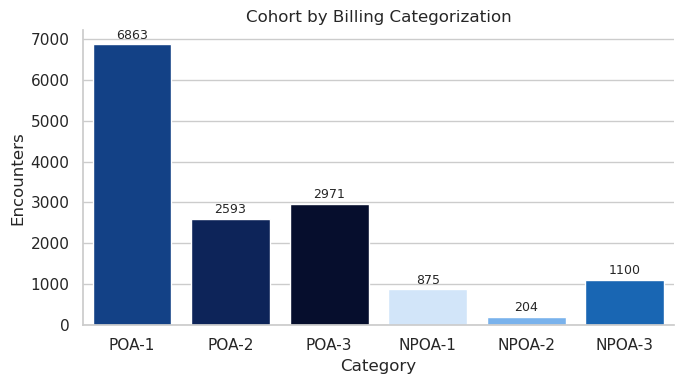

In [109]:
STRATA = ["POA-1","POA-2","POA-3","NPOA-1","NPOA-2","NPOA-3"]

cnt = (df.group_by("Sepsis_Category").agg(pl.len().alias("n"))
         .rename({"Sepsis_Category":"category"}))
order_present = [s for s in STRATA if s in cnt.get_column("category").to_list()]
cnt_pd = cnt.to_pandas()

fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(data=cnt_pd, x="category", y="n", order=order_present,
            palette=PALETTE_FULL, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%d", padding=2, fontsize=9)
ax.set_title(f"Cohort by {get_display_name('Sepsis_Category')}")
ax.set_xlabel("Category"); ax.set_ylabel("Encounters")
sns.despine(ax=ax)
fig.tight_layout(); fig.savefig("fig1_intro_counts.png", dpi=200, bbox_inches="tight")

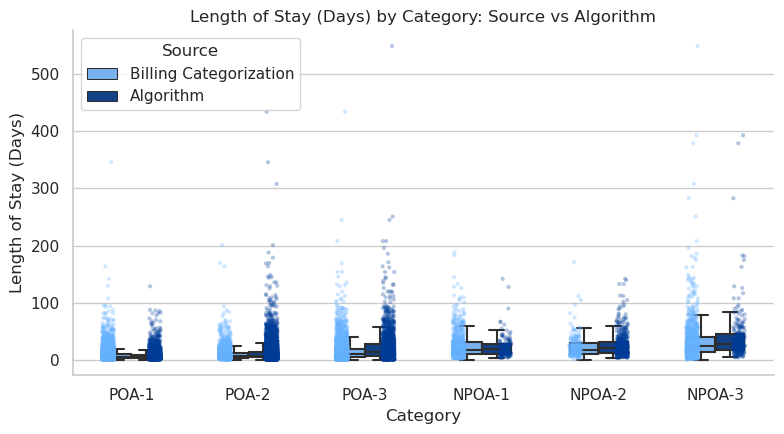

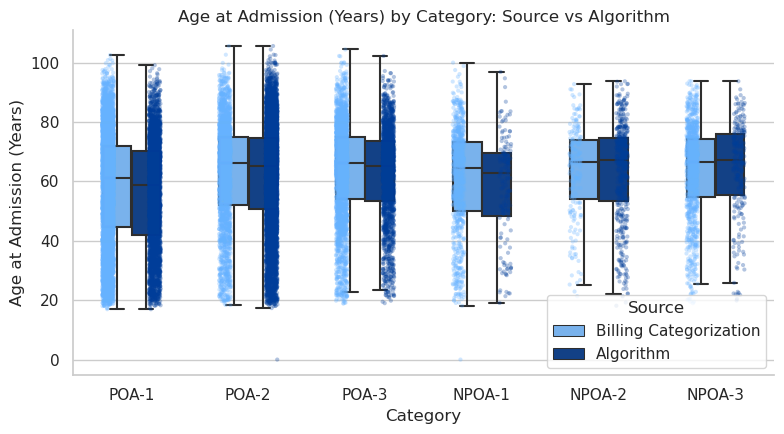

In [111]:
def melt_two_sources(df, value_col, strata=STRATA):
    """Stack the same encounters under both labelings → one long pandas frame
       with columns [category, source, <value_col>], ready for sns box+strip."""
    src = (df.select(pl.col("Sepsis_Category").alias("category"),
                     pl.col(value_col))
             .with_columns(pl.lit("Billing Categorization").alias("source")))
    cmp = (df.select(pl.col("Computed_Sepsis_Category").alias("category"),
                     pl.col(value_col))
             .with_columns(pl.lit("Algorithm").alias("source")))
    return (pl.concat([src, cmp])
              .filter(pl.col("category").is_in(strata))
              .drop_nulls(subset=[value_col])
              .to_pandas())

def box_strip_compare(df, value_col, fname, strata=STRATA):
    m = melt_two_sources(df, value_col, strata)
    order = [s for s in strata if s in m["category"].unique()]
    fig, ax = plt.subplots(figsize=(8,4.5))
    sns.stripplot(data=m, x="category", y=value_col, hue="source",
                  order=order, hue_order=SOURCE_ORDER, palette=PALETTE_SRC_CMP,
                  dodge=True, alpha=0.3, size=3, jitter=True, ax=ax, legend=False)
    sns.boxplot(data=m, x="category", y=value_col, hue="source",
                order=order, hue_order=SOURCE_ORDER, palette=PALETTE_SRC_CMP,
                dodge=True, width=0.5, flierprops={"marker":""}, ax=ax)
    ax.set_title(f"{get_display_name(value_col)} by Category: Source vs Algorithm")
    ax.set_xlabel("Category"); ax.set_ylabel(get_display_name(value_col))
    ax.legend(title="Source", loc="best")
    sns.despine(ax=ax)
    fig.tight_layout(); fig.savefig(fname, dpi=200, bbox_inches="tight")

box_strip_compare(df_sepsis_v2_max_first, "los_source",            "fig2_los_compare.png")
box_strip_compare(df_sepsis_v2_max_first, "PatientAgeAtAdmission", "fig3_age_compare.png")

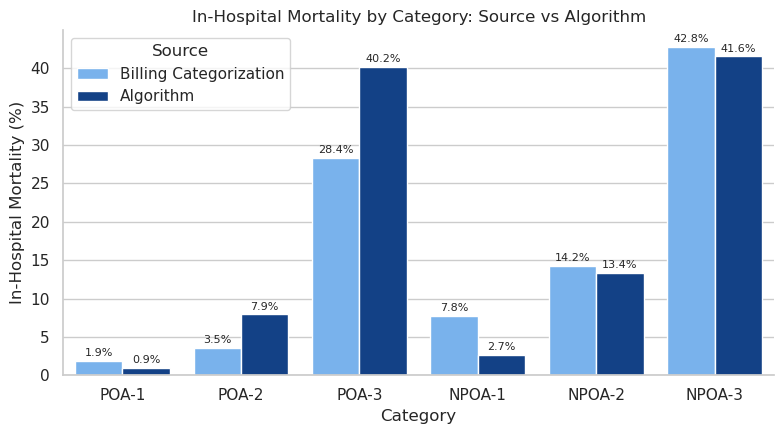

In [112]:
mort = (pl.concat([
    df_sepsis_v2_max_first.group_by("Sepsis_Category").agg((pl.col("Death_Flag")==1).mean().mul(100).alias("pct"))
      .rename({"Sepsis_Category":"category"}).with_columns(pl.lit("Billing Categorization").alias("source")),
    df_sepsis_v2_max_first.group_by("Computed_Sepsis_Category").agg((pl.col("Death_Flag")==1).mean().mul(100).alias("pct"))
      .rename({"Computed_Sepsis_Category":"category"}).with_columns(pl.lit("Algorithm").alias("source")),
]).filter(pl.col("category").is_in(STRATA)).to_pandas())

order = [s for s in STRATA if s in mort["category"].unique()]
fig, ax = plt.subplots(figsize=(8,4.5))
sns.barplot(data=mort, x="category", y="pct", hue="source",
            order=order, hue_order=SOURCE_ORDER, palette=PALETTE_SRC_CMP, ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=2, fontsize=8)
ax.set_title("In-Hospital Mortality by Category: Source vs Algorithm")
ax.set_xlabel("Category"); ax.set_ylabel(get_display_name("Death_Flag"))
ax.legend(title="Source", loc="best"); sns.despine(ax=ax)
fig.tight_layout(); fig.savefig("fig4_mortality_compare.png", dpi=200, bbox_inches="tight")

In [113]:
df_ov = df_sepsis_v2_max_first.with_columns(pl.lit("Overall").alias("Overall"))   # one synthetic group

In [17]:
CONTINUOUS_VARS  = [("PatientAgeAtAdmission", "Age, years — median [IQR]")]
CATEGORICAL_VARS = [                       # (column, display prefix, top_n or None)
    ("Sex",             "Sex",              None),   # low cardinality → keep all levels
    ("FirstRace",       "Race",             8),      # collapse to top-8 + Other
    ("HospitalService", "Hospital service", 10),
    ("AdmissionSource", "Admission source", 10),
]

def build_long_spec(df, group, norm="column"):
    parts = []
    for col, label in CONTINUOUS_VARS:
        parts.append(rows_continuous(summarize_continuous(df, col, group), label, group))
    for col, prefix, top_n in CATEGORICAL_VARS:
        d = collapse_top_n(df, col, top_n) if top_n else df
        cnt, _ = summarize_categorical(d, col, group, norm)
        parts.append(rows_categorical(cnt, col, prefix, group))
    long  = pl.concat(parts)
    order = long.select("label").unique(maintain_order=True).with_row_index("ord")
    return long.join(order, on="label")

In [18]:
STRATA = ["POA-1","POA-2","POA-3","NPOA-1","NPOA-2","NPOA-3"]

# → INTRO SLIDE 1 table (single "Overall" column)
table_overall   = to_wide(build_long_spec(df_ov, "Overall"), df_ov, "Overall", ["Overall"])

# → INTRO SLIDE 2 table (six stratum columns)
table_by_sepsis = to_wide(build_long_spec(df, "Sepsis_Category"), df, "Sepsis_Category", STRATA)

NameError: name 'to_wide' is not defined

In [117]:
table_overall.to_pandas()

,label,Overall
0,N (encounters),14606
1,"Age, years — median [IQR]","63.8 [48.9, 73.5]"
2,Sex: Female,6829 (46.8%)
3,Sex: Male,7777 (53.2%)
4,Race: Asian,368 (2.5%)
5,Race: Black or African American,3373 (23.1%)
6,"Race: East Asian (China, North/South Korea, Ja...",102 (0.7%)
7,Race: Other,139 (1.0%)
8,Race: Some other race,256 (1.8%)
9,"Race: South Asian (India, Pakistan, Bangladesh...",171 (1.2%)


In [152]:
def slice_table(wide, prefixes=None, keep_exact=None, strip_prefix=None):
    """Pull a topic sub-table out of a built wide table.
       prefixes   : keep rows whose label starts with any of these
       keep_exact : also keep these exact labels (e.g. the N row)
       strip_prefix: remove this leading text from labels for clean slide display"""
    cond = pl.lit(False)
    for p in (prefixes or []):
        cond = cond | pl.col("label").str.starts_with(p)
    if keep_exact:
        cond = cond | pl.col("label").is_in(keep_exact)
    out = wide.filter(cond)
    if strip_prefix:
        out = out.with_columns(
            pl.col("label").str.strip_prefix(strip_prefix).alias("label"))
    return out

def sort_by_count(tbl, value_col="Overall", descending=True, keep_other_last=True):
    out = tbl.with_columns(
        pl.col(value_col).str.extract(r"^(\d+)", 1).cast(pl.Int64).alias("_sortkey")
    )
    if keep_other_last:
        # "Other" is a residual bucket, not a real category — pin it to the bottom
        out = out.with_columns(
            (pl.col("label").str.strip_chars() == "Other").alias("_is_other")
        ).sort(["_is_other", "_sortkey"], descending=[False, descending])
        return out.drop("_sortkey", "_is_other")
    return out.sort("_sortkey", descending=descending).drop("_sortkey")

def truncate_labels(tbl, n=40, ellipsis="…"):
    """Truncate the `label` column to n chars, adding an ellipsis only when cut."""
    return tbl.with_columns(
        pl.when(pl.col("label").str.len_chars() > n)
          .then(pl.col("label").str.slice(0, n) + pl.lit(ellipsis))
          .otherwise(pl.col("label"))
          .alias("label")
    )


In [153]:
race_tbl = truncate_labels(sort_by_count(slice_table(table_overall, ["Race:"],             strip_prefix="Race: ")))
hs_tbl   = truncate_labels(sort_by_count(slice_table(table_overall, ["Hospital service:"], strip_prefix="Hospital service: ")))
asrc_tbl = truncate_labels(sort_by_count(slice_table(table_overall, ["Admission source:"], strip_prefix="Admission source: ")))

In [156]:
df_sepsis_v2_max_first.columns

['PrimaryMrn',
 'PatientAgeAtAdmission',
 'Sex',
 'Ethnicity',
 'FirstRace',
 'MultiRacial',
 'EncounterEpicCsn',
 'AdmissionDateValue',
 'DischargeDateValue',
 'Arrival_Instant',
 'FirstAdmissionOrderInstant',
 'InpatientAdmissionInstant',
 'Admitted_from_ED',
 'PatientClass',
 'InpatientAdmissionPatientClass',
 'HospitalService',
 'LengthOfStayInDays',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 'PrimaryCodedDiagnosis',
 'PrimaryCodedProcedureKey',
 'Death_Flag',
 'Original_POA_Condition',
 'Sepsis_Category',
 'Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'First_Suspected_Infection_Time',
 'Suspected_Infection_Criteria_Met',
 'Cancer_Registry_YN',
 'HIV_Registry_YN',
 'Immunocrompromised_Registry_YN',
 'CKD_Dialysis_Registry_YN',
 'Solid_Organ_Transplant_Registry_YN',
 'Pregn

In [157]:
df_sepsis_v2_max_first['Arrival_Instant'].min(), df_sepsis_v2_max_first['DischargeDateValue'].max()

(datetime.datetime(2022, 6, 1, 0, 49), datetime.datetime(2026, 6, 2, 0, 0))

In [154]:
race_tbl.to_pandas()

,label,Overall
0,White,9669 (66.2%)
1,Black or African American,3373 (23.1%)
2,Unavailable/Unknown,442 (3.0%)
3,Asian,368 (2.5%)
4,Some other race,256 (1.8%)
5,"South Asian (India, Pakistan, Bangladesh…",171 (1.2%)
6,"East Asian (China, North/South Korea, Ja…",102 (0.7%)
7,"Southeast Asian (Thailand, Vietnam, Camb…",86 (0.6%)
8,Other,139 (1.0%)


14,606 encounters across 10,926 patients (1.34 per patient)


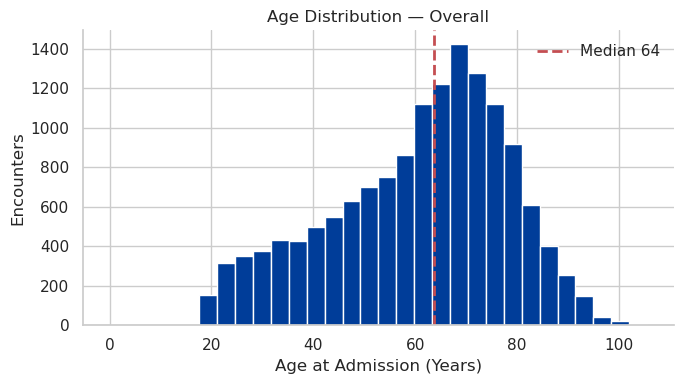

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# → INTRO SLIDE 1 headline (text on the slide, not a table)
n_enc, n_pat = df.height, df.get_column("PrimaryMrn").n_unique()
print(f"{n_enc:,} encounters across {n_pat:,} patients ({n_enc/n_pat:.2f} per patient)")

# → INTRO SLIDE 1 figure: age distribution (shape is the message → histogram)
ages = df.get_column("PatientAgeAtAdmission").drop_nulls().to_numpy()
med  = float(df.get_column("PatientAgeAtAdmission").median())
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(ages, bins=30, color="#003d99", edgecolor="white")
ax.axvline(med, color="#C44E52", lw=2, ls="--", label=f"Median {med:.0f}")
ax.set_xlabel(get_display_name("PatientAgeAtAdmission")); ax.set_ylabel("Encounters")
ax.set_title("Age Distribution — Overall"); ax.legend(frameon=False); sns.despine(ax=ax)
fig.tight_layout(); fig.savefig("fig_overall_age_hist.png", dpi=200, bbox_inches="tight")

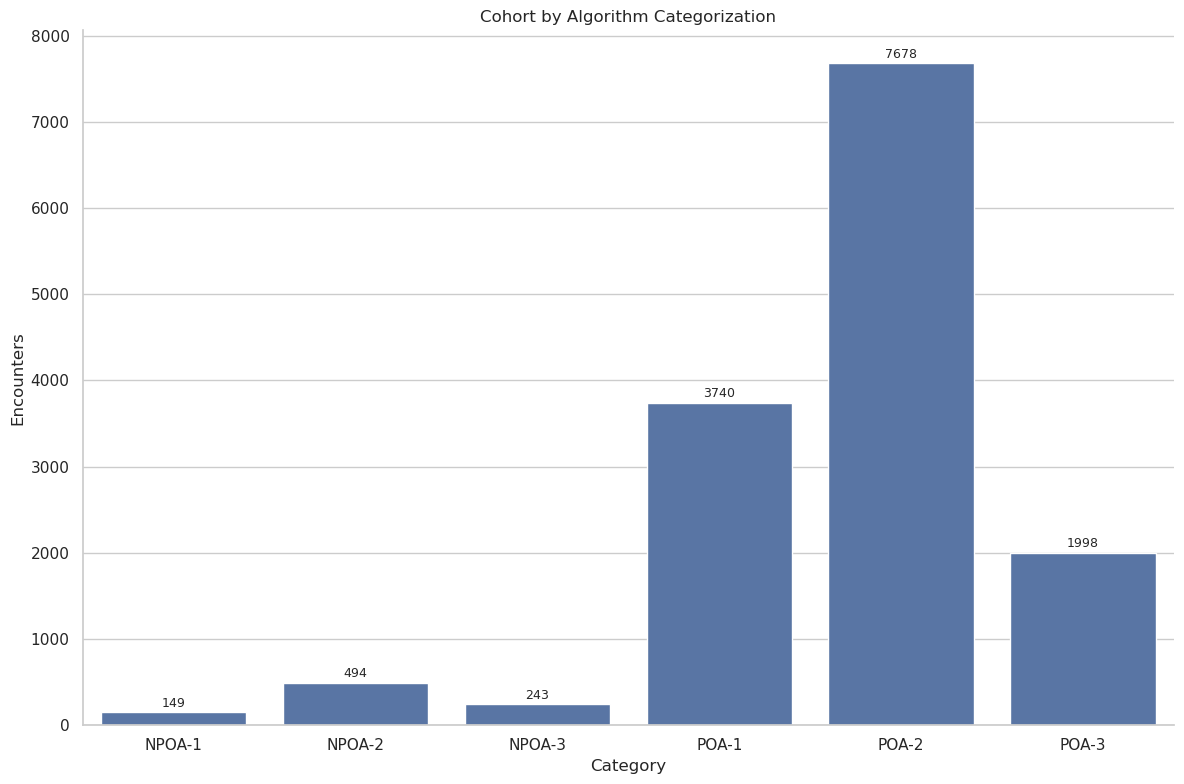

In [77]:
# → INTRO SLIDE 2 figure A: encounters per stratum (the counts bar, your stratum palette)
cnt_pd = (df_sepsis_v2_max_first.group_by("Computed_Sepsis_Category").agg(pl.len().alias("n"))
            .rename({"Computed_Sepsis_Category":"category"}).to_pandas())
order_present = [s for s in STRATA if s in cnt_pd["category"].values]
fig, ax = plt.subplots(figsize=(12,8))
sns.barplot(data=cnt_pd, x="category", y="n", order=order_present, ax=ax, palette=None, color='#4C72B0') # Billing color: #DD842
            # hue="category", palette=PALETTE_FULL, ax=ax)
for c in ax.containers: ax.bar_label(c, fmt="%d", padding=2, fontsize=9)
ax.set_title(f"Cohort by {get_display_name('Computed_Sepsis_Category')}")
ax.set_xlabel("Category"); ax.set_ylabel("Encounters"); sns.despine(ax=ax)
fig.tight_layout(); fig.savefig("fig_sepsis_counts.png", dpi=200, bbox_inches="tight")

NameError: name 'get_display_name' is not defined

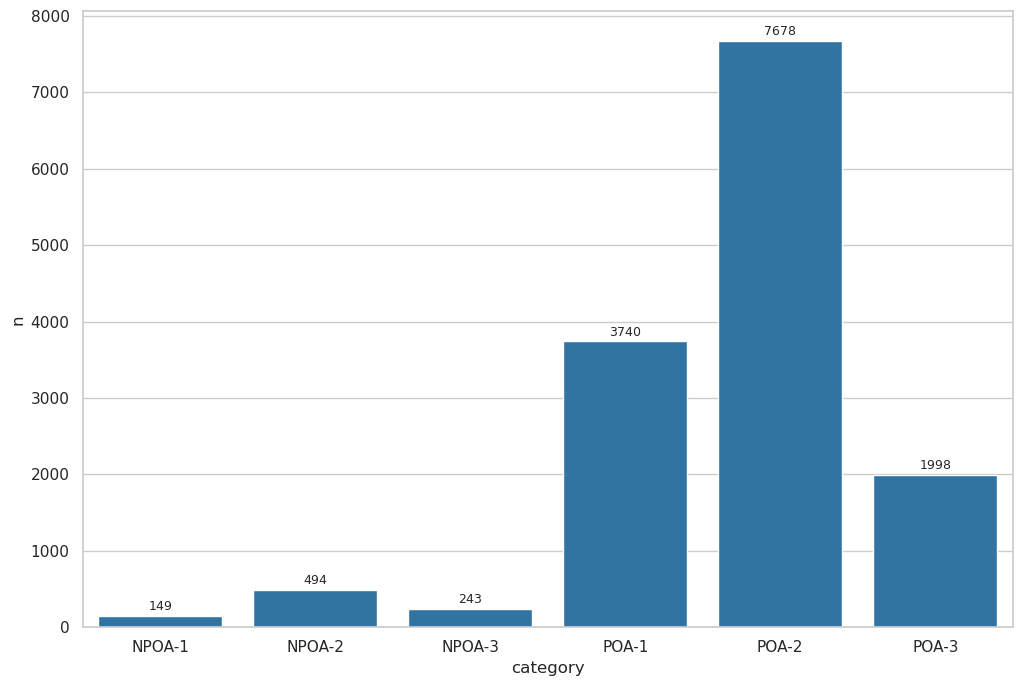

In [71]:
# → INTRO SLIDE 2 figure A: encounters per stratum (the counts bar, your stratum palette)
cnt_pd = (df_sepsis_v2_max_first.group_by("Computed_Sepsis_Category").agg(pl.len().alias("n"))
            .rename({"Computed_Sepsis_Category":"category"}).to_pandas())
order_present = [s for s in STRATA if s in cnt_pd["category"].values]
fig, ax = plt.subplots(figsize=(12,8))
sns.barplot(data=cnt_pd, x="category", y="n", order=order_present, ax=ax, palette=None, color='tab:blue')
            # hue="category", palette=PALETTE_FULL, ax=ax)
for c in ax.containers: ax.bar_label(c, fmt="%d", padding=2, fontsize=9)
ax.set_title(f"Cohort by {get_display_name('Computed_Sepsis_Category')} - Arrival + 48 hours")
ax.set_xlabel("Category"); ax.set_ylabel("Encounters"); sns.despine(ax=ax)
fig.tight_layout(); fig.savefig("fig_algosepsis_counts.png", dpi=200, bbox_inches="tight")

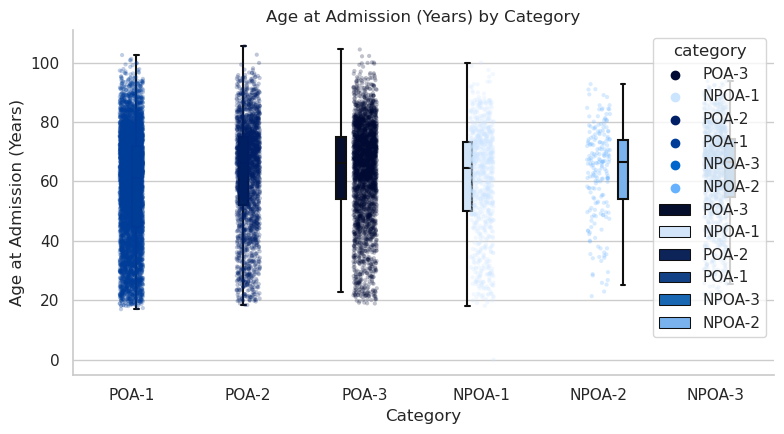

In [130]:
# → INTRO SLIDE 2 figure B: age by stratum (single-grouping box+strip, your house idiom)
def box_strip_single(df, value_col, group, palette, order, fname):
    m = (df.select(pl.col(group).alias("category"), pl.col(value_col))
           .filter(pl.col("category").is_in(order))
           .drop_nulls(subset=[value_col]).to_pandas())
    ords = [s for s in order if s in m["category"].unique()]
    fig, ax = plt.subplots(figsize=(8,4.5))
    sns.stripplot(data=m, x="category", y=value_col, order=ords, hue="category",
                  palette=palette,  alpha=0.25, size=3, jitter=True, ax=ax)
    sns.boxplot(data=m, x="category", y=value_col, order=ords, hue="category",
                palette=palette, width=0.5,
                flierprops={"marker":""}, ax=ax)
    ax.set_title(f"{get_display_name(value_col)} by Category")
    ax.set_xlabel("Category"); ax.set_ylabel(get_display_name(value_col)); sns.despine(ax=ax)
    fig.tight_layout(); fig.savefig(fname, dpi=200, bbox_inches="tight")

box_strip_single(df_sepsis_v2_max_first, "PatientAgeAtAdmission", "Sepsis_Category",
                 PALETTE_FULL, STRATA, "fig_sepsis_age_box.png")

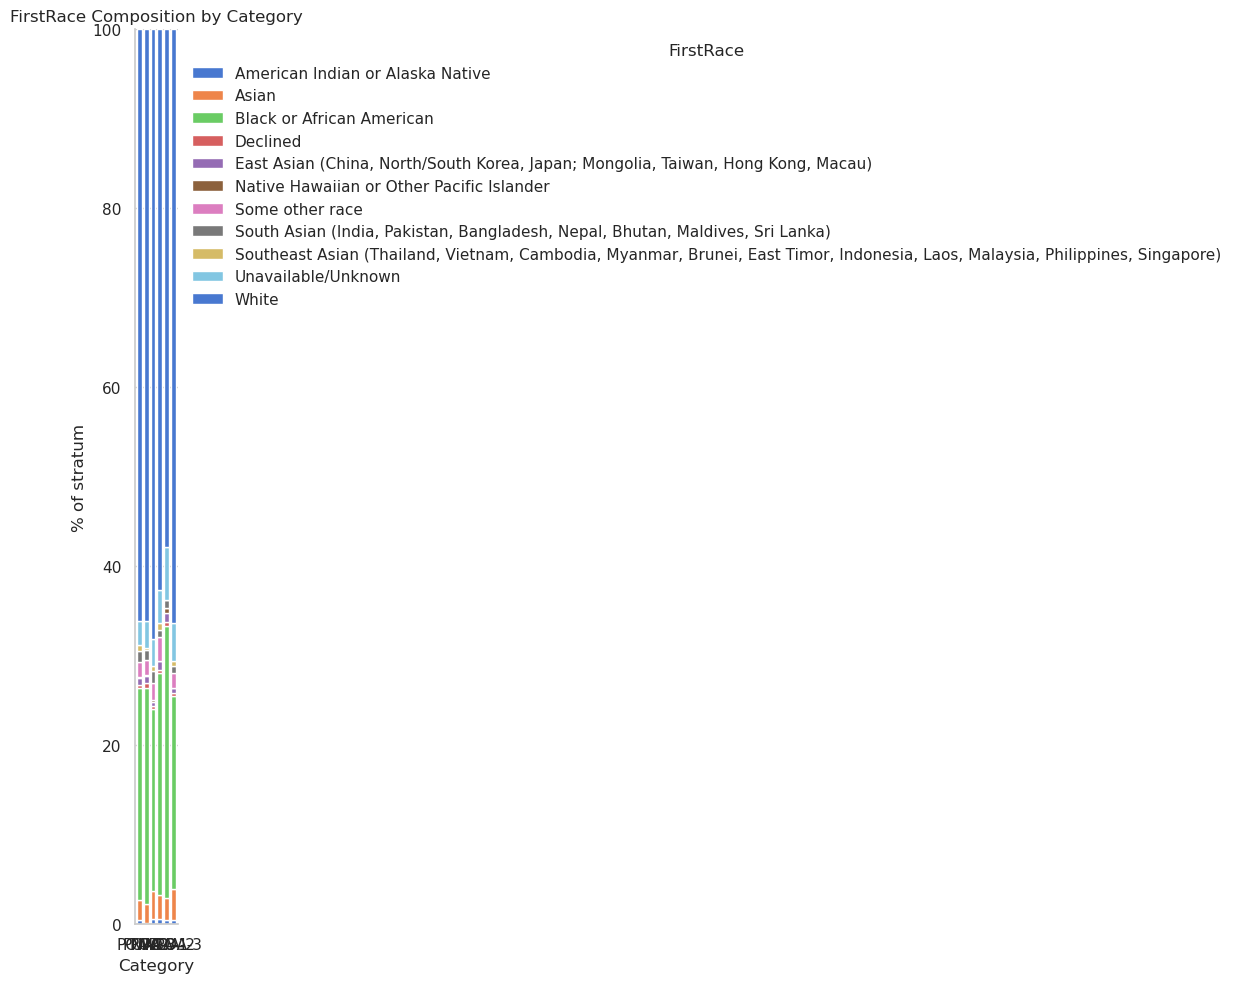

In [135]:
def stacked_proportion_bar(df, var, group, order, fname,
                           level_order=None, palette=None):
    # Column-normalized proportions: each stratum sums to 1.0 (same math as the table)
    prop = (
        df.drop_nulls(subset=[var])
          .group_by([group, var]).agg(pl.len().alias("count"))
          .with_columns((pl.col("count") / pl.col("count").sum().over(group)).alias("prop"))
    )
    # Pivot to strata (rows) × levels (columns) for stacking
    wide = (prop.pivot(values="prop", index=group, on=var)
                .fill_null(0.0))
    strata = [s for s in order if s in wide.get_column(group).to_list()]
    wide = wide.filter(pl.col(group).is_in(strata)).to_pandas().set_index(group).loc[strata]

    levels = level_order or list(wide.columns)
    fig, ax = plt.subplots(figsize=(12, 10))
    bottom = [0.0] * len(wide)
    for i, lvl in enumerate(levels):
        vals = (wide[lvl] * 100).tolist()
        color = (palette or {}).get(lvl)  # falls back to mpl default if not in palette
        ax.bar(wide.index, vals, bottom=bottom, label=str(lvl),
               color=color, edgecolor="white", width=0.7)
        bottom = [b + v for b, v in zip(bottom, vals)]

    ax.set_ylabel("% of stratum"); ax.set_xlabel("Category")
    ax.set_title(f"{get_display_name(var)} Composition by Category")
    ax.set_ylim(0, 100)
    ax.legend(title=var, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    sns.despine(ax=ax)
    fig.tight_layout(); fig.savefig(fname, dpi=200, bbox_inches="tight")

# Sex — the natural fit. Two tones from your blue family so it sits with the other figures.
# SEX_PALETTE = {"Female": "#66b2ff", "Male": "#003d99"}
VAR = "FirstRace"
stacked_proportion_bar(df_sepsis_v2_max_first, VAR, "Sepsis_Category", STRATA,
                        f"fig_sepsis_{VAR}_stacked.png",
                        level_order=sorted(df_sepsis_v2_max_first[VAR].unique().to_list()))#, palette=SEX_PALETTE)

In [132]:
df_sepsis_v2_max_first.columns

['PrimaryMrn',
 'PatientAgeAtAdmission',
 'Sex',
 'Ethnicity',
 'FirstRace',
 'MultiRacial',
 'EncounterEpicCsn',
 'AdmissionDateValue',
 'DischargeDateValue',
 'Arrival_Instant',
 'FirstAdmissionOrderInstant',
 'InpatientAdmissionInstant',
 'Admitted_from_ED',
 'PatientClass',
 'InpatientAdmissionPatientClass',
 'HospitalService',
 'LengthOfStayInDays',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 'PrimaryCodedDiagnosis',
 'PrimaryCodedProcedureKey',
 'Death_Flag',
 'Original_POA_Condition',
 'Sepsis_Category',
 'Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'First_Suspected_Infection_Time',
 'Suspected_Infection_Criteria_Met',
 'Cancer_Registry_YN',
 'HIV_Registry_YN',
 'Immunocrompromised_Registry_YN',
 'CKD_Dialysis_Registry_YN',
 'Solid_Organ_Transplant_Registry_YN',
 'Pregn

In [9]:
df_all_v2 = DataLoader(input_output_config_2).load_data()
df_all_v3 = DataLoader(input_output_config_3).load_data()

In [10]:
df_all_v2['EncounterEpicCsn'].n_unique(), df_all_v3['EncounterEpicCsn'].n_unique()

(3983, 14932)

In [17]:
df_all_v3.columns

['EncounterEpicCsn',
 'Event_DateTime',
 'Type',
 'Event_Grouper',
 'Event_Name',
 'NumericValue',
 'Value',
 'Flag',
 'PrimaryMrn',
 'PatientAgeAtAdmission',
 'Sex',
 'Ethnicity',
 'FirstRace',
 'MultiRacial',
 'EncounterEpicCsn_right',
 'AdmissionDateValue',
 'DischargeDateValue',
 'Arrival_Instant',
 'FirstAdmissionOrderInstant',
 'InpatientAdmissionInstant',
 'Admitted_from_ED',
 'PatientClass',
 'InpatientAdmissionPatientClass',
 'HospitalService',
 'LengthOfStayInDays',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 'PrimaryCodedDiagnosis',
 'PrimaryCodedProcedureKey',
 'Death_Flag',
 'Original_POA_Condition',
 'Sepsis_Category',
 'Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'First_Suspected_Infection_Time',
 'Suspected_Infection_Criteria_Met',
 'Cancer_Registry_YN',
 'HIV_

In [11]:
df_all_v3.columns

['EncounterEpicCsn',
 'Event_DateTime',
 'Type',
 'Event_Grouper',
 'Event_Name',
 'NumericValue',
 'Value',
 'Flag',
 'PrimaryMrn',
 'PatientAgeAtAdmission',
 'Sex',
 'Ethnicity',
 'FirstRace',
 'MultiRacial',
 'EncounterEpicCsn_right',
 'AdmissionDateValue',
 'DischargeDateValue',
 'Arrival_Instant',
 'FirstAdmissionOrderInstant',
 'InpatientAdmissionInstant',
 'Admitted_from_ED',
 'PatientClass',
 'InpatientAdmissionPatientClass',
 'HospitalService',
 'LengthOfStayInDays',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 'PrimaryCodedDiagnosis',
 'PrimaryCodedProcedureKey',
 'Death_Flag',
 'Original_POA_Condition',
 'Sepsis_Category',
 'Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'First_Suspected_Infection_Time',
 'Suspected_Infection_Criteria_Met',
 'Cancer_Registry_YN',
 'HIV_

### How many times were antibiotics administered without being accompained with blood coluture within the suspected infection period?

#### Focusing on only IV antibiotics versus IV antibiotics + Blood culture criterion

In [27]:
df_infect_long_3

EncounterEpicCsn,criterion,infect_dt,suspicion_infection_type
i64,str,datetime[μs],str
731318735,"""iv_dt""",2025-07-15 18:35:17,"""IV+Culture"""
687472764,"""iv_dt""",2023-08-24 20:57:13,"""IV+Culture"""
668209783,"""iv_dt""",2022-09-13 12:26:00,"""IV+Culture"""
680474280,"""iv_dt""",2023-04-17 17:05:00,"""IV+Culture"""
733073896,"""iv_dt""",2025-08-11 05:33:47,"""IV+Culture"""
…,…,…,…
718649338,"""first_ev_time_flowsheet""",2024-12-31 22:56:00,"""FLOWSHEET_SUSPECTED_INFECTION"""
719743257,"""first_ev_time_flowsheet""",2025-01-20 16:38:00,"""FLOWSHEET_SUSPECTED_INFECTION"""
663847653,"""first_ev_time_flowsheet""",2022-06-17 23:00:00,"""FLOWSHEET_SUSPECTED_INFECTION"""


In [28]:
df_infect_long_3.filter(
    pl.col("criterion").str.contains("iv_dt")
).sort(by=["EncounterEpicCsn", "infect_dt"])

EncounterEpicCsn,criterion,infect_dt,suspicion_infection_type
i64,str,datetime[μs],str
659308243,"""iv_dt""",2022-06-15 23:40:38,"""IV+Culture"""
661424247,"""iv_dt""",2022-09-03 19:39:40,"""IV+Culture"""
661471289,"""iv_dt""",2022-06-08 21:58:00,"""IV+Culture"""
662152913,"""iv_dt""",2022-08-17 23:34:00,"""IV+Culture"""
662608744,"""iv_dt""",2022-07-14 16:23:17,"""IV+Culture"""
…,…,…,…
753558469,"""iv_dt""",2026-05-25 19:43:52,"""IV+Culture"""
753563196,"""iv_dt""",2026-05-26 05:40:31,"""IV+Culture"""
753573877,"""iv_dt""",2026-05-26 13:06:06,"""IV+Culture"""


In [94]:
df_all_3.filter(df_all_3['Type'].str.contains("IV Antibiotics"))['Type'].unique()

Type
str
"""IV Antibiotics"""
"""IV Antibiotics - First"""
"""IV Antibiotics - Single"""
"""IV Antibiotics - Last"""


In [101]:
df_all_3.filter(
    pl.col("Type").str.contains("IV Antibiotics")
).group_by("EncounterEpicCsn").agg(
	pl.col("Event_DateTime").min().alias("iv_dt")
)

EncounterEpicCsn,iv_dt
i64,datetime[μs]
682130345,2023-05-16 06:21:56
735015191,2025-09-15 16:19:50
667353438,2022-08-25 18:02:41
676960290,2023-02-12 04:56:00
682431039,2023-05-21 00:31:00
…,…
743719416,2026-01-05 13:14:17
738251942,2025-10-14 00:15:00
700011862,2024-03-17 15:50:39


In [111]:
df_all_3.filter(
    pl.col("Type").str.contains("IV Antibiotics")
).group_by("EncounterEpicCsn").agg(
	pl.col("Event_DateTime").min().alias("iv_dt")
).join(
    df_infect_long_2.filter(
         pl.col("criterion").str.contains("iv_dt")
	).rename({"infect_dt":"iv_dt"}),
    on=['EncounterEpicCsn', 'iv_dt'],
	how='anti'
).join(
    df_all_3.select(
        "EncounterEpicCsn", "Arrival_Instant", "Sepsis_Category"
	).group_by("EncounterEpicCsn").agg(
		pl.col("Arrival_Instant").min().alias("Arrival_Instant"),
		pl.col("Sepsis_Category").min().alias("Sepsis_Category")
	),
    on="EncounterEpicCsn",
	how='inner'
).with_columns(
    (pl.col("iv_dt")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True).alias("arrival to first antibiotic hrs")
).filter(pl.col("arrival to first antibiotic hrs") < 24)['Sepsis_Category'].value_counts(sort=True)

Sepsis_Category,count
str,u64
"""POA-1""",6450
"""POA-3""",2793
"""POA-2""",2465
"""NPOA-3""",499
"""NPOA-1""",308
"""UPOA-1""",245
"""NPOA-2""",84
"""UPOA-2""",26
"""UPOA-3""",10


In [121]:
df_all_3.filter(
    pl.col("Type").str.contains("IV Antibiotics")
).group_by("EncounterEpicCsn").agg(
	pl.col("Event_DateTime").min().alias("iv_dt")
).join(
    df_infect_long_2.filter(
         pl.col("criterion").str.contains("iv_dt")
	).rename({"infect_dt":"iv_dt"}),
    on=['EncounterEpicCsn', 'iv_dt'],
	how='anti'
).join(
    df_sepsis_v2_max_first.select(
        "EncounterEpicCsn", "Arrival_Instant", "Sepsis_Category", "Computed_Sepsis_Category"
	),
    on="EncounterEpicCsn",
	how='inner'
).with_columns(
    (pl.col("iv_dt")-pl.col("Arrival_Instant")).dt.total_hours(fractional=True).alias("arrival to first antibiotic hrs")
).filter(pl.col("arrival to first antibiotic hrs") < 24)['Computed_Sepsis_Category'].value_counts(sort=True)

Computed_Sepsis_Category,count
str,u64
"""POA-2""",7096
"""POA-1""",3557
"""POA-3""",1675
null,198
"""NPOA-2""",40
"""NPOA-3""",17
"""NPOA-1""",16


In [143]:
df_sepsis_v2_max_first.join(
    df_infect_long_2.filter(pl.col("criterion") == "iv_dt"),
    on="EncounterEpicCsn",
	how='inner'
).select(
    "EncounterEpicCsn",
    "Sepsis_Category",
	"Computed_Sepsis_Category",
	"infect_dt",
	"criterion",
    "Arrival_Instant"
).join(
    df_all_3.filter(
    pl.col("Type").str.contains("IV Antibiotics")
	).group_by("EncounterEpicCsn").agg(
		pl.col("Event_DateTime").min().alias("first_iv_dt")
	),
	on="EncounterEpicCsn",
	how='inner'
).with_columns(
    (pl.col("infect_dt")-pl.col("first_iv_dt")).dt.total_hours(fractional=True).alias("first antibiotic administered to first IV SI detectd hrs")
).filter(pl.col('first antibiotic administered to first IV SI detectd hrs')<pl.col('first antibiotic administered to first IV SI detectd hrs').quantile(0.95)
    

SyntaxError: incomplete input (1940518027.py, line 23)

In [145]:
df_sepsis_v2_max_first.join(
    df_infect_long_2.filter(pl.col("criterion") == "iv_dt"),
    on="EncounterEpicCsn",
	how='inner'
).select(
    "EncounterEpicCsn",
    "Sepsis_Category",
	"Computed_Sepsis_Category",
	"infect_dt",
	"criterion",
    "Arrival_Instant"
).join(
    df_all_3.filter(
    pl.col("Type").str.contains("IV Antibiotics")
	).group_by("EncounterEpicCsn").agg(
		pl.col("Event_DateTime").min().alias("first_iv_dt")
	),
	on="EncounterEpicCsn",
	how='inner'
).with_columns(
    (pl.col("infect_dt")-pl.col("first_iv_dt")).dt.total_hours(fractional=True).alias("first antibiotic administered to first IV SI detectd hrs")
)

EncounterEpicCsn,Sepsis_Category,Computed_Sepsis_Category,infect_dt,criterion,Arrival_Instant,first_iv_dt,first antibiotic administered to first IV SI detectd hrs
i64,str,str,datetime[μs],str,datetime[μs],datetime[μs],f64
680404543,"""POA-1""","""POA-2""",2023-04-15 02:30:00,"""iv_dt""",2023-04-14 16:31:00,2023-04-14 20:21:00,6.15
750015192,"""POA-3""","""POA-2""",2026-04-06 21:17:24,"""iv_dt""",2026-04-06 02:38:00,2026-04-06 05:22:00,15.923333
723370967,"""NPOA-2""","""POA-3""",2025-03-17 18:33:23,"""iv_dt""",2025-03-16 13:24:00,2025-03-16 18:26:00,24.123056
704193056,"""POA-1""","""POA-2""",2024-05-22 16:55:00,"""iv_dt""",2024-05-19 12:49:00,2024-05-20 21:06:00,43.816667
665925323,"""NPOA-3""","""POA-3""",2022-07-31 02:52:00,"""iv_dt""",2022-07-28 18:37:00,2022-07-29 02:18:00,48.566667
…,…,…,…,…,…,…,…
687542495,"""POA-1""","""POA-1""",2023-08-24 04:44:00,"""iv_dt""",2023-08-23 10:53:00,2023-08-23 12:02:03,16.699167
733745152,"""POA-1""","""POA-2""",2025-08-20 23:43:00,"""iv_dt""",2025-08-19 19:15:00,2025-08-19 21:00:00,26.716667
679145386,"""POA-2""","""POA-2""",2023-03-23 09:49:25,"""iv_dt""",2023-03-22 17:48:00,2023-03-23 00:03:00,9.773611


In [146]:
os.path.abspath(".")

'/endosome/work/InternalMedicine/s223850/Sepsis'

In [147]:
df_sepsis_v2_max_first.join(
    df_infect_long_2.filter(pl.col("criterion") == "iv_dt").group_by("EncounterEpicCsn").agg(
        pl.col("infect_dt").min().alias("infect_dt")
	).join(
		df_infect_long_2,
		on=["EncounterEpicCsn", "infect_dt"],
        how='inner'
	),
    on="EncounterEpicCsn",
	how='inner'
).select(
    "EncounterEpicCsn",
    "Sepsis_Category",
	"Computed_Sepsis_Category",
	"infect_dt",
	"criterion",
    "Arrival_Instant"
).join(
    df_all_3.filter(
    pl.col("Type").str.contains("IV Antibiotics")
	).group_by("EncounterEpicCsn").agg(
		pl.col("Event_DateTime").min().alias("first_iv_dt")
	),
	on="EncounterEpicCsn",
	how='inner'
).with_columns(
    (pl.col("infect_dt")-pl.col("first_iv_dt")).dt.total_hours(fractional=True).alias("first antibiotic administered to first IV SI detectd hrs")
).write_csv("first_antibiotic_first_IV_suspected_infection.csv")

<Axes: xlabel='first antibiotic administered to first IV SI detectd hrs', ylabel='Computed_Sepsis_Category'>

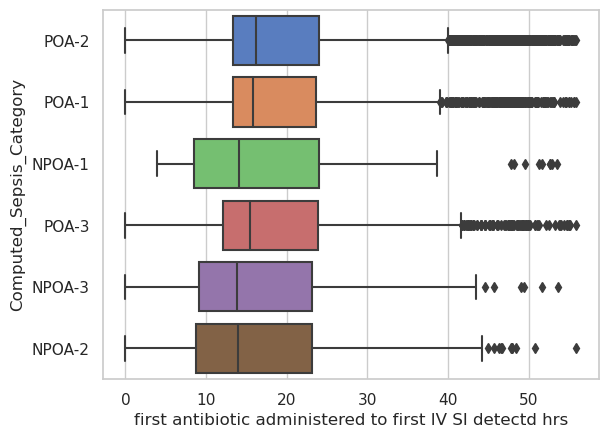

In [140]:
sns.boxplot(data=df_sepsis_v2_max_first.join(
      df_infect_long_2.filter(pl.col("criterion") == "iv_dt").group_by("EncounterEpicCsn").agg(
        pl.col("infect_dt").min().alias("infect_dt")
	).join(
		df_infect_long_2,
		on=["EncounterEpicCsn", "infect_dt"],
        how='inner'
	),
    on="EncounterEpicCsn",
	how='inner'
).select(
    "EncounterEpicCsn",
    "Sepsis_Category",
	"Computed_Sepsis_Category",
	"infect_dt",
	"criterion",
    "Arrival_Instant"
).join(
    df_all_3.filter(
    pl.col("Type").str.contains("IV Antibiotics")
	).group_by("EncounterEpicCsn").agg(
		pl.col("Event_DateTime").min().alias("first_iv_dt")
	),
	on="EncounterEpicCsn",
	how='inner'
).with_columns(
    (pl.col("infect_dt")-pl.col("first_iv_dt")).dt.total_hours(fractional=True).alias("first antibiotic administered to first IV SI detectd hrs")
).filter(pl.col('first antibiotic administered to first IV SI detectd hrs')<pl.col('first antibiotic administered to first IV SI detectd hrs').quantile(0.95)).to_pandas(),
x="first antibiotic administered to first IV SI detectd hrs", y="Computed_Sepsis_Category")

In [117]:
df_sepsis_v2_max_first

PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN,los_source,los_derived,Computed_Sepsis_Category,meds_count
i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,f64,str,u64
93085941,61.954825,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",687038913,2023-08-15 00:00:00,2023-09-06 00:00:00,2023-08-15 08:19:00,2023-08-15 13:35:00,2023-08-15 13:35:00,"""No""","""Inpatient""","""Outpatient""","""Hospital Medicine""",22,"""ZL 3RD FL (ICU)""","""UH 08G""","""Urgent""","""Short Term General Hospital""","""Transfer Center Admission""","""Acute renal failure superimpos…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",161.0,16.0,57.0,3.962807,153.625,1.990476,21.961538,12.084923,"""2023-08-15 09:03:00.0000000""","""Code Sepsis Order""","""0""","""0""","""0""","""0""","""0""","""0""",22.0,22.0,"""POA-2""",34
94630920,69.284052,"""Male""","""Unknown""","""Unavailable/Unknown""","""0""",697150447,2024-01-26 00:00:00,2024-01-31 00:00:00,2024-01-26 13:38:00,2024-01-26 12:13:00,2024-01-26 13:38:00,"""No""","""Inpatient""","""Inpatient""","""Physical Medicine & Rehabilita…",5,"""ZL 8TH FL""","""ZL 8TH FL""","""Elective""","""Short Term General Hospital""","""Transfer Center Admission""","""Status post total replacement …","""Aftercare following joint repl…","""*Unspecified""",0,"""NPOA-1""","""NPOA-1""",123.0,null,null,null,null,null,null,null,"""2024-01-30 23:32:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""0""","""0""","""0""","""0""",5.0,5.0,"""NPOA-1""",30
90121567,74.787132,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",662909282,2022-06-01 00:00:00,2022-06-11 00:00:00,2022-06-01 01:15:00,2022-06-01 03:59:00,2022-06-01 03:59:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""",10,"""UH 07B ICU""","""UH 10G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Sepsis, due to unspecified org…","""Sepsis, unspecified organism""","""Insertion of Monitoring Device…",0,"""POA-3""","""POA-3""",115.0,16.0,61.0,0.617778,291.703704,0.7,99.0,12.17,"""2022-06-01 01:20:00.0000000""","""Suspected Infection Flowsheet""","""1""","""0""","""0""","""0""","""0""","""0""",10.0,10.0,"""POA-3""",36
92133040,68.958247,"""Female""","""Non-Hispanic/Latino""","""Southeast Asian (Thailand, Vie…","""0""",683097675,2023-06-02 00:00:00,2023-06-04 00:00:00,2023-06-02 02:10:00,2023-06-02 03:56:00,2023-06-02 02:10:00,"""No""","""Inpatient""","""Inpatient""","""Hospital Medicine-ONC""",2,"""UH 11G ONC""","""UH 11G ONC""","""Emergency""","""Short Term General Hospital""","""Transfer Center Admission""","""Community acquired pneumonia o…","""Sepsis, unspecified organism""","""*Unspecified""",0,"""POA-2""","""POA-2""",99.0,16.0,85.0,0.7,143.666667,0.483333,90.75,4.266667,null,null,"""1""","""0""","""0""","""0""","""0""","""0""",2.0,2.0,null,11
97140404,79.479808,"""Male""","""Non-Hispanic/Latino""","""White""","""0""",683211004,2023-06-05 00:00:00,2023-06-08 00:00:00,2023-06-05 10:38:00,2023-06-05 15:11:0

In [98]:
df_all_3.filter(
    pl.col("Type").str.contains("IV Antibiotics")
).join(
    df_infect_long_3.filter(
         pl.col("criterion").str.contains("iv_dt")
	).rename({"infect_dt":"Event_DateTime"}),
    on=['EncounterEpicCsn', 'Event_DateTime'],
	how='anti'
)

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,PatientAgeAtAdmission,Sex,Ethnicity,FirstRace,MultiRacial,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN
i64,datetime[μs],str,str,str,f64,str,str,i64,f64,str,str,str,str,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,i64,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str
733553749,2025-08-24 06:09:00,"""IV Antibiotics""","""Antibiotics""","""MEROPENEM (MERREM) 2 G IV PUSH""",2.0,"""g""",null,71429158,50.896646,"""Female""","""Hispanic or Latino""","""White""","""0""",733553749,2025-08-18 00:00:00,2025-08-26 00:00:00,2025-08-18 01:29:00,2025-08-18 04:18:00,2025-08-18 04:18:00,"""Yes""","""Inpatient""","""Inpatient""","""Surgery, Surgical Transplantat…",8,"""UH 02O SICU""","""UH 07G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Intra-abdominal abscess (*)""","""Sepsis due to Escherichia coli…","""Drainage of Peritoneal Cavity,…",0,"""POA-1""","""POA-1""",116.0,18.0,73.0,0.612,48.375,2.46,108.2,3.109375,"""2025-08-18 01:34:00.0000000""","""IV Antibiotics + Blood Culture…","""1""","""0""","""0""","""0""","""0""","""0"""
675848369,2023-01-23 04:15:45,"""IV Antibiotics - First""","""Antibiotics""","""PIPERACILLIN-TAZOBACTAM 4.5G I…",4.5,"""g""",null,72427094,62.69952,"""Female""","""Non-Hispanic/Latino""","""White""","""0""",675848369,2023-01-22 00:00:00,2023-02-02 00:00:00,2023-01-22 12:28:00,2023-01-22 21:21:00,2023-01-22 21:57:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""",11,"""UH 08B MICU""","""UH 07G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Cholangiocarcinoma (*)""","""Other mechanical complication …","""Drainage of Peritoneal Cavity,…",0,"""POA-3""","""POA-3""",128.0,16.0,75.0,0.453095,235.891892,1.618421,108.725,4.533784,"""2023-01-22 18:08:00.0000000""","""Lactate + Two Blood Culture Or…","""1""","""0""","""0""","""0""","""0""","""0"""
677355256,2023-03-10 09:21:00,"""IV Antibiotics - Last""","""Antibiotics""","""MEROPENEM (MERREM) 2 G IV PUSH""",2.0,"""g""",null,97512462,55.556468,"""Female""","""Non-Hispanic/Latino""","""White""","""0""",677355256,2023-02-20 00:00:00,2023-03-23 00:00:00,2023-02-20 17:18:00,2023-02-20 17:26:00,2023-02-20 17:18:00,"""No""","""Inpatient""","""Inpatient""","""MICU""",31,"""UH 11B TCT""","""UH 11B TCT""","""Urgent""","""Short Term General Hospital""","""Transfer Center Admission""","""Richter's syndrome (*)""","""Diffuse large b-cell lymphoma,…","""Introduce Oth Antineoplastic i…",0,"""NPOA-3""","""NPOA-3""",112.0,null,null,0.74,50.111111,0.5,27.24,20.9625,"""2023-03-07 15:17:00.0000000""","""IV Antibiotics + Blood Culture…","""0""","""0""","""0""","""0""","""0""","""0"""
674894440,2023-01-07 14:09:00,"""IV Antibiotics""","""Antibiotics""","""METRONIDAZOLE IN SODIUM CHLORI…",500.0,"""mg""",null,71574527,43.682409,"""Male""","""Non-Hispanic/Latino""","""Black or African American""","""0""",674894440,2023-01-04 00:00:00,2023-01-09 00:00:00,2023-01-04 08:01:00,2023-01-04 13:58:00,2023-01-04 14:24:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""",5,"""UH 10O""","""UH 10O""","""Emergency""","""Hom

#### IV antibiotics only versus Suspected infection criteria

In [78]:
df_sepsis_v2_firstonset, df_sepsis_v2_max_first

(shape: (14_577, 7)
 ┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
 │ EncounterEpi ┆ first_sepsi ┆ sepsis_scor ┆ min_infect_ ┆ max_infect_ ┆ min_Event_D ┆ max_Event_D │
 │ cCsn         ┆ s_instant   ┆ e           ┆ dt          ┆ dt          ┆ ateTime     ┆ ateTime     │
 │ ---          ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
 │ i64          ┆ datetime[μs ┆ i32         ┆ datetime[μs ┆ datetime[μs ┆ datetime[μs ┆ datetime[μs │
 │              ┆ ]           ┆             ┆ ]           ┆ ]           ┆ ]           ┆ ]           │
 ╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
 │ 659308243    ┆ 2022-06-14  ┆ 3           ┆ 2022-06-14  ┆ 2022-06-14  ┆ 2022-06-14  ┆ 2022-06-14  │
 │              ┆ 17:52:00    ┆             ┆ 22:10:00    ┆ 22:10:00    ┆ 17:52:00    ┆ 17:52:00    │
 │ 660956097    ┆ 2022-06-27  ┆ 1           ┆ 2022-06-28  ┆ 20

In [80]:
df_sepsis_v2_maxonset

EncounterEpicCsn,max_sepsis_score,sepsis_instant,min_infect_dt,min_Event_DateTime
i64,i32,datetime[μs],datetime[μs],datetime[μs]
659308243,3,2022-06-14 17:52:00,2022-06-14 22:10:00,2022-06-14 17:52:00
660956097,3,2022-06-28 01:09:00,2022-06-28 06:10:00,2022-06-28 01:09:00
661424247,3,2022-08-28 02:18:00,2022-08-28 05:30:00,2022-08-28 02:18:00
661471289,2,2022-06-07 12:07:00,2022-06-07 19:47:00,2022-06-07 12:07:00
662152913,2,2022-08-15 16:45:00,2022-08-15 16:45:00,2022-08-15 17:00:00
…,…,…,…,…
753558469,2,2026-05-24 18:39:00,2026-05-24 18:39:00,2026-05-24 18:54:00
753563196,2,2026-05-25 04:49:00,2026-05-25 04:49:00,2026-05-25 05:24:00
753573877,1,2026-05-25 16:27:00,2026-05-25 21:53:00,2026-05-25 16:27:00


In [ ]:
df_sepsis_first = df_sepsis_v2_firstonset.select(
    "EncounterEpicCsn", "min_infect_dt", pl.col("sepsis_score").alias("first_sepsis_score")
).join(
    df_sepsis_v2_maxonset.select(
        "EncounterEpicCsn", "max_sepsis_score"
	), on='EncounterEpicCsn', how='inner'
)

In [88]:
df_first_infect = df_infect_long_2.group_by(
    "EncounterEpicCsn"
).agg(
    pl.col("infect_dt").min().alias("infect_dt")
).join(
    df_infect_long_2,
    on=["EncounterEpicCsn", "infect_dt"],
    how='inner'
)
df_first_infect.sort(by=["EncounterEpicCsn", "infect_dt"])

EncounterEpicCsn,infect_dt,criterion,suspicion_infection_type
i64,datetime[μs],str,str
659308243,2022-06-14 22:10:00,"""lactate_dt""","""LACTATE+CULTURE"""
660956097,2022-06-28 06:10:00,"""lactate_dt""","""LACTATE+CULTURE"""
661424247,2022-08-28 05:30:00,"""lactate_dt""","""LACTATE+CULTURE"""
661471289,2022-06-07 19:47:00,"""culture_dt""","""IV+Culture"""
661471289,2022-06-07 19:47:00,"""culture_dt""","""LACTATE+CULTURE"""
…,…,…,…
753573877,2026-05-25 21:53:00,"""culture_dt""","""IV+Culture"""
753579730,2026-05-25 23:23:00,"""first_ev_time_flowsheet""","""FLOWSHEET_SUSPECTED_INFECTION"""
753665697,2026-05-26 17:24:00,"""culture_dt""","""LACTATE+CULTURE"""


In [93]:
df_all_3.filter(
    pl.col("Event_Grouper") == "Antibiotics"
).group_by(
    "EncounterEpicCsn"
).agg(
    pl.col("Event_DateTime").min().alias("first_iv_dt")
)

EncounterEpicCsn,first_iv_dt
i64,datetime[μs]
683171770,2023-06-03 21:29:29
747431997,2026-02-27 15:38:48
682431039,2023-05-21 00:31:00
726488180,2025-05-01 21:33:00
669657304,2022-10-06 18:20:00
…,…
710020737,2024-08-24 07:37:00
681685318,2023-05-08 14:06:00
698736848,2024-02-21 22:47:21


In [94]:
df_iv_first = df_all_3.filter(
    pl.col("Event_Grouper") == "Antibiotics"
).group_by(
    "EncounterEpicCsn"
).agg(
    pl.col("Event_DateTime").min().alias("first_iv_dt")
)

df_iv_infect_first = df_first_infect.join(
    df_iv_first,
    on="EncounterEpicCsn",
	how='inner'
)

In [147]:
df_iv_infect_first.with_columns(
    (pl.col("infect_dt")-pl.col("first_iv_dt")).dt.total_hours(fractional=True).alias("first antibiotic administered to first IV SI detectd hrs")
).filter(
    pl.col("first antibiotic administered to first IV SI detectd hrs") < 0
)

EncounterEpicCsn,infect_dt,criterion,suspicion_infection_type,first_iv_dt,first antibiotic administered to first IV SI detectd hrs
i64,datetime[μs],str,str,datetime[μs],f64
726488180,2025-05-01 19:41:00,"""culture_dt""","""IV+Culture""",2025-05-01 21:33:00,-1.866667
747531093,2026-03-01 14:46:00,"""culture_dt""","""IV+Culture""",2026-03-01 15:33:00,-0.783333
679168329,2023-03-23 10:59:00,"""culture_dt""","""IV+Culture""",2023-03-23 14:53:00,-3.9
721155458,2025-02-10 18:16:00,"""culture_dt""","""IV+Culture""",2025-02-10 20:44:21,-2.4725
703589045,2024-05-08 22:00:00,"""culture_dt""","""IV+Culture""",2024-05-09 05:00:11,-7.003056
…,…,…,…,…,…
673351951,2022-12-04 03:14:00,"""first_ev_time_flowsheet""","""FLOWSHEET_SUSPECTED_INFECTION""",2022-12-04 06:11:00,-2.95
731919188,2025-07-23 10:47:00,"""first_ev_time_flowsheet""","""FLOWSHEET_SUSPECTED_INFECTION""",2025-07-23 12:55:21,-2.139167
709011183,2024-08-08 09:36:00,"""first_ev_time_flowsheet""","""FLOWSHEET_SUSPECTED_INFECTION""",2024-08-08 10:33:24,-0.956667


In [98]:
df_iv_infect_first.with_columns(
    (pl.col("infect_dt")-pl.col("first_iv_dt")).dt.total_hours(fractional=True).alias("first antibiotic administered to first IV SI detectd hrs")
).group_by(
    "EncounterEpicCsn", "infect_dt"
).agg(
    pl.col("first antibiotic administered to first IV SI detectd hrs").min().alias("first antibiotic administered to first IV SI detectd hrs_min"),
    pl.col("first antibiotic administered to first IV SI detectd hrs").max().alias("first antibiotic administered to first IV SI detectd hrs_max"),
).filter(pl.col('first antibiotic administered to first IV SI detectd hrs_min')!=pl.col('first antibiotic administered to first IV SI detectd hrs_max'))

EncounterEpicCsn,infect_dt,first antibiotic administered to first IV SI detectd hrs_min,first antibiotic administered to first IV SI detectd hrs_max
i64,datetime[μs],f64,f64


In [101]:
df_analysis = df_iv_infect_first.with_columns(
    (pl.col("infect_dt")-pl.col("first_iv_dt")).dt.total_hours(fractional=True).alias("first antibiotic administered to first IV SI detectd hrs")
).group_by(
    "EncounterEpicCsn", "infect_dt"
).agg(
    pl.col("first antibiotic administered to first IV SI detectd hrs").min().alias("first antibiotic administered to first IV SI detectd hrs_min"),
    pl.col("first antibiotic administered to first IV SI detectd hrs").max().alias("first antibiotic administered to first IV SI detectd hrs_max"),
).join(
    df_sepsis_first,
    on="EncounterEpicCsn",
	how='inner'
)

In [106]:
df_analysis.group_by(
"max_sepsis_score"
).agg(
    pl.col('first antibiotic administered to first IV SI detectd hrs_min').quantile(0.25).alias("q1_first_antibiotic_to_first_IV_SI_detected_hrs"),
    pl.col('first antibiotic administered to first IV SI detectd hrs_min').median().alias("median_first_antibiotic_to_first_IV_SI_detected_hrs"),
    pl.col('first antibiotic administered to first IV SI detectd hrs_min').quantile(0.75).alias("q3_first_antibiotic_to_first_IV_SI_detected_hrs"),
)

max_sepsis_score,q1_first_antibiotic_to_first_IV_SI_detected_hrs,median_first_antibiotic_to_first_IV_SI_detected_hrs,q3_first_antibiotic_to_first_IV_SI_detected_hrs
i32,f64,f64,f64
3,-2.983333,-1.1,6.716667
1,-3.316667,-1.574306,-0.6825
2,-3.05,-1.366667,-0.566667


In [108]:
df_analysis.group_by(
"first_sepsis_score"
).agg(
    pl.col('first antibiotic administered to first IV SI detectd hrs_min').quantile(0.25).alias("q1_first_antibiotic_to_first_IV_SI_detected_hrs"),
    pl.col('first antibiotic administered to first IV SI detectd hrs_min').median().alias("median_first_antibiotic_to_first_IV_SI_detected_hrs"),
    pl.col('first antibiotic administered to first IV SI detectd hrs_min').quantile(0.75).alias("q3_first_antibiotic_to_first_IV_SI_detected_hrs"),
)

first_sepsis_score,q1_first_antibiotic_to_first_IV_SI_detected_hrs,median_first_antibiotic_to_first_IV_SI_detected_hrs,q3_first_antibiotic_to_first_IV_SI_detected_hrs
i32,f64,f64,f64
3,-3.233333,-1.383333,-0.586667
1,-3.033333,-1.333333,-0.516667
2,-3.285,-1.466667,-0.55


In [115]:
df_iv_infect_first.filter(
    (pl.col("infect_dt")-pl.col("first_iv_dt")).dt.total_hours(fractional=True) < 0
)['suspicion_infection_type'].value_counts(sort=True)

suspicion_infection_type,count
str,u64
"""LACTATE+CULTURE""",13649
"""IV+Culture""",4879
"""CODE_SEPSIS_ORDER""",3577
"""FLOWSHEET_SUSPECTED_INFECTION""",3002


In [112]:
df_analysis.filter(
    pl.col('first antibiotic administered to first IV SI detectd hrs_min')<0
)

EncounterEpicCsn,infect_dt,first antibiotic administered to first IV SI detectd hrs_min,first antibiotic administered to first IV SI detectd hrs_max,min_infect_dt,first_sepsis_score,max_sepsis_score
i64,datetime[μs],f64,f64,datetime[μs],i32,i32
659308243,2022-06-14 22:10:00,-4.2,-4.2,2022-06-14 22:10:00,3,3
661424247,2022-08-28 05:30:00,-111.2025,-111.2025,2022-08-28 05:30:00,3,3
661471289,2022-06-07 19:47:00,-3.433333,-3.433333,2022-06-07 19:47:00,2,2
662152913,2022-08-15 16:45:00,-17.333333,-17.333333,2022-08-15 16:45:00,1,2
662883127,2022-06-04 19:06:00,-3.833333,-3.833333,2022-06-04 19:06:00,2,2
…,…,…,…,…,…,…
753558469,2026-05-24 18:39:00,-2.345278,-2.345278,2026-05-24 18:39:00,2,2
753563196,2026-05-25 04:49:00,-1.666667,-1.666667,2026-05-25 04:49:00,1,2
753573877,2026-05-25 21:53:00,-0.939167,-0.939167,2026-05-25 21:53:00,1,1


#### Blood culture only versus Suspected infection criteria

In [116]:
df_first_infect = df_infect_long_2.group_by(
    "EncounterEpicCsn"
).agg(
    pl.col("infect_dt").min().alias("infect_dt")
).join(
    df_infect_long_2,
    on=["EncounterEpicCsn", "infect_dt"],
    how='inner'
)
df_first_infect.sort(by=["EncounterEpicCsn", "infect_dt"])


EncounterEpicCsn,infect_dt,criterion,suspicion_infection_type
i64,datetime[μs],str,str
659308243,2022-06-14 22:10:00,"""lactate_dt""","""LACTATE+CULTURE"""
660956097,2022-06-28 06:10:00,"""lactate_dt""","""LACTATE+CULTURE"""
661424247,2022-08-28 05:30:00,"""lactate_dt""","""LACTATE+CULTURE"""
661471289,2022-06-07 19:47:00,"""culture_dt""","""IV+Culture"""
661471289,2022-06-07 19:47:00,"""culture_dt""","""LACTATE+CULTURE"""
…,…,…,…
753573877,2026-05-25 21:53:00,"""culture_dt""","""IV+Culture"""
753579730,2026-05-25 23:23:00,"""first_ev_time_flowsheet""","""FLOWSHEET_SUSPECTED_INFECTION"""
753665697,2026-05-26 17:24:00,"""culture_dt""","""LACTATE+CULTURE"""


In [124]:
df_cult_first = df_all_3.filter(
    pl.col("Type").str.contains("Blood Culture")
).group_by(
    "EncounterEpicCsn"
).agg(
    pl.col("Event_DateTime").min().alias("first_blood_culture_dt")
)


In [127]:
df_culture_infect_first = df_first_infect.join(
    df_cult_first,
	on="EncounterEpicCsn",
	how='inner'
).with_columns(
    (pl.col("infect_dt")-pl.col("first_blood_culture_dt")).dt.total_hours(fractional=True).alias("first blood culture to first IV SI detectd hrs")
)

In [146]:
df_culture_infect_first.filter(
    pl.col("first blood culture to first IV SI detectd hrs") < 0
)

EncounterEpicCsn,infect_dt,criterion,suspicion_infection_type,first_blood_culture_dt,first blood culture to first IV SI detectd hrs
i64,datetime[μs],str,str,datetime[μs],f64
673590356,2022-12-11 02:41:00,"""iv_dt""","""IV+Culture""",2023-01-07 06:50:00,-652.15
746324506,2026-02-25 08:49:40,"""iv_dt""","""IV+Culture""",2026-03-06 17:18:00,-224.472222
735015191,2025-09-16 16:50:28,"""iv_dt""","""IV+Culture""",2025-09-17 19:37:00,-26.775556
742261683,2025-12-20 10:13:08,"""iv_dt""","""IV+Culture""",2025-12-25 15:39:00,-125.431111
694590539,2023-12-23 09:49:00,"""iv_dt""","""IV+Culture""",2023-12-23 16:10:00,-6.35
…,…,…,…,…,…
673351951,2022-12-04 03:14:00,"""first_ev_time_flowsheet""","""FLOWSHEET_SUSPECTED_INFECTION""",2022-12-04 04:59:00,-1.75
731919188,2025-07-23 10:47:00,"""first_ev_time_flowsheet""","""FLOWSHEET_SUSPECTED_INFECTION""",2025-07-23 12:32:00,-1.75
709011183,2024-08-08 09:36:00,"""first_ev_time_flowsheet""","""FLOWSHEET_SUSPECTED_INFECTION""",2024-08-08 10:22:00,-0.766667


In [ ]:
df_culture_infect_first.group_by(
    ["EncounterEpicCsn", "infect_dt"]
).agg(
	pl.col("first blood culture to first IV SI detectd hrs").min().alias("first blood culture to first IV SI detectd hrs_min"),
	pl.col("first blood culture to first IV SI detectd hrs").max().alias("first blood culture to first IV SI detectd hrs_max")
).filter(
	pl.col("first blood culture to first IV SI detectd hrs_min") != pl.col("first blood culture to first IV SI detectd hrs_max")
)

EncounterEpicCsn,infect_dt,first blood culture to first IV SI detectd hrs_min,first blood culture to first IV SI detectd hrs_max
i64,datetime[μs],f64,f64


In [133]:
df_culture_infect_first.group_by(
    ["EncounterEpicCsn", "infect_dt"]
).agg(
	pl.col("first blood culture to first IV SI detectd hrs").min().alias("first blood culture to first IV SI detectd hrs_min"),
	pl.col("first blood culture to first IV SI detectd hrs").max().alias("first blood culture to first IV SI detectd hrs_max")
).join(
    df_sepsis_first,
	on="EncounterEpicCsn",
	how='inner'
).group_by(
    "max_sepsis_score"
).agg(
    pl.col('first blood culture to first IV SI detectd hrs_min').quantile(0.25).alias("q1_first_blood_culture_to_first_IV_SI_detected_hrs"),
	pl.col('first blood culture to first IV SI detectd hrs_min').median().alias("median_first_blood_culture_to_first_IV_SI_detected_hrs"),
	pl.col('first blood culture to first IV SI detectd hrs_min').quantile(0.75).alias("q3_first_blood_culture_to_first_IV_SI_detected_hrs")
)

max_sepsis_score,q1_first_blood_culture_to_first_IV_SI_detected_hrs,median_first_blood_culture_to_first_IV_SI_detected_hrs,q3_first_blood_culture_to_first_IV_SI_detected_hrs
i32,f64,f64,f64
3,-3.366667,-0.733333,-0.25
1,-1.6,-0.7,-0.383333
2,-1.65,-0.633333,-0.3


In [137]:
df_culture_infect_first.group_by(
    ["EncounterEpicCsn", "infect_dt"]
).agg(
	pl.col("first blood culture to first IV SI detectd hrs").min().alias("first blood culture to first IV SI detectd hrs_min"),
	pl.col("first blood culture to first IV SI detectd hrs").max().alias("first blood culture to first IV SI detectd hrs_max")
).filter(pl.col("first blood culture to first IV SI detectd hrs_min") < 0).join(
    df_culture_infect_first,
    on="EncounterEpicCsn"
)['suspicion_infection_type'].value_counts(sort=True)

suspicion_infection_type,count
str,u64
"""LACTATE+CULTURE""",14379
"""IV+Culture""",5966
"""CODE_SEPSIS_ORDER""",3580
"""FLOWSHEET_SUSPECTED_INFECTION""",2962


####  Lactate only versus Suspected infection criteria

In [84]:
df_infect_long_2['suspicion_infection_type'].value_counts(sort=True)

suspicion_infection_type,count
str,u64
"""IV+Culture""",26872
"""LACTATE+CULTURE""",25122
"""CODE_SEPSIS_ORDER""",6921
"""FLOWSHEET_SUSPECTED_INFECTION""",4797


In [140]:
df_lactate_first = df_all_3.filter(
	pl.col("Event_Grouper").str.to_lowercase().str.contains("lactate")
).group_by(
    "EncounterEpicCsn"
).agg(
	pl.col("Event_DateTime").min().alias("first_lactate_dt")
)

In [ ]:
df_lactate_infect_first = df_first_infect.join(
    df_lactate_first,
	on="EncounterEpicCsn",
	how='inner'
)

In [152]:
df_lactate_infect_first = df_lactate_infect_first.with_columns(
    (pl.col("infect_dt")-pl.col("first_lactate_dt")).dt.total_hours(fractional=True).alias("first lactate to first IV SI detectd hrs")
)

In [153]:
df_lactate_infect_first.join(
    df_sepsis_first,
	on="EncounterEpicCsn",
	how='inner'
).group_by(
    "max_sepsis_score"
).agg(
    pl.col('first lactate to first IV SI detectd hrs').quantile(0.25).alias("q1_first_lactate_to_first_IV_SI_detected_hrs"),
	pl.col('first lactate to first IV SI detectd hrs').median().alias("median_first_lactate_to_first_IV_SI_detected_hrs"),
	pl.col('first lactate to first IV SI detectd hrs').quantile(0.75).alias("q3_first_lactate_to_first_IV_SI_detected_hrs")
)

max_sepsis_score,q1_first_lactate_to_first_IV_SI_detected_hrs,median_first_lactate_to_first_IV_SI_detected_hrs,q3_first_lactate_to_first_IV_SI_detected_hrs
i32,f64,f64,f64
3,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0


In [86]:
df_first_culture_si = df_sepsis_v2_max_first.join(
    df_infect_long_2.group_by("EncounterEpicCsn").agg(
        pl.col("infect_dt").min().alias("infect_dt")
	).join(
		df_infect_long_2,
		on=["EncounterEpicCsn", "infect_dt"],
        how='inner'
	),
    on="EncounterEpicCsn",
	how='inner'
).select(
    "EncounterEpicCsn",
    "Sepsis_Category",
	"Computed_Sepsis_Category",
	"infect_dt",
	"suspicion_infection_type",
    "Arrival_Instant"
).join(
    df_all_3.filter(
    # pl.col("Type").str.contains("IV Antibiotics")
    pl.col("Type").str.contains("Blood Culture")
	).group_by("EncounterEpicCsn").agg(
		pl.col("Event_DateTime").min().alias("first_culture_dt")
	),
	on="EncounterEpicCsn",
	how='inner'
).with_columns(
    (pl.col("infect_dt")-pl.col("first_culture_dt")).dt.total_hours(fractional=True).alias("first blood culture ordered to first SI criteria detectd hrs")
)


In [88]:
df_first_culture_si_encfirst = df_first_culture_si.group_by(
"EncounterEpicCsn"
).agg(
    pl.col("Sepsis_Category").min().alias("Sepsis_Category"),
	pl.col("Computed_Sepsis_Category").min().alias("Computed_Sepsis_Category"),
	pl.col("Arrival_Instant").min().alias("Arrival_Instant"),
	pl.col("first_culture_dt").min().alias("first_culture_dt"),
	pl.col("infect_dt").min().alias("infect_dt")
).join(
    df_first_culture_si.select(
        "EncounterEpicCsn", "infect_dt", "suspicion_infection_type", "first blood culture ordered to first SI criteria detectd hrs"
	),
	on=["EncounterEpicCsn", "infect_dt"],
	how='inner'
).unique(subset=["EncounterEpicCsn", "infect_dt"]).sort(by=["EncounterEpicCsn", "infect_dt"])

In [90]:
df_first_culture_si_encfirst.filter(
    pl.col("first blood culture ordered to first SI criteria detectd hrs") < 0
)["suspicion_infection_type"].value_counts(sort=True)

suspicion_infection_type,count
str,u64
"""IV+Culture""",5902
"""LACTATE+CULTURE""",4250
"""FLOWSHEET_SUSPECTED_INFECTION""",2716
"""CODE_SEPSIS_ORDER""",203
